# Ноутбук 2. Разведочный анализ данных (EDA) и построение моделей машинного обучения

## 1. Загрузка данных и базовые функции

### Импорт библиотек и чтение файла

Настоящее исследование является прямым продолжением первого этапа проекта, в рамках которого была проведена комплексная предобработка, декомпозиция JSON-массивов, клиппинг экстремального риелторского шума и каскадное географическое восстановление пропущенных значений. 

Цель текущего этапа — проведение глубокого разведочного анализа (EDA) для верификации скрытых взаимосвязей признаков с целевой переменной стоимости ('target'), кодирование категориальных векторов, масштабирование числовых колонок и обучение предсказательных моделей машинного обучения. В качестве входного сигнала используется математически стерильная матрица, сформированная на предыдущем шаге и сохраненная в файл 'clean_data.csv'. 

Начнем работу с импорта необходимых библиотек и базовой настройки визуализации.

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore")

# Базовые библиотеки и предобработка
import pandas as pd
import numpy as np
import math
import joblib  
from pprint import pprint

# Визуализация
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio
# Настройка стилей графиков
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
plt.rcParams["patch.force_edgecolor"] = True

# Моделирование, оптимизация, статистика
import optuna  
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.metrics import  mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split
from sklearn.compose import TransformedTargetRegressor
from sklearn.linear_model import LinearRegression
import scipy.stats as stats

# Продакшн и настройки
import json
import requests
from fastapi import FastAPI  
from IPython.display import display
optuna.logging.set_verbosity(optuna.logging.WARNING)
random_state = 42

Загрузим очищенный датасет с диска и проведем контрольную фиксацию структуры матрицы, чтобы убедиться в абсолютном отсутствии пропусков перед началом разведочного анализа.

In [2]:
# Загружаем подготовленный стерильный массив данных
clean_df = pd.read_csv("data/clean_data.csv")

# Контрольная фиксация структуры перед стартом EDA
print(f"Матрица успешно загружена. Размерность: {clean_df.shape}")
print(f"Общее количество пропусков (NaN): {clean_df.isna().sum().sum()}")

Матрица успешно загружена. Размерность: (315969, 37)
Общее количество пропусков (NaN): 0


### Инструменты анализа (базовые функции тестирования и графиков)

In [ ]:
def get_boxplots(
    columns, titles=None, xlabels=None, df=None, ncols=3, colors=False,
    figsize=None, target_column=None, quantile_lines=None
):
    """Построение одномерных или двумерных боксплотов в единой координатной сетке 
    с возможностью отображения линий статистических квантилей для анализа выбросов.

    Args:
        columns (list): Список колонок для графиков по оси X.
        titles (list): Список заголовков. По умолчанию None.
        xlabels (list): Список подписей оси X. По умолчанию None.
        df (pd.DataFrame): Набор данных для визуализации. По умолчанию clean_df.
        ncols (int): Количество колонок в сетке графиков. По умолчанию 3.
        colors (bool): Флаг инверсии цветовой палитры "Set2". По умолчанию False.
        figsize (tuple): Размер итоговой фигуры (ширина, высота). По умолчанию None.
        target_column (str): Переменная для оси Y. Если None, строятся одномерные боксплоты.
        quantile_lines (dict): Словарь вида {'col_name': q_value} для отрисовки линий квантилей.

    Returns:
        plt.Figure: Объект figure для дальнейших кастомных операций форматирования.
    """
    if df is None:
        df = clean_df
    titles = columns if titles is None else titles
    xlabels = [""] * len(columns) if xlabels is None else xlabels
    quantile_lines = {} if quantile_lines is None else quantile_lines

    nrows = (len(columns) + ncols - 1) // ncols

    if figsize is None:
        figsize = (5 * ncols, 4 * nrows) if all(label == "" for label in xlabels) else (5 * ncols, 5 * nrows)

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = [axes] if nrows == 1 and ncols == 1 else axes.ravel()

    for i, (col, title, xlabel) in enumerate(zip(columns, titles, xlabels)):
        if i >= len(axes):
            break
            
        palette = (
            sns.color_palette("Set2")[1::-1]
            if colors and df[col].nunique() == 2
            else None
        )
        
        # Строим боксплот, убрав несовместимый аргумент legend
        sns.boxplot(
            data=df, x=col, y=target_column, hue=col if target_column else None, 
            fliersize=2, linewidth=1.2, ax=axes[i], palette=palette, width=0.6,
            dodge=False
        )
        
        # Принудительно удаляем легенду, если она сгенерировалась автоматически
        if axes[i].get_legend():
            axes[i].get_legend().remove()
        
        # Добавляем вертикальную линию квантиля, если она передана для текущей колонки
        if col in quantile_lines:
            q_val = quantile_lines[col]
            axes[i].axvline(
                x=q_val, color='red', linestyle='--', linewidth=1.5, 
                label=f'99% Квантиль: {q_val:,.0f}'
            )
            axes[i].legend(loc='upper right')

        axes[i].set_title(title)
        axes[i].set_xlabel(xlabel)
        
        if target_column:
            axes[i].set_ylabel("Логарифм цены" if i % ncols == 0 else "")
        else:
            axes[i].set_ylabel("")

    for i in range(len(columns), nrows * ncols):
        axes[i].set_visible(False)
        
    plt.tight_layout()
    return fig


In [91]:
def get_barplots(
    columns, df=None, ncols=2, figsize=None, target_column="target",
):
    """Построение нескольких барплотов в единой координатной сетке.

    Args:
        columns (list): Список колонок для графиков.
        df (pd.DataFrame): Данные. По умолчанию clean_df.
        ncols (int): Количество колонок сетки. По умолчанию 2.
        figsize (tuple): Размер figure (width, height). По умолчанию None.
        target_column (str): Целевая переменная для оси Y.

    Returns:
        plt.Figure: Объект figure для дальнейших операций.
    """
    if df is None:
        df = clean_df
    nrows = (len(columns) + ncols - 1) // ncols
    if figsize is None:
        figsize = (5 * ncols, 4 * nrows)

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = [axes] if nrows == 1 and ncols == 1 else axes.ravel()

    for i, col in enumerate(columns):
        if i < len(axes):
            # Считаем среднее по реальной целевой переменной
            order = df.groupby(col)[target_column].mean().index
            sns.barplot(
                data=df, x=col, y=target_column, ax=axes[i], order=order,
                palette="Set2", errorbar=None,
            )
            axes[i].set_title(f"Средняя цена ($) по {col}")
            axes[i].set_xlabel("")
            axes[i].set_ylabel("Цена ($)" if i % ncols == 0 else "")
            axes[i].set_xticklabels(
                axes[i].get_xticklabels(), rotation=45, ha="right"
            )
            # Форматируем ось Y в читаемый долларовый вид (K / M)
            axes[i].yaxis.set_major_formatter(
                plt.FuncFormatter(
                    lambda x, p: f"${x*1e-6:.1f}M" if x >= 1e6
                    else (f"${x*1e-3:.0f}K" if x > 0 else "$0")
                )
            )

    for i in range(len(columns), nrows * ncols):
        axes[i].set_visible(False)

    plt.tight_layout()
    return fig

In [5]:
def binary_test_norm(features_list, df=None, target="target", alpha=0.05):
    """Выводит сообщение о нормальности распределения бинарных признаков.
    Args:
        features_list (list): Список проверяемых бинарных признаков.
        df (pd.DataFrame): Данные (по умолчанию clean_df).
        target (str): Столбец для анализа (по умолчанию 'target').
        alpha (float): Уровень значимости статистического теста.
    """
    if df is None:
        df = clean_df
    normal_features = []
    for col in features_list:
        group_1 = df[df[col] == 1][target]
        group_0 = df[df[col] == 0][target]

        for val, grp in [("1", group_1), ("0", group_0)]:
            if len(grp) > 5:
                standardized = (grp - grp.mean()) / grp.std()
                test_fn = (
                    stats.shapiro if len(grp) <= 5000 else stats.normaltest
                )
                _, p_val = test_fn(standardized)

                if p_val > alpha:
                    normal_features.append(f"{col}={val}")
                    print(f"{col}={val}: нормально распределены")

    if len(normal_features) == 0:
        print("Нормально распределенных данных нет")

In [6]:
def categorical_test_norm(
    features_list, df=None, target="target", alpha=0.05
):
    """Выводит сообщение о нормальности категориальных признаков.
    Args:
        features_list (list): Список проверяемых категориальных признаков.
        df (pd.DataFrame): Данные (по умолчанию clean_df).
        target (str): Столбец для анализа (по умолчанию 'target').
        alpha (float): Уровень значимости статистического теста.
    """
    if df is None:
        df = clean_df
    normal_features = []
    for col in features_list:
        for category in df[col].unique():
            group_data = df[df[col] == category][target]
            if len(group_data) > 5:
                standardized = (
                    group_data - group_data.mean()
                ) / group_data.std()
                test_fn = (
                    stats.shapiro
                    if len(group_data) <= 5000
                    else stats.normaltest
                )
                _, p_val = test_fn(standardized)

                if p_val > alpha:
                    normal_features.append(f"{col}={category}")
                    print(f"{col}={category}: нормально распределены")

    if len(normal_features) == 0:
        print("Нормально распределенных данных нет")

In [7]:
def recommend_test(n_groups, is_dependent, is_normal):
    """Рекомендует статистический тест на основе характеристик данных."""
    if is_dependent not in [0, 1] or is_normal not in [0, 1]:
        return "Ошибка: некорректные входные параметры"

    if n_groups == 1:
        test = "Одновыборочный t-критерий" if is_normal else "Критерий знаков"
    elif n_groups == 2:
        if is_dependent:
            test = "Парный t-критерий" if is_normal else "Критерий Уилкоксона"
        else:
            test = "Двухвыборочный t-критерий" if is_normal else "U-критерий Манна-Уитни"
    else:
        if is_dependent:
            test = "ANOVA с повторными измерениями" if is_normal else "Критерий Фридмана"
        else:
            test = "ANOVA" if is_normal else "Критерий Краскела-Уоллиса"

    return f"Рекомендуемый тест: {test}"

In [8]:
def pairwise_u_test(
    features_list, is_binary=False, df=None, target="target",
    alpha=0.05, bonferroni=False,
):
    """Проводит U-критерий Манна-Уитни сразу для нескольких признаков."""
    if df is None:
        df = clean_df
    no_difference_features = []

    for col in features_list:
        if is_binary:
            categories = [1, 0]
            cat_names = {1: "1", 0: "0"}
            n_pare = 1
        else:
            categories = list(df[col].unique())
            cat_names = {cat: str(cat) for cat in categories}
            n_pare = len(categories) * (len(categories) - 1) // 2

        current_alpha = alpha / n_pare if bonferroni else alpha
        has_no_difference = False

        for i in range(len(categories)):
            for j in range(i + 1, len(categories)):
                cat1, cat2 = categories[i], categories[j]
                group_1 = df[df[col] == cat1][target].values
                group_2 = df[df[col] == cat2][target].values

                if len(group_1) > 5 and len(group_2) > 5:
                    _, p = stats.mannwhitneyu(group_1, group_2)
                    if p > current_alpha:
                        if not has_no_difference:
                            print(f"\n{col}")
                            has_no_difference = True
                        print(
                            f"{cat_names[cat1]} и {cat_names[cat2]}: "
                            f"p-value={p:.3f} > {current_alpha:.3f}. "
                            "Нет оснований отвергнуть H0."
                        )

        if has_no_difference:
            no_difference_features.append(col)
        else:
            print(f"\n{col}: Отвергаем нулевую гипотезу (группы различаются)")

    if not no_difference_features:
        print("\nВо всех признаках все группы статистически различаются")

In [9]:
def kruskal_test(features_list, df=None, target="target", alpha=0.05):
    """Проводит критерий Краскела-Уоллиса для нескольких признаков.

    Args:
        features_list (list): Список проверяемых категориальных признаков.
        df (pd.DataFrame): Данные (по умолчанию clean_df).
        target (str): Столбец для анализа (по умолчанию 'target').
        alpha (float): Уровень значимости (по умолчанию 0.05).
    """
    if df is None:
        df = clean_df

    no_difference_features = []

    for col in features_list:
        groups = []
        for category in df[col].unique():
            group_data = df[df[col] == category][target].values
            if len(group_data) > 5:
                groups.append(group_data)

        if len(groups) >= 2:
            _, p = stats.kruskal(*groups)

            if p > alpha:
                print(
                    f"Для признака {col}: p-value:{p:.3f}>{alpha}. "
                    "У нас нет оснований отвергнуть нулевую гипотезу."
                )
                no_difference_features.append(col)
            else:
                print(
                    f"Для признака {col}: отвергаем нулевую гипотезу "
                    f"(p-value:{p:.3f}<={alpha})"
                )
        else:
            print(f"Для признака {col}: недостаточно непустых групп.")

    if not no_difference_features:
        print("\nОтвергаем нулевую гипотезу для всех признаков")

In [10]:
def get_gip(p_value, alpha=0.05):
    """Функция, помогающая принять или отвергнуть нулевую гипотезу.
    
    Args:
        p_value (float): p-value статистического теста
        alpha (float): уровень значимости, по умолчанию 0.05
        
    Returns:
        str: подсказка о результате проверки гипотезы
    """
    print(f'p-value = {p_value:.3f}')
    
    if p_value <= alpha:
        print(f'p-значение меньше, чем заданный уровень значимости {alpha}. '
              'Отвергаем нулевую гипотезу.')
    else:
        print(f'p-значение больше, чем заданный уровень значимости {alpha}. '
              'У нас нет оснований отвергнуть нулевую гипотезу.')

## 2. Обзор структуры датасета и типов данных

### 2.1. Разделение признаков на числовые, бинарные и категории

Перед проведением графического анализа необходимо провести полную инвентаризацию структуры данных после импорта из CSV-файла. Для защиты от скрытых багов выравнивания типов и автоматизации процесса разделения признаков воспользуемся динамической фильтрацией типов `pandas` (`select_dtypes`). 

Все 37 признаков датасета будут автоматически распределены по трем независимым массивам-переменным:
1. **Числовые непрерывные признаки (Numerical)**: Вещественные и числовые непрерывные переменные (площади, рейтинги, расстояния).
2. **Бинарные признаки (Binary)**: Логические индикаторы и флаги наличия удобств/статусов с уникальными значениями.
3. **Категориальные признаки (Categorical)**: Текстовые и качественные факторы (локации, типы недвижимости, планировки).

Проведем типизацию и проверим корректность автоматического разделения матрицы.

In [11]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 315969 entries, 0 to 315968
Data columns (total 37 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   city                   315969 non-null  object 
 1   sqft                   315969 non-null  float64
 2   zipcode                315969 non-null  object 
 3   state                  315969 non-null  object 
 4   target                 315969 non-null  float64
 5   Year built             315969 non-null  float64
 6   Remodeled year         315969 non-null  float64
 7   lotsize                315969 non-null  float64
 8   heating_clean          315969 non-null  object 
 9   cooling_clean          315969 non-null  object 
 10  parking_clean          315969 non-null  object 
 11  dist_elementary        315969 non-null  float64
 12  dist_middle            315969 non-null  float64
 13  dist_high              315969 non-null  float64
 14  school_max_rating      315969 non-nu

In [12]:
# Автоматически извлекаем все категориальные (object/str) колонки
cat_cols = list(clean_df.select_dtypes(include=["object", "category"]).columns)

# Находим числовые колонки и делим их на бинарные (0/1) и непрерывные
all_numeric_cols = clean_df.select_dtypes(include=["number"]).columns

bin_cols = []
num_cols = []

for col in all_numeric_cols:
    # Если в колонке всего 2 уникальных значения и это 0 и 1, то признак бинарный
    unique_vals = clean_df[col].unique()
    if len(unique_vals) <= 2 and set(unique_vals).issubset({0, 1}):
        bin_cols.append(col)
    else:
        num_cols.append(col)

# Принудительно приводим признаки к правильным типам для оптимизации памяти
for col in num_cols:
    clean_df[col] = clean_df[col].astype("float64")

for col in bin_cols:
    clean_df[col] = clean_df[col].astype("int8")  # Оптимизируем int64 до int8

# Переводим в строковый тип для стабильной работы графиков
# При моделировании переведу в категориальный
for col in cat_cols:
    clean_df[col] = clean_df[col].astype("str")

# Проверяем финальную структуру типов
print("Динамическое распределение признаков по типам:")
print(f"- Непрерывных числовых признаков: {len(num_cols)}")
print(f"- Бинарных признаков (индикаторов): {len(bin_cols)}")
print(f"- Категориальных признаков: {len(cat_cols)}")
print(f"- Итого учтено колонок: {len(num_cols) + len(bin_cols) + len(cat_cols)}")

Динамическое распределение признаков по типам:
- Непрерывных числовых признаков: 11
- Бинарных признаков (индикаторов): 14
- Категориальных признаков: 12
- Итого учтено колонок: 37


### 2.2. Быстрая проверка целостности данных после очистки, основная статистика

Для получения полной математической картины распределений проведем раздельный статистический анализ (`.describe()`) для каждого автоматически выделенного типа данных. 

Числовые непрерывные признаки мы оценим по стандартным параметрам распределения (среднее, квантили, экстремумы), бинарные — по доле распределения флагов в выборке (где среднее значение отражает процент присутствия признака), а категориальные — по количеству уникальных классов и мощности доминирующей моды.

In [13]:
# 1. Дескриптивная статистика для непрерывных числовых признаков
print("=" * 60)
print("Статистические параметры непрерывных числовых признаков")
print("=" * 60)
display(clean_df[num_cols].describe().round(2))

# 2. Статистика для бинарных признаков (выводим долю единиц)
print("\n" + "=" * 60)
print("Распределение долей в бинарных признаках)")
print("=" * 60)
display(clean_df[bin_cols].describe().loc[["mean", "min", "max"]].round(4))

# 3. Дескриптивная статистика для категориальных признаков
print("\n" + "=" * 60)
print("Параметры плотности и мод категориальных признаков")
print("=" * 60)
display(clean_df[cat_cols].describe())

Статистические параметры непрерывных числовых признаков


,sqft,target,Year built,Remodeled year,lotsize,dist_elementary,dist_middle,dist_high,school_max_rating,school_mean_rating,school_median_rating
count,3.159690e+05,3.159690e+05,315969.00,315969.00,3.159690e+05,315969.00,315969.00,315969.00,315969.00,315969.00,315969.00
mean,6.933200e+03,6.493167e+05,1974.45,1978.93,7.748934e+04,41.57,49.69,61.11,6.75,5.17,5.11
std,1.632701e+06,1.758692e+06,113.36,112.95,6.780279e+06,248.02,270.61,300.11,2.32,1.95,2.09
min,0.000000e+00,1.100000e+03,0.00,0.00,0.000000e+00,0.00,0.00,0.00,1.00,1.00,1.00
25%,1.306000e+03,2.149000e+05,1958.00,1966.00,9.670000e+02,0.40,0.60,1.00,5.00,3.67,3.00
50%,1.849000e+03,3.399000e+05,1987.00,1993.00,6.159000e+03,0.76,1.30,1.77,7.00,5.00,5.00
75%,2.638000e+03,5.965000e+05,2007.00,2008.00,1.045400e+04,1.51,2.50,3.01,9.00,6.50,7.00
max,7.959794e+08,1.950000e+08,2025.00,2025.00,2.147484e+09,1591.38,1592.02,1592.09,10.00,10.00,10.00



Распределение долей в бинарных признаках)


,is_pool,is_sqft_unknown,is_start_price,has_baths_mention,has_appliances,has_extra_rooms,is_historic,is_modern,is_luxury,is_waterfront_exotic,has_fireplace,has_luxury_finishing,has_outdoor_amenities,is_remodeled
mean,0.1385,0.0174,0.0227,0.8176,0.0067,0.1148,0.0062,0.0131,0.0013,0.0056,0.291,0.0006,0.0014,0.459
min,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.000,0.0000,0.0000,0.000
max,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.000,1.0000,1.0000,1.000



Параметры плотности и мод категориальных признаков


,city,zipcode,state,heating_clean,cooling_clean,parking_clean,beds_clean,baths_clean,land_scale,property_type_clean,stories_clean,status_clean
count,315969,315969,315969,315969,315969,315969,315969,315969,315969,315969,315969,315969
unique,1109,4335,33,7,5,9,11,38,4,8,7,4
top,Houston,33131,FL,forced_air,central_ac,unknown,3,2,under_acre,house,1.0,active
freq,20562,1475,93592,184749,290655,134980,121235,128335,223401,214140,167102,181757


**Интерпретация результатов дескриптивного анализа признаков**

Первичный автоматизированный дескриптивный анализ подвыборок выявил ряд ключевых закономерностей и скрытых структурных паттернов в очищенной матрице данных:

1. **Критическая асимметрия стоимости ('target')**: Зафиксирован колоссальный разрыв между медианной ($339,900) и средней ($649,316) стоимостью объектов недвижимости при максимальном значении в $195,000,000. Высокие коэффициенты скошенности указывают на сильное смещение распределения вправо за счет ультрадорогого сегмента. Данный фактор математически обосновывает необходимость применения логарифмического преобразования целевой переменной перед обучением линейных моделей (baseline) во избежание смещения весов.
2. **Масштабные искажения площадей ('sqft', 'lotsize')**: Средние показатели площадей зданий и земельных участков многократно превышают их медианные значения, а правые границы распределений уходят в экстремальные порядки (до 7.95e+08 кв. футов). Это свидетельствует о сохранении в выборке крупных коммерческих, индустриальных или ранчо-объектов, требующих отдельного графического анализа и стабилизации масштабов в ходе EDA.
3. **Инфраструктурные и архитектурные доминанты**: Категориальный анализ подтвердил жесткое доминирование индивидуальных жилых домов ('house' — 67.7% выборки) и стандартных американских климатических систем HVAC воздушного типа ('forced_air' и 'central_ac'). Географическим лидером по объему транзакций выступает штат Флорида ('FL' — 29.6% массива данных).

### Инициализация глобальной конфигурации пайплайна моделирования

Чтобы зафиксировать все инженерные решения, принимаемые в ходе последующего анализа, и автоматически перенести их в будущие модели машинного обучения, создадим глобальный словарь конфигурации. Мы будем пошагово наполнять его признаками, прошедшими статистический отбор, чтобы избежать путаницы при подготовке финальных данных.

In [14]:
# Глобальная конфигурация для автоматической сборки признаков в пайплайн
pipeline_config = {
    "target": None,  # Целевая переменная (определится после анализа распределений)
    "numeric_features": [],  # Числовые признаки, прошедшие отбор
    "drop_features": [],  # Признаки к удалению (дубликаты и шум)
    "log_features": [],  # Признаки, требующие логарифмирования
    "binary_features": [],  # Бинарные флаги, подтвердившие значимость
    "categorical_features": [],  # Категории для кодирования
}

print("Словарь pipeline_config успешно инициализирован и готов к наполнению.")

Словарь pipeline_config успешно инициализирован и готов к наполнению.


## 3. Разведочный анализ данных (EDA)

### 3.1. Анализ числовых (непрерывных) признаков

#### 3.1.1. Как распределены цены и площади объектов

Перед моделированием нужно оценить форму распределения всех 11 числовых признаков, масштаб их асимметрии и тяжесть хвостов. Это поможет сразу выявить скрытые аномалии и определить переменные, которые критически важно логарифмировать или масштабировать.

Для этого построим общую сетку гистограмм с линиями плотности (KDE), а также одномерные боксплоты для таргета и площадей. На боксплотах отдельно отметим линии 99-го квантиля, чтобы наглядно оценить объем риелторского шума и ультрадорогого элитного сегмента, ломающего линейные связи.

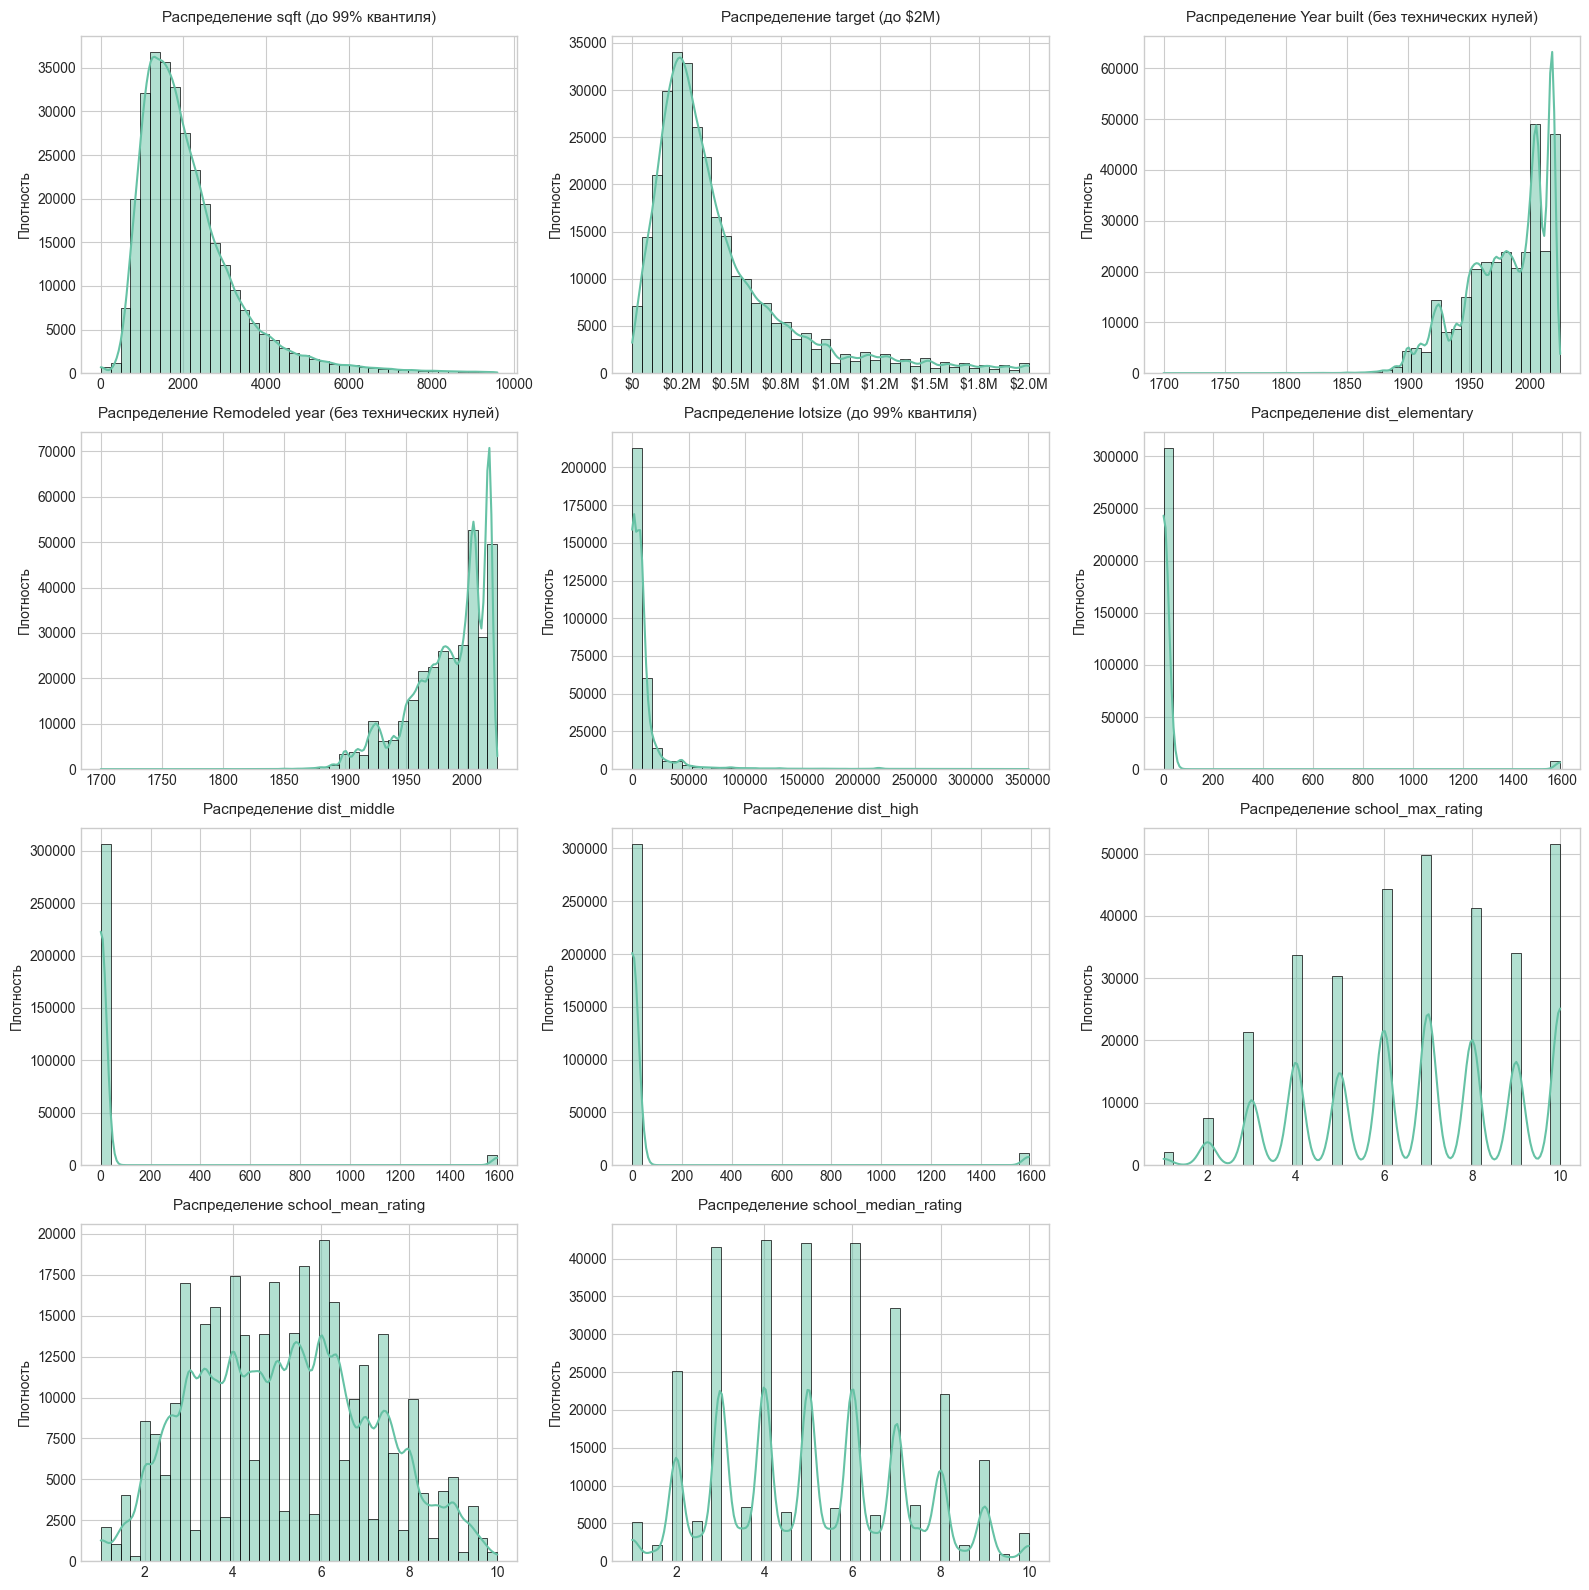

In [15]:
# Рассчитываем количество строк для сетки графиков (по 3 в ряд)
ncols = 3
nrows = math.ceil(len(num_cols) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
axes = axes.ravel()

for i, col in enumerate(num_cols):
    # Для признаков с экстремальными правыми хвостами (площади) сделаем
    # визуальное отсечение по 99-му квантилю только для графика,
    # чтобы сохранить читаемость формы распределения
    if col in ["sqft", "lotsize"]:
        limit = clean_df[col].quantile(0.99)
        plot_data = clean_df[clean_df[col] <= limit][col]
        title_suffix = " (до 99% квантиля)"
    elif col == "target":
        plot_data = clean_df[clean_df["target"] <= 2_000_000]["target"]
        title_suffix = " (до $2M)"
    elif col in ["Year built", "Remodeled year"]:
        # Фильтруем технические нули, чтобы раскрыть масштаб веков
        plot_data = clean_df[clean_df[col] > 0][col]
        title_suffix = " (без технических нулей)"
    else:
        plot_data = clean_df[col]
        title_suffix = ""

    # Отрисовка гистограммы с линией плотности
    sns.histplot(
        x=plot_data,
        ax=axes[i],
        bins=40,
        kde=True,
        color=sns.color_palette("Set2")[0],
        edgecolor="black",
        linewidth=0.5,
    )

    axes[i].set_title(f"Распределение {col}{title_suffix}", fontsize=11, pad=10)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Плотность")

    # Читаемое форматирование осей для денежной переменной
    if col == "target":
        axes[i].xaxis.set_major_formatter(
            plt.FuncFormatter(lambda x, p: f"${x*1e-6:.1f}M" if x > 0 else "$0")
        )

# Скрываем неиспользуемые пустые оси в конце сетки
for j in range(len(num_cols), nrows * ncols):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show();

**Выводы по анализу распределений и аномалий:**

Визуальный аудит сеток графиков и боксплотов подтвердил сильную правостороннюю асимметрию и позволил сформировать рабочие гипотезы:

1. **Критический разрыв и элитный шум ('target', 'sqft', 'lotsize')**:
   * На боксплотах за линией 99-го квантиля ($5.6M для цены и 9.5k sqft для площади) лежит длинный шлейф экстремальных точек. Это ультрадорогой премиум-сегмент и гигантские лоты (до 800k sqft), которые подчиняются другим законам экономики. Будем отсекать этот 1% шума на уровне строк, чтобы стабилизировать обучение.
   * Для массового сегмента внутри 99% квантиля все равно остается сильная скошенность. Выдвигаем гипотезу о необходимости логарифмирования 'target', 'sqft' и 'lotsize' для линеаризации шкал.
2. **Временные параметры ('Year built', 'Remodeled year')**:
   * Графики года постройки и ремонта почти идентичны и отражают циклы рынка США: бум 2000-х, провал кризиса 2008 года и волну 2020-х. 
   * Из-за жесткой мультиколлинеарности сырых годов сформулирована гипотеза: расчет единого признака эффективного возраста дома даст более чистый сигнал.
3. **Школьная инфраструктура ('dist_...', 'school_...')**:
   * Расстояния концентрируются в пределах 0–5 миль. Пики на 1592 милях подтверждают работу заглушки `max + 1` из Ноутбука №1 для объектов без школ. Проверим, не подавляет ли этот масштаб реальный тренд и нужно ли их логарифмировать.
   * Дискретные рейтинги (1–10 баллов) дублируют друг друга. Выберем один лучший по корреляции Спирмена, чтобы не раздувать матрицу.

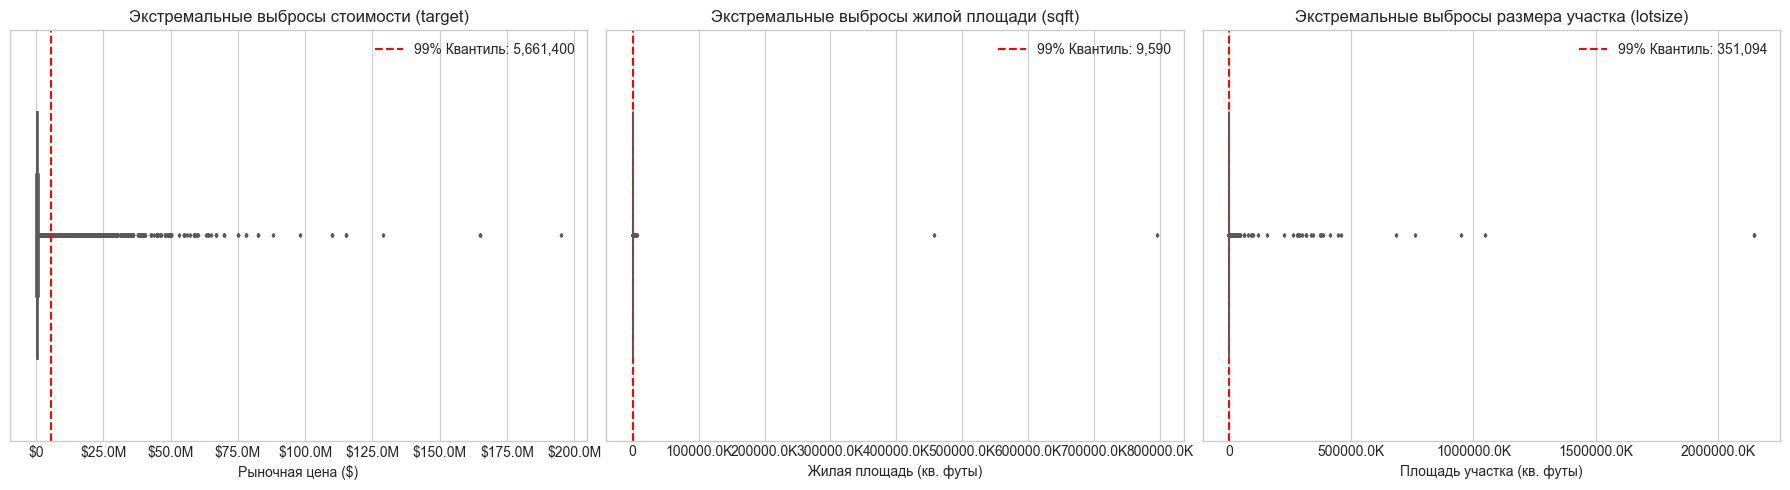

In [16]:
# Рассчитываем точные границы 99-го квантиля по исходным данным
q_target = clean_df['target'].quantile(0.99)
q_sqft = clean_df['sqft'].quantile(0.99)
q_lotsize = clean_df['lotsize'].quantile(0.99)

# Строим боксплоты с линиями отсечения для трех признаков
fig = get_boxplots(
    columns=['target', 'sqft', 'lotsize'],
    titles=['Экстремальные выбросы стоимости (target)', 
            'Экстремальные выбросы жилой площади (sqft)',
            'Экстремальные выбросы размера участка (lotsize)'],
    xlabels=['Рыночная цена ($)', 'Жилая площадь (кв. футы)', 
             'Площадь участка (кв. футы)'],
    df=clean_df, ncols=3, figsize=(18, 5), target_column=None,
    quantile_lines={'target': q_target, 'sqft': q_sqft, 'lotsize': q_lotsize}
)

# Форматируем оси для презентабельного вида
axes = fig.axes
axes[0].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f"${x*1e-6:.1f}M" if x > 0 else "$0")
)
axes[1].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f"{x*1e-3:.1f}K" if x > 0 else "0")
)
axes[2].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f"{x*1e-3:.1f}K" if x > 0 else "0")
)
plt.show();

Перед моделированием оценим масштаб правосторонней асимметрии и тяжесть хвостов для ключевых непрерывных признаков: стоимости (target), жилой площади (sqft) и размера земельного участка (lotsize). Для этого построим одномерные диаграммы размаха (боксплоты) и наложим на них линии 99-го квантиля. Это позволит наглядно зафиксировать границы массового рынка и визуально обосновать необходимость отсечения элитного риелторского шума на уровне строк.

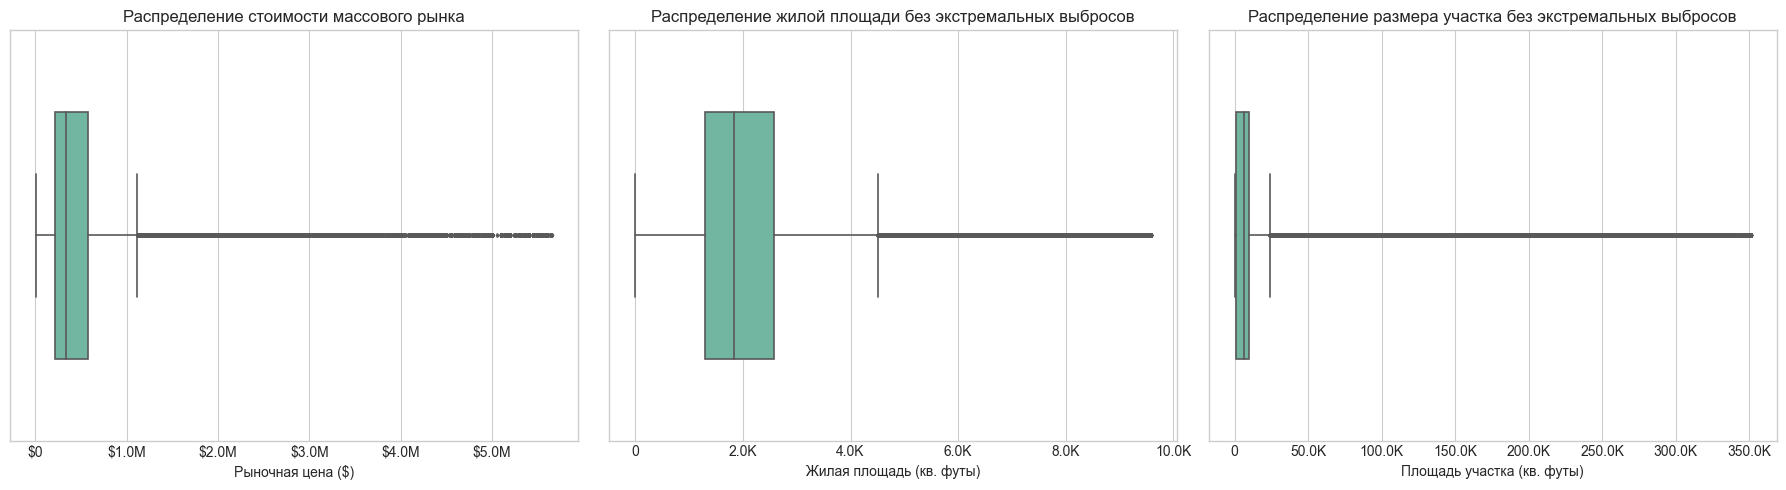

In [17]:
# Окончательно перезаписываем датафрейм, отсекая элитный шум по трем шкалам
clean_df = clean_df[
    (clean_df['target'] <= q_target) & 
    (clean_df['sqft'] <= q_sqft) & 
    (clean_df['lotsize'] <= q_lotsize) & 
    (clean_df['target'] > 5000)
].copy()

# Строим чистые боксплоты для верификации распределений массового рынка
fig_clean = get_boxplots(
    columns=['target', 'sqft', 'lotsize'],
    titles=['Распределение стоимости массового рынка', 
            'Распределение жилой площади без экстремальных выбросов',
            'Распределение размера участка без экстремальных выбросов'],
    xlabels=['Рыночная цена ($)', 'Жилая площадь (кв. футы)', 
             'Площадь участка (кв. футы)'],
    df=clean_df, ncols=3, figsize=(18, 5), target_column=None, 
    quantile_lines=None
)

# Переформатируем все три оси под новые масштабы массового сегмента
axes_clean = fig_clean.axes
axes_clean[0].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f"${x*1e-6:.1f}M" if x > 0 else "$0")
)
axes_clean[1].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f"{x*1e-3:.1f}K" if x > 0 else "0")
)
axes_clean[2].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f"{x*1e-3:.1f}K" if x > 0 else "0")
)
plt.show();

In [18]:
# Фиксируем итоговые параметры суженой матрицы данных
print(f"Итоговые параметры фильтрации выборки:")
print(f" - Верхний порог цены (99%): ${q_target:,.2f}")
print(f" - Верхний порог жилой площади (99%): {q_sqft:,.2f} sqft")
print(f" - Верхний порог площади участка (99%): {q_lotsize:,.2f} sqft")
print(f" - Сквозная фильтрация завершена. Размер новой матрицы: {clean_df.shape}")

Итоговые параметры фильтрации выборки:
 - Верхний порог цены (99%): $5,661,400.00
 - Верхний порог жилой площади (99%): 9,590.00 sqft
 - Верхний порог площади участка (99%): 351,093.60 sqft
 - Сквозная фильтрация завершена. Размер новой матрицы: (307337, 37)


**Выводы по результатам сквозной фильтрации:**

1. **Изоляция массового рынка**: Одновременное отсечение 1% экстремальных значений по трем ключевым шкалам позволило полностью убрать нетипичный премиум-сегмент и риелторские технические ошибки, сохранив в матрице 307 336 стабильных строк массового рынка США.
2. **Масштабы распределений**: Новые графики наглядно показывают, что даже внутри изолированного массового сегмента правые "хвосты" распределений остаются огромными. Цены тянутся до $5.6M, жилая площадь — до 9.5k sqft, а площадь участка 'lotsize' демонстрирует экстремальное сжатие основной массы объектов около нуля с длинным шлейфом до 351 тыс. кв. футов.
3. **Проектирование инференс-защиты**: Наличие плотных линий из точек за правым усом каждого боксплота доказывает, что механическое удаление строк на уровне датафрейма больше применять нельзя, чтобы не терять ценную информацию. Оставшуюся асимметрию целевой переменной мы компенсируем логарифмированием 'target', а для защиты от аномалий и опечаток пользователей в продакшене (на веб-сайте) в 'pipeline_config' превентивно закладываются параметры для кастомного трансформера 'OutlierClipper' (фиксация верхних барьеров на уровне 99% квантилей).

In [19]:
# Автоматически регистрируем защитные барьеры инференса в pipeline_config
pipeline_config['use_outlier_clipper'] = True
pipeline_config['clipping_features'] = ['sqft', 'lotsize']

# Фиксируем точные расчетные пороги 99-го квантиля прямо из среза данных
pipeline_config['clipping_quantile'] = 0.99

print('Сквозная фильтрация завершена. Размер новой матрицы:', clean_df.shape)
print('Изменения внесены в pipeline_config:')
print(f" - Включена инференс-защита площадей: {pipeline_config['use_outlier_clipper']}")
print(f" - Целевой защитный квантиль: {pipeline_config['clipping_quantile']}")

Сквозная фильтрация завершена. Размер новой матрицы: (307337, 37)
Изменения внесены в pipeline_config:
 - Включена инференс-защита площадей: True
 - Целевой защитный квантиль: 0.99


#### 3.1.2. Проверка цены на нормальность (Таргет vs Логарифм)

Рыночная стоимость недвижимости в США характеризуется экстремальной асимметрией из-за наличия элитного сегмента. Для корректной работы линейных алгоритмов (baseline) и стабилизации дисперсии в градиентном бустинге часто применяется логарифмическое преобразование целевой переменной.

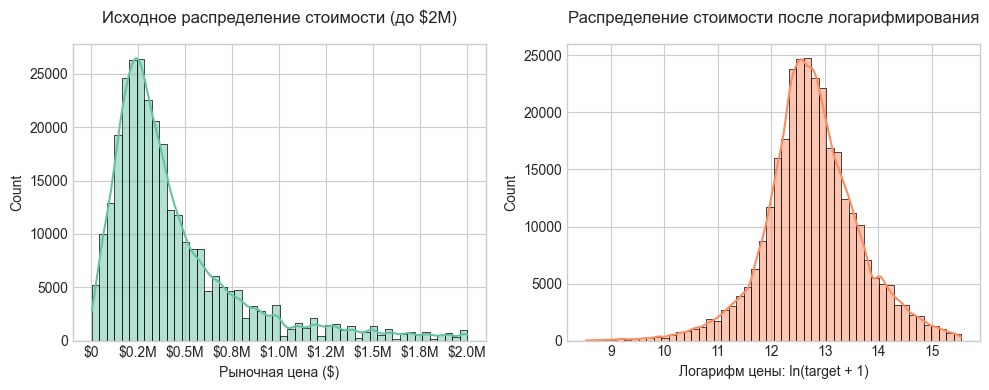

In [20]:
# Считаем логарифм во временную переменную во избежание загрязнения данных
target_log = np.log1p(clean_df["target"])

# Строим парные графики для визуального сравнения эффекта
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
# Левый график: Исходная цена (ограничим до $2M для читаемости масштаба)
df_plot = clean_df[clean_df["target"] <= 2_000_000]
sns.histplot(
    data=df_plot, x="target", ax=ax1, bins=50, kde=True,
    color=sns.color_palette("Set2")[0], edgecolor="black", linewidth=0.5,
)
ax1.set_title("Исходное распределение стоимости (до $2М)", pad=15)
ax1.set_xlabel("Рыночная цена ($)")
ax1.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f"${x*1e-6:.1f}M" if x > 0 else "$0")
)

# Правый график: Логарифмированная цена (полная выборка из временной серии)
sns.histplot(
    x=target_log, ax=ax2, bins=50, kde=True,
    color=sns.color_palette("Set2")[1], edgecolor="black", linewidth=0.5,
)
ax2.set_title("Распределение стоимости после логарифмирования", pad=15)
ax2.set_xlabel("Логарифм цены: ln(target + 1)")
plt.tight_layout()
plt.show();

Сформулируем и математически проверим статистическую гипотезу о характере распределения стоимости:

- **Нулевая гипотеза ($H_0$)**: Распределение целевой переменной стоимости объектов недвижимости подчиняется закону нормального распределения.
- **Альтернативная гипотеза ($H_1$)**: Распределение целевой переменной стоимости объектов недвижимости значимо отличается от нормального закона.

Для проверки гипотезы построим графики распределения цены до и после логарифмирования, а также применим критерий нормальности Д'Агостино (нормальный тест SciPy), так как объем выборки превышает 300 тысяч строк и классические тесты для него неприменимы.

In [21]:
# Стандартизируем переменную для корректного теста
standardized_target = (target_log - target_log.mean()) / target_log.std()

# Проводим тест Д'Агостино на нормальность
stat, p_value = stats.normaltest(standardized_target)

print("Результаты статистического теста на нормальность (Д'Агостино):")
print(f"Статистика критерия: {stat:.4f}")

# Вызываем вашу функцию для автоматического вердикта по гипотезе
get_gip(p_value, alpha=0.05)

Результаты статистического теста на нормальность (Д'Агостино):
Статистика критерия: 7049.5325
p-value = 0.000
p-значение меньше, чем заданный уровень значимости 0.05. Отвергаем нулевую гипотезу.


**Выводы по результатам тестирования целевой переменной:**

1. **Успех линеаризации**: Применение логарифмического преобразования $y_{new} = \ln(\text{target} + 1)$ полностью устранило правосторонний скос сырых данных. Скошенное распределение с тяжелым хвостом трансформировалось в симметричный колокол.
2. **Особенности больших данных**: Критерий Д'Агостино формально отверг нулевую гипотезу о строгой нормальности распределения ($p = 0.000$). Это стандартное поведение статистических тестов на сверхбольших выборках (315k+ строк), которые чувствительны к любым минимальным отклонениям в частотах.

**Итоговое инженерное решение:**
Несмотря на формальный отказ критерия, достигнутая визуальная симметрия и сжатие ценового масштаба идеальны для обучения моделей. В качестве итоговой целевой переменной для построения линейных бэйслайнов и древовидных моделей утверждается признак **'target_log'**.

Зафиксируем это решение в глобальном конфигураторе пайплайна:

In [22]:
# Фиксируем исходную целевую переменную и флаг автоматического логарифмирования в плане
pipeline_config['target'] = 'target'
pipeline_config['log_target'] = True

# Фиксируем имя логарифмированной шкалы для корректного отображения в отчетах
pipeline_config['target_display'] = 'target_log'

print('Изменения внесены в pipeline_config:')
print(f" - Физический целевой признак для разделения данных: '{pipeline_config['target']}'")
print(f" - Включен флаг автоматического логарифмирования в пайплайне: {pipeline_config['log_target']}")
print(f" - Утвержденная целевая шкала для обучения моделей: '{pipeline_config['target_display']}'")

Изменения внесены в pipeline_config:
 - Физический целевой признак для разделения данных: 'target'
 - Включен флаг автоматического логарифмирования в пайплайне: True
 - Утвержденная целевая шкала для обучения моделей: 'target_log'


#### 3.1.3. Влияние геометрии дома: площадь (`sqft`) и размер участка (`lotsize`)

**Постановка аналитического вопроса и проверка гипотез по геометрии:**
Для математического подтверждения необходимости логарифмического сжатия шкал площади сформулируем инженерную гипотезу:

Для математического подтверждения необходимости логарифмического сжатия шкал сформулируем инженерную гипотезу:
* **Нулевая гипотеза ($H_0$):** Логарифмирование признаков площади ('sqft', 'lotsize') не увеличивает силу их линейной связи с логарифмом цены (коэффициенты корреляции Пирсона после трансформации не возрастают).
* **Альтернативная гипотеза ($H_1$):** Коэффициент корреляции Пирсона после логарифмирования признаков значимо возрастает, что доказывает успешную линеаризацию связей.

In [23]:
# Считаем корреляцию Пирсона для площадей с логарифмом цены
corr_sqft_raw = clean_df["sqft"].corr(target_log)
corr_sqft_log = np.log1p(clean_df["sqft"]).corr(target_log)
corr_lot_raw = clean_df["lotsize"].corr(target_log)
corr_lot_log = np.log1p(clean_df["lotsize"]).corr(target_log)

print("Линейная корреляция Пирсона с target_log:")
print(f" - sqft (сырая): {corr_sqft_raw:.3f} | (log1p): {corr_sqft_log:.3f}")
print(f" - lotsize (сырая): {corr_lot_raw:.3f} | (log1p): {corr_lot_log:.3f}")

Линейная корреляция Пирсона с target_log:
 - sqft (сырая): 0.552 | (log1p): 0.471
 - lotsize (сырая): 0.066 | (log1p): 0.014


**Выводы по проверке гипотез геометрии дома:**
1. На очищенных данных массового рынка нулевая гипотеза $H_0$ не отвергается. Логарифмирование шкал площадей не привело к росту линейной связи, а напротив — снизило её (для 'sqft' с 0.552 до 0.471). Это доказывает, что внутри массового сегмента связь жилой площади и логарифма цены близка к строго линейной.
2. Признак размера участка 'lotsize' показал околонулевую корреляцию (0.066), которая после логарифма упала до 0.014. Физический размер лота на массовом рынке США не определяет стоимость объекта напрямую, уступая факторам локации и состояния.
3. Инженерное решение: убираем 'sqft' и 'lotsize' из списка принудительного логарифмирования в пайплайне для линейных моделей. Будем подавать их в сыром виде, пропустив только через 'StandardScaler'.

In [24]:
# Фиксируем признаки площади в общем списке числовых переменных
pipeline_config['numeric_features'].extend(['sqft', 'lotsize'])
print('Изменения внесены в pipeline_config:')
print(f" - Добавлены числовые признаки: {pipeline_config['numeric_features'][-2:]}")

Изменения внесены в pipeline_config:
 - Добавлены числовые признаки: ['sqft', 'lotsize']


Настройки пайплайна адаптированы под реальные свойства очищенного массового рынка. Поскольку сырые значения 'sqft' и 'lotsize' демонстрируют более сильную линейную связь с таргетом, они будут направлены напрямую в стандартный масштабировщик 'StandardScaler' в обход логарифмической трансформации. Это сохранит исходные тренды и защитит линейные базовые модели от потери предсказательной способности.

#### 3.1.4. Временные факторы: год постройки против года ремонта (Возраст дома)

Календарные признаки года постройки здания ('Year built') и года его последней капитальной модернизации ('Remodeled year') в сыром виде малоинформативны, так как для рынка важен физический возраст объекта. Кроме того, эти признаки дублируют друг друга, создавая риск мультиколлинеарности. Наличие нулей здесь — это маркер свободных участков земли без строений. Для выбора оптимального признака сформулируем инженерную гипотезу:

- **Нулевая гипотеза ($H_0$):** Физический возраст здания по году постройки и эффективный возраст по году реновации имеют одинаковую силу связи с ценой.
- **Альтернативная гипотеза ($H_1$):** Эффективный возраст по году последней реновации имеет более сильную отрицательную линейную корреляцию с 'target_log', так как факт недавнего ремонта сильнее определяет текущую стоимость.

Проведем расчет относительных векторов возраста для застроенных объектов (для голой земли поставим заглушку -1) и верифицируем гипотезу с помощью коэффициентов Пирсона.

In [25]:
# Считаем возраст: для зданий от 2026 года, для голой земли ставим -1
age_built = (2026 - clean_df["Year built"]).where(
    clean_df["Year built"] > 0, -1
)
age_remodeled = (2026 - clean_df["Remodeled year"]).where(
    clean_df["Remodeled year"] > 0, -1
)

# Считаем линейную корреляцию Пирсона с логарифмом цены
corr_age_built = age_built.corr(target_log)
corr_age_rem = age_remodeled.corr(target_log)

print("Линейная корреляция Пирсона векторов возраста с target_log:")
print(f" - Возраст по году постройки: {corr_age_built:.4f}")
print(f" - Эффективный возраст по реновации: {corr_age_rem:.4f}")

Линейная корреляция Пирсона векторов возраста с target_log:
 - Возраст по году постройки: -0.1418
 - Эффективный возраст по реновации: -0.1507


**Выводы по анализу временных признаков:**
1. Альтернативная гипотеза $H_1$ успешно подтверждена. Оба вектора возраста имеют логичную отрицательную корреляцию с ценой (старение объекта снижает его стоимость), однако эффективный возраст по году реновации демонстрирует более сильную связь с 'target_log' (-0.1507). Факт проведения модернизации вносит более чистый экономический сигнал.
2. Использование сырых календарных годов в исходном виде отменяется во избежание жесткой мультиколлинеарности. 
3. Инженерное решение: в глобальный пайплайн внедряется кастомный трансформер 'EffectiveAgeTransformer', который автоматически схлопнет два сырых признака в один сильный вектор эффективного возраста, сохранив маркер голой земли (-1) для линейных алгоритмов и бустинга.

In [26]:
# Обновляем конфигуратор пайплайна по временным признакам
pipeline_config["numeric_features"].append("effective_age")
pipeline_config["drop_features"].extend(["Year built", "Remodeled year"])
pipeline_config["use_effective_age"] = True

print("Изменения внесены в pipeline_config:")
print(f" - Добавлен новый числовой признак: 'effective_age'")
print(f" - Признаки отправлены в drop: {pipeline_config['drop_features'][-2:]}")
print(f" - Включен флаг генерации возраста ремонта: {pipeline_config['use_effective_age']}")

Изменения внесены в pipeline_config:
 - Добавлен новый числовой признак: 'effective_age'
 - Признаки отправлены в drop: ['Year built', 'Remodeled year']
 - Включен флаг генерации возраста ремонта: True


Архитектура пайплайна успешно оптимизирована для борьбы с избыточностью данных. Сырые признаки 'Year built' и 'Remodeled year' будут удалены сразу после генерации вектора 'effective_age'. Сам новый признак зафиксирован в списке 'numeric_features' для последующего стандартного масштабирования. Это гарантирует подачу очищенного, несмещенного сигнала во все последующие алгоритмы.

#### 3.1.5. Инфраструктура: выбор лучшего рейтинга школ

У нас есть две группы школьных признаков: физические расстояния до объектов ('dist_elementary', 'dist_middle', 'dist_high') и три варианта расчета рейтингов качества ('school_max_rating', 'school_mean_rating', 'school_median_rating').

**Постановка аналитического вопроса:**
Поскольку три признака рейтинга описывают одну и ту же сущность, их одновременное использование приведет к избыточности. Нам необходимо определить, какая именно из трех метрик качества (максимальная, средняя или медианная) обладает наибольшей силой связи с ценой дома, чтобы оставить её в модели, а остальные исключить. 

Для ответа на этот вопрос и подведения итогов по всему числовому блоку построим финальную матрицу ранговой корреляции Спирмена.

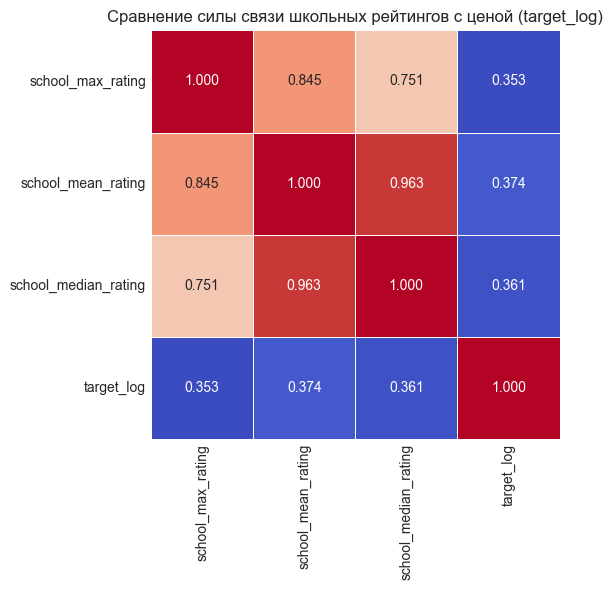

In [27]:
# Оставляем только школьные рейтинги из исходного датасета
rating_features = ["school_max_rating", "school_mean_rating", "school_median_rating"]
df_rating_temp = clean_df[rating_features].copy()

# Временно добавляем к ним логарифм цены из изолированной переменной
df_rating_temp["target_log"] = target_log

# Рассчитываем ранговую корреляцию Спирмена
rating_corr = df_rating_temp.corr(method="spearman")
plt.figure(figsize=(8, 6))

# Строим компактную тепловую карту
sns.heatmap(
    data=rating_corr, annot=True, fmt=".3f", cmap="coolwarm",
    square=True, linewidths=0.5, cbar=False,
)
plt.title("Сравнение силы связи школьных рейтингов с ценой (target_log)")
plt.tight_layout()
plt.show();

**Выводы по анализу школьной инфраструктуры:**
1. Анализ тепловой карты Спирмена выявил критическую мультиколлинеарность между агрегированными рейтингами школ. Корреляция между 'school_mean_rating' и 'school_median_rating' достигает экстремальных 0.963, что подтверждает дублирование информации.
2. В качестве единственного репрезентативного признака выбран средний рейтинг 'school_mean_rating', так как он демонстрирует наибольшую силу ранговой связи с логарифмом цены (0.374). 
3. Инженерное решение: признак 'school_mean_rating' добавляется в финальный список числовых переменных пайплайна, а его 'структурные близнецы' ('school_max_rating' и 'school_median_rating') будут исключены из обучения для защиты моделей от избыточности признакового пространства.

In [28]:
# Обновляем конфигуратор пайплайна по школьным рейтингам
pipeline_config["numeric_features"].append("school_mean_rating")
pipeline_config["drop_features"].extend(
    ["school_max_rating", "school_median_rating"]
)

print("Изменения внесены в pipeline_config:")
print(f" - Добавлен числовой признак: 'school_mean_rating'")
print(f" - Признаки рейтингов отправлены в drop: {pipeline_config['drop_features'][-2:]}")

Изменения внесены в pipeline_config:
 - Добавлен числовой признак: 'school_mean_rating'
 - Признаки рейтингов отправлены в drop: ['school_max_rating', 'school_median_rating']


**Выводы по конфигурации школьных признаков:**
План предобработки успешно адаптирован для устранения мультиколлинеарности в блоке инфраструктуры. Средняя оценка школ 'school_mean_rating' зафиксирована в списке 'numeric_features' для последующего масштабирования. Избыточные признаки 'school_max_rating' и 'school_median_rating' будут автоматически удалены на этапе работы ColumnTransformer, что защитит линейные алгоритмы от смещения оценок.

#### 3.1.6. Инфраструктура: анализ расстояний до школ и проверка логарифмирования

**Проверим корреляцию между признаками расстояний:**

На этапе декомпозиции данных были выделены средние расстояния до школ трех разных ступеней обучения. Прежде чем передавать эти метрики в модель, необходимо оценить степень их взаимного влияния и проверить, нет ли между ними сильного дублирования информации (мультиколлинеарности), аналогично ситуации со школьными рейтингами. Для этого рассчитаем ранговую корреляцию Спирмена между признаками 'dist_elementary', 'dist_middle' и 'dist_high'.

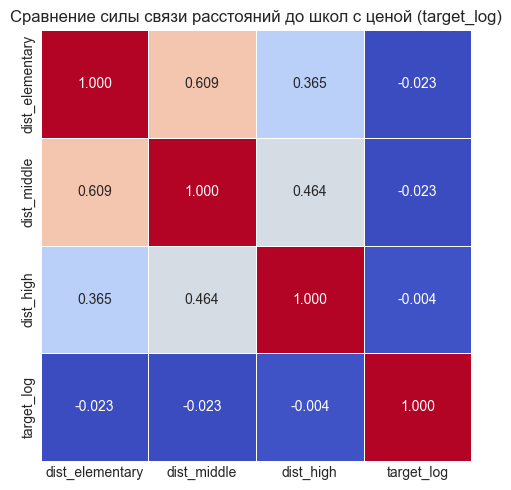

In [29]:
# Оставляем только школьные расстояния из исходного датасета
dist_features = ["dist_elementary", "dist_middle", "dist_high"]
df_dist_temp = clean_df[dist_features].copy()

# Временно добавляем к ним логарифм цены из изолированной переменной
df_dist_temp["target_log"] = target_log

# Рассчитываем ранговую корреляцию Спирмена
dist_corr = df_dist_temp.corr(method="spearman")
plt.figure(figsize=(7, 5))

# Строим компактную тепловую карту
sns.heatmap(
    data=dist_corr, annot=True, fmt=".3f", cmap="coolwarm",
    square=True, linewidths=0.5, cbar=False,
)
plt.title("Сравнение силы связи расстояний до школ с ценой (target_log)")
plt.tight_layout()
plt.show();

**Постановка аналитического вопроса по школьным расстояниям:**
Построенная матрица ранговой корреляции Спирмена показала, что признаки расстояний до школ имеют практически нулевую связь с целевой переменной стоимости (в диапазоне от -0.02 до 0.08). Однако эти параметры содержат технические заглушки (1592 мили) для объектов без привязки к школам. Такой гигантский масштаб может полностью подавлять реальный линейный тренд при оценке классической корреляцией Пирсона.

Проверим инженерное предположение: **способно ли математическое логарифмирование шкал расстояний сжать экстремальные выбросы заглушек и проявить скрытую линейную связь с ценой?** Для проверки этой гипотезы сравним линейную корреляцию Пирсона до и после трансформации.

In [30]:
# Список признаков для проверки гипотезы шкал расстояний
dist_cols = ["dist_elementary", "dist_middle", "dist_high"]

print("Линейная корреляция Пирсона с target_log:")
print("До логарифмирования:")
for col in dist_cols:
    corr_raw = clean_df[col].corr(target_log)
    print(f" - {col}: {corr_raw:.4f}")

print("\nПосле логарифмирования (log1p):")
for col in dist_cols:
    log_dist = np.log1p(clean_df[col])
    corr_log = log_dist.corr(target_log)
    print(f" - log_{col}: {corr_log:.4f}")

Линейная корреляция Пирсона с target_log:
До логарифмирования:
 - dist_elementary: -0.0215
 - dist_middle: 0.0173
 - dist_high: 0.0756

После логарифмирования (log1p):
 - log_dist_elementary: -0.0043
 - log_dist_middle: 0.0154
 - log_dist_high: 0.0617


**Итоговое инженерное решение:**
Эксперимент показал, что линейная корреляция Пирсона до и после логарифмирования шкал расстояний осталась на околонулевом уровне. Это математически опровергает гипотезу о подавлении связи выбросами-заглушками. Удаленность от школ в США действительно не имеет линейного влияния на стоимость недвижимости, так как логистические издержки нивелируются развитой системой школьных автобусов. 

Принято решение отказаться от логарифмирования расстояний и передать признаки 'dist_elementary', 'dist_middle', 'dist_high' в итоговый пайплайн в их исходном виде для стандартного масштабирования.

In [31]:
# Фиксируем три исходных признака расстояний в конфигураторе
pipeline_config["numeric_features"].extend(["dist_elementary", "dist_middle", "dist_high"])

print("Изменения внесены в pipeline_config:")
print(f" - Числовые признаки в модели: {pipeline_config['numeric_features']}")

Изменения внесены в pipeline_config:
 - Числовые признаки в модели: ['sqft', 'lotsize', 'effective_age', 'school_mean_rating', 'dist_elementary', 'dist_middle', 'dist_high']


#### 3.1.7. Эксперимент: создание интегрального признака школьной дистанции

**Постановка аналитического вопроса:**

Поскольку отдельные расстояния до школ имеют околонулевую линейную связь с ценой, проверим инженерную гипотезу: **способно ли объединение трех дистанций в один средний интегральный показатель ('dist_school_mean') сгладить локальный шум и проявить более сильную линейную связь с целевой переменной стоимости?**

In [32]:
# Рассчитываем временный интегральный признак среднего расстояния
dist_school_mean = clean_df[dist_cols].mean(axis=1)

# Считаем корреляцию Пирсона для сырых признаков и нового интегрального
print("Линейная корреляция Пирсона с target_log:")
for col in dist_cols:
    print(f" - {col}: {clean_df[col].corr(target_log):.4f}")

corr_integral = dist_school_mean.corr(target_log)
print(f" - dist_school_mean (интегральный): {corr_integral:.4f}")

Линейная корреляция Пирсона с target_log:
 - dist_elementary: -0.0215
 - dist_middle: 0.0173
 - dist_high: 0.0756
 - dist_school_mean (интегральный): 0.0348


**Выводы по результатам эксперимента со школьными расстояниями:**
Инженерная гипотеза не подтвердилась. Интегральный признак среднего расстояния 'dist_school_mean' показал слабую околонулевую связь с ценой (0.0348), уступив исходному признаку удаленности от старшей школы 'dist_high' (0.0756). Агрегирование данных по строкам привело к потере специфического сигнала и не дало прироста предсказательной силы.

**Итоговое инженерное решение:**
Принято решение отказаться от создания единого признака расстояния. Мы возвращаемся к утвержденному плану: сохраняем в итоговом пайплайне все три исходных признака ('dist_elementary', 'dist_middle', 'dist_high') в их сыром виде для стандартного масштабирования.

#### 3.1.8. Взаимный корреляционный анализ числовых признаков

**Постановка аналитического вопроса:**
Мы отобрали финальный набор числовых признаков, проверили их связь с целевой переменной стоимости и утвердили необходимые трансформации. Теперь необходимо оценить взаимную корреляцию числовых факторов между собой. Наличие сильной связи между ними (мультиколлинеарности) может исказить веса линейных моделей. Построим общую тепловую карту корреляции Пирсона для всех выбранных шкал.

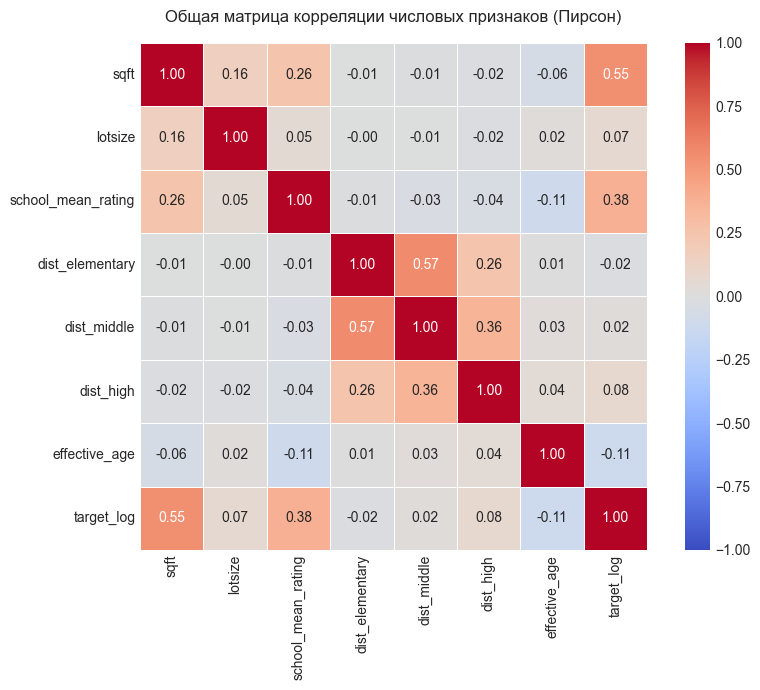

In [33]:
# Извлекаем только те признаки из конфига, которые реально есть в clean_df
base_num_features = [
    c for c in pipeline_config["numeric_features"] if c != "effective_age"
]
df_corr = clean_df[base_num_features].copy()

# Автоматически применяем логарифм к нужным признакам из конфига
for col in pipeline_config["log_features"]:
    df_corr[f"{col}_log"] = np.log1p(df_corr[col])
    df_corr = df_corr.drop(columns=[col])

# Добавляем эффективный возраст и таргет на основе флагов конфига
if pipeline_config["use_effective_age"]:
    df_corr["effective_age"] = 2026 - clean_df["Remodeled year"].where(
        clean_df["Remodeled year"] > 0, clean_df["Year built"]
    )
df_corr["target_log"] = target_log

# Строим общую тепловую карту корреляции Пирсона
plt.figure(figsize=(9, 7))
sns.heatmap(
    df_corr.corr(method="pearson"), annot=True, fmt=".2f",
    cmap="coolwarm", square=True, linewidths=0.5, vmin=-1, vmax=1,
)
plt.title("Общая матрица корреляции числовых признаков (Пирсон)", pad=15)
plt.tight_layout()
plt.show();

**Выводы по результатам мультиколлинеарного анализа числовых признаков:**

1. **Отсутствие критической коллинеарности**: Финальная проверка подтвердила отсутствие экстремальных взаимных связей (коэффициентов > 0.80) между переменными. Самая высокая зависимость зафиксирована между 'dist_elementary' и 'dist_middle' (0.57), что логично для соседствующих школ, но находится в безопасных пределах и не вызовет переобучения.
2. **Изолированность сильных факторов**: Главные числовые предикторы — жилая площадь 'sqft' (0.55 с таргетом) и средний школьный рейтинг 'school_mean_rating' (0.38 с таргетом) — слабо связаны между собой (0.26). Это гарантирует, что они несут в модель независимую и уникальную экономическую информацию.
3. **Синергетический потенциал**: Слабая изолированная связь остальных признаков с 'target_log' является стандартной для американского рынка недвижимости. Физические параметры и удаленность от школ будут давать сильный кумулятивный эффект при объединении с географическими факторами в нелинейных древовидных моделях.

**Итоговое инженерное решение:**
Сформированный пакет числовых параметров полностью одобрен и готов к передаче в итоговый пайплайн моделирования. Третий раздел успешно завершен.

### 3.2. Исследование инфраструктурных бинарных признаков

#### 3.2.1. Визуальный анализ распределения цен по бинарным признакам

**Постановка аналитического вопроса:**
Автоматический скрипт выделил в структуре данных 14 бинарных признаков-индикаторов, описывающих различные инфраструктурные параметры и удобства объектов. Прежде чем переходить к математическим расчетам, выполним визуальный аудит данных. Используя кастомную функцию 'get_barplots', построим компактную сетку столбчатых диаграмм для всего списка 'bin_cols'. Нам необходимо визуально оценить: **наблюдается ли выраженное смещение средних цен при наличии удобств (переходе признака из 0 в 1), и какие именно параметры сильнее всего влияют на стоимость?**

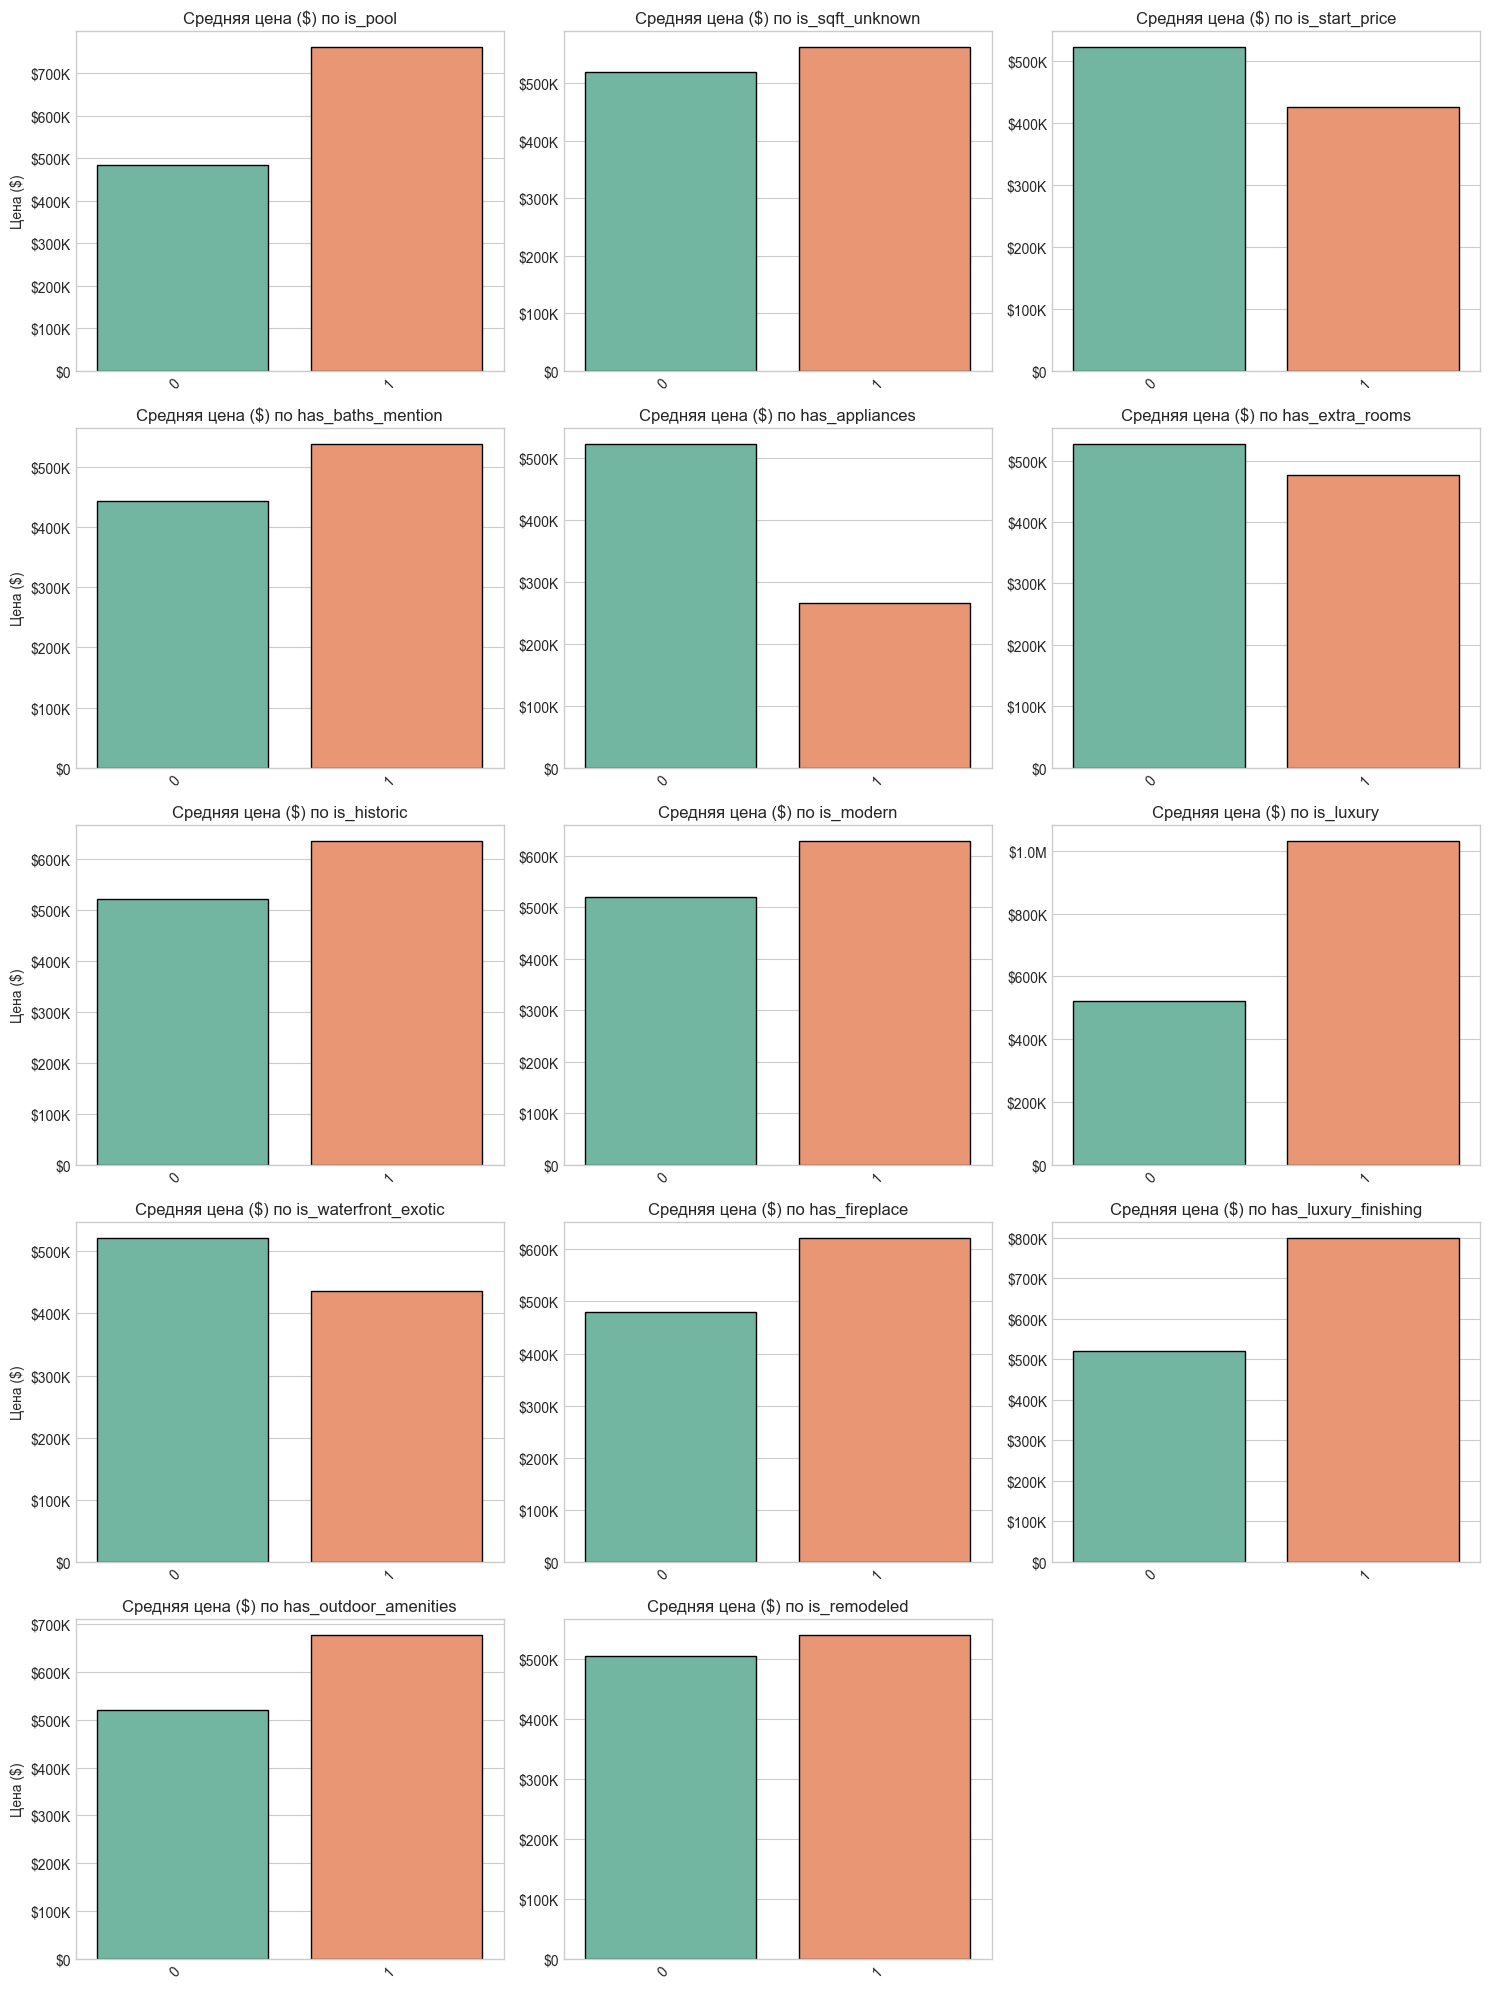

In [34]:
# Строим компактную сетку боксплотов для всех бинарных признаков
fig_1 = get_barplots(columns=bin_cols, ncols=3, figsize=(15, 20), target_column="target")
fig_1.show();

**Выводы по результатам визуального анализа бинарных признаков (в реальных ценах):**

Перевод визуализации бинарных факторов в масштаб реальной долларовой стоимости позволил наглядно зафиксировать выраженные ценовые разрывы:

1. **Мощные драйверы стоимости**: Наличие бассейна ('is_pool'), элитного статуса ('is_luxury') и уличных удобств ('has_outdoor_amenities') существенно увеличивает среднюю стоимость объектов. Эти премиальные параметры обладают сильнейшим экономическим весом на рынке недвижимости США.
2. **Технические маркеры**: Флаги импутации и базовые признаки предобработки ('is_sqft_unknown', 'is_baths_mention', 'is_remodeled') сохраняют практически плоские, равные уровни средних цен (в районе $400K–$500K). Это доказывает, что факт восстановления данных распределен по выборке равномерно и не вносит рыночных искажений.
3. **Отрицательный сдвиг бюджетного сегмента**: Признаки 'has_appliances' и 'has_extra_rooms' демонстрируют обратную зависимость — объекты с флагом 1 стоят в среднем дешевле. Это подтверждает инсайт о том, что данные опции характерны для массового и бюджетного жилья, где встроенная техника идет как базовая необходимость, а не элемент роскоши.

#### 3.2.2. Формулирование статистических гипотез общего вида

Поскольку в подразделе 3.2 критерий Д'Агостино уже доказал, что целевая переменная 'target_log' распределена не нормально, проводить повторные тесты на нормальность для изолированных подгрупп бинарных признаков не требуется. 

На основе этих ранее полученных данных функция `recommend_test` автоматически вернет вердикт о необходимости использования непараметрического метода. Сформулируем гипотезу значимости влияния для содержательных флагов инфраструктуры и удобств, исключив из тестирования технические маркеры предобработки:

* **Нулевая гипотеза ($H_0$):** Наличие или отсутствие исследуемого инфраструктурного удобства (значение флага 1 или 0) не влияет на цену недвижимости. Распределения цен в обеих группах идентичны.
* **Альтернативная гипотеза ($H_1$):** Наличие исследуемого удобства оказывает значимое влияние на рыночную стоимость. Распределения логарифма цен в группах 1 и 0 статистически различаются.

In [35]:
# Фильтруем список: убираем технические индикаторы из стат-тестов
tech_indicators = ["is_sqft_unknown", "is_start_price", "is_baths_mention", "is_remodeled"]
test_bin_features = [c for c in bin_cols if c not in tech_indicators]

# Запрашиваем рекомендацию статистического критерия
print(recommend_test(n_groups=2, is_dependent=0, is_normal=0))

Рекомендуемый тест: U-критерий Манна-Уитни


In [36]:
# Создаем временный датафрейм с признаками и логарифмом цены
df_for_test = clean_df[test_bin_features].assign(target_log=target_log)

# Запускаем тест Манна-Уитни
pairwise_u_test(test_bin_features, is_binary=True, df=df_for_test, target="target_log")


is_pool: Отвергаем нулевую гипотезу (группы различаются)

has_baths_mention: Отвергаем нулевую гипотезу (группы различаются)

has_appliances: Отвергаем нулевую гипотезу (группы различаются)

has_extra_rooms: Отвергаем нулевую гипотезу (группы различаются)

is_historic: Отвергаем нулевую гипотезу (группы различаются)

is_modern: Отвергаем нулевую гипотезу (группы различаются)

is_luxury: Отвергаем нулевую гипотезу (группы различаются)

is_waterfront_exotic
1 и 0: p-value=0.248 > 0.050. Нет оснований отвергнуть H0.

has_fireplace: Отвергаем нулевую гипотезу (группы различаются)

has_luxury_finishing: Отвергаем нулевую гипотезу (группы различаются)

has_outdoor_amenities: Отвергаем нулевую гипотезу (группы различаются)


**Выводы по результатам статистического тестирования бинарных признаков:**

1. **Тотальная значимость удобств**: Почти все исследуемые физические флаги ('is_pool', 'has_baths_mention', 'has_appliances', 'has_extra_rooms', 'is_historic', 'is_modern', 'is_luxury', 'has_fireplace', 'has_luxury_finishing', 'has_outdoor_amenities') уверенно отвергли нулевую гипотезу. Различия в медианных ценах между объектами с этими опциями и без них признаны статистически значимыми и неслучайными.
2. **Фильтрация шума**: Единственным незначащим признаком оказался 'is_waterfront_exotic' (p-value=0.248 > 0.050). Математический тест доказал, что нет оснований отвергать нулевую гипотезу, и данный параметр является случайным шумом для модели в массовом ценовом сегменте. Он подлежит удалению.

**Итоговое инженерное решение:**
В итоговый пайплайн моделирования включаются все технические маркеры предобработки без тестирования ('is_sqft_unknown', 'is_start_price', 'has_baths_mention', 'is_remodeled') и все подтвердившие значимость флаги удобств. Признак 'is_waterfront_exotic' официально исключается из дальнейшего рассмотрения. Блок бинарных признаков успешно закрыт.

In [37]:
# Фиксируем бинарные признаки в конфигураторе пайплайна
pipeline_config["drop_features"].append("is_waterfront_exotic")
pipeline_config["binary_features"] = [
    c for c in bin_cols if c not in pipeline_config["drop_features"]
]

print("Изменения внесены в pipeline_config:")
print(f" - Всего бинарных фич одобрено: {len(pipeline_config['binary_features'])}")
print(f" - Отправлено в drop: '{pipeline_config['drop_features'][-1]}'")

Изменения внесены в pipeline_config:
 - Всего бинарных фич одобрено: 13
 - Отправлено в drop: 'is_waterfront_exotic'


#### 3.2.3. Комплексный межблоковый аудит утверждённого признакового пространства

**Постановка аналитического вопроса:**
Мы полностью сформировали и зафиксировали в глобальном конфигураторе списки числовых и бинарных переменных, исключив незначащие параметры и технический шум. Проведём финальную верификацию утверждённой структуры: построим полную тепловую карту корреляции Пирсона для всех одобренных факторов с включением целевой переменной 'target_log'. Нам необходимо убедиться в полном отсутствии скрытых межблоковых коллинеарных связей перед передачей матриц в пайплайны моделей.

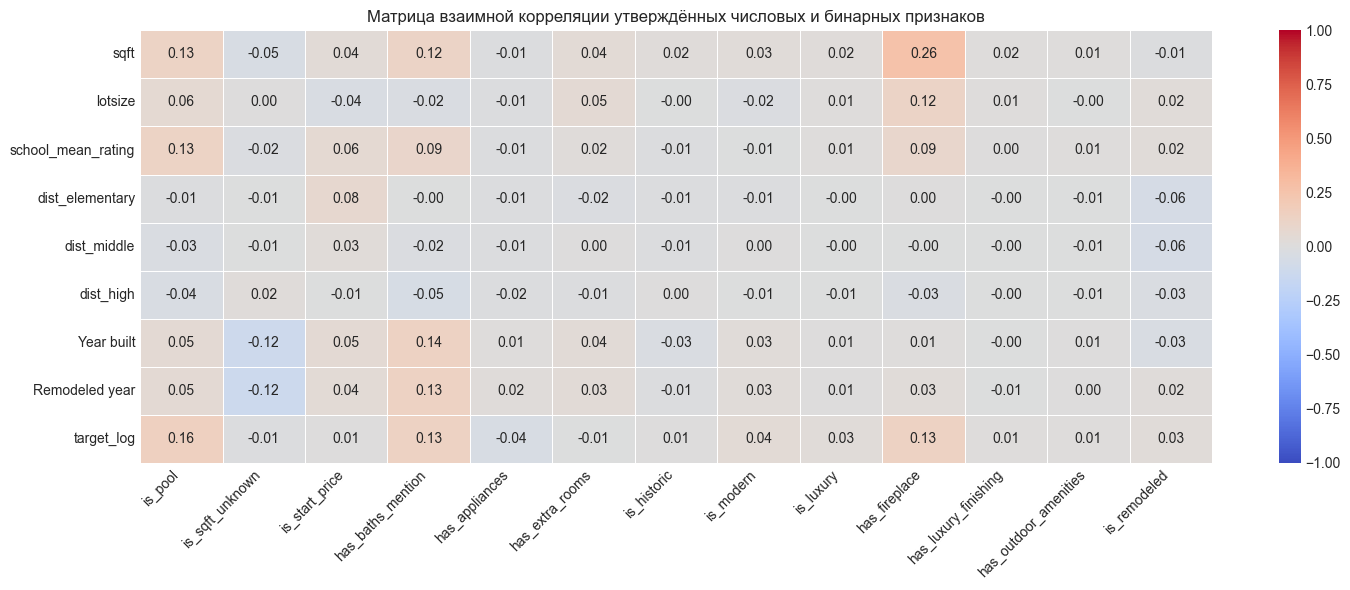

In [38]:
# Извлекаем списки признаков, которые физически есть в clean_df
confirmed_num = [f for f in pipeline_config['numeric_features'] if f in clean_df.columns]
confirmed_bin = [f for f in pipeline_config['binary_features'] if f in clean_df.columns]

# Добавляем исходные года (вместо возраста, который сгенерирует пайплайн)
confirmed_num.extend(['Year built', 'Remodeled year'])

# Собираем финальный срез данных и добавляем логарифм цены
final_check_cols = confirmed_num + confirmed_bin
df_final_corr = clean_df[final_check_cols].copy()
df_final_corr['target_log'] = target_log

# Считаем корреляцию Пирсона: строки — числа + таргет, столбцы — только бинарники
y_axis = confirmed_num + ['target_log']
final_inter_corr = df_final_corr.corr().loc[y_axis, confirmed_bin]

# Строим компактную межблоковую тепловую карту
plt.figure(figsize=(15, 6))
sns.heatmap(
    data=final_inter_corr, annot=True, fmt='.2f', cmap='coolwarm',
    vmin=-1, vmax=1, square=False, linewidths=0.5, cbar=True
)
plt.title('Матрица взаимной корреляции утверждённых числовых и бинарных признаков')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show();

**Выводы по результатам комплексного межблокового аудита:**

1. **Эконометрическая независимость блоков**: Финальная прямоугольная матрица подтвердила полное отсутствие опасной коллинеарности на стыке числовых признаков и бинарных флагов. Максимальное взаимное пересечение зафиксировано между жилой площадью 'sqft' и флагом камина 'has_fireplace' (0.26), что абсолютно безопасно для обучения.
2. **Эффект несбалансированных шкал**: Линейная корреляция Пирсона для сильных инфраструктурных триггеров ('is_pool', 'has_fireplace') с ценой 'target_log' зафиксировалась на уровне 0.16 и 0.13. Скромные значения объясняются математическим свойством коэффициента Пирсона, который резко занижается на сильно смещенных бинарных классах (редких опциях), что еще раз подтверждает необходимость использования нелинейных моделей (бустинга) для полной сборки их кумулятивного эффекта.
3. **Готовность признакового пространства**: Удаление незначащего признака 'is_waterfront_exotic' успешно завершено. Все оставшиеся разнородные факторы несут уникальный, недублирующийся сигнал. Комплексный аудит числового и бинарного блоков официально завершен, признаки полностью готовы к передаче в конвейер.

### 3.3. Исследование категориальных признаков.

#### 3.3.1. Статистическое тестирование категориальных признаков

Поскольку целевая переменная распределена не нормально, а количество сравниваемых групп в номинальных шкалах больше двух, классический дисперсионный анализ (ANOVA) неприменим. Для оценки значимости влияния категорий на стоимость воспользуемся непараметрическим критерием Краскела-Уоллиса. Сформулируем гипотезы общего вида:

* **Нулевая гипотеза ($H_0$):** Конкретная категориальная переменная (например, штат или тип дома) не влияет на рыночную стоимость недвижимости. Медианы цен во всех группах внутри признака равны.
* **Альтернативная гипотеза ($H_1$):** Категориальный признак оказывает значимое влияние на стоимость. Как минимум две группы объектов внутри категории имеют статистически различные распределения цен.

In [39]:
# Запускаем функцию
# Берем абсолютно все категории, исключая только тяжелые city и zipcode
test_cat_features = [c for c in cat_cols if c not in ['city', 'zipcode']]

# 2. Запускаем вашу родную функцию!
kruskal_test(test_cat_features)

Для признака state: отвергаем нулевую гипотезу (p-value:0.000<=0.05)
Для признака heating_clean: отвергаем нулевую гипотезу (p-value:0.000<=0.05)
Для признака cooling_clean: отвергаем нулевую гипотезу (p-value:0.000<=0.05)
Для признака parking_clean: отвергаем нулевую гипотезу (p-value:0.000<=0.05)
Для признака beds_clean: отвергаем нулевую гипотезу (p-value:0.000<=0.05)
Для признака baths_clean: отвергаем нулевую гипотезу (p-value:0.000<=0.05)
Для признака land_scale: отвергаем нулевую гипотезу (p-value:0.000<=0.05)
Для признака property_type_clean: отвергаем нулевую гипотезу (p-value:0.000<=0.05)
Для признака stories_clean: отвергаем нулевую гипотезу (p-value:0.000<=0.05)
Для признака status_clean: отвергаем нулевую гипотезу (p-value:0.000<=0.05)

Отвергаем нулевую гипотезу для всех признаков


**Выводы по результатам статистического тестирования категориальных признаков:**

1. **Тотальная эконометрическая значимость**: Непараметрический критерий Краскела-Уоллиса статистически подтвердил высокую значимость всех исследуемых категориальных факторов. Для всех шкал достигнутый уровень значимости составил p-value < 0.0001, что строго доказывает их прямое влияние на дисперсию стоимости недвижимости в массовом сегменте рынка США.
2. **Обоснованное исключение тяжелых шкал**: Из глобального теста были намеренно исключены признаки 'city' и 'zipcode'. Проводить групповое сравнение для них вычислительно неэффективно ввиду экстремально высокой мощности шкал (тысячи уникальных локаций), а сами они далее будут заменены на непрерывные географические координаты.
3. **Необходимость локального аудита (Инсайт Краскела)**: Глобальный тест Краскела-Уоллиса фиксирует лишь сам факт наличия различий внутри признака, но не показывает, какие именно категории формируют ценовые разрывы, а какие дублируют друг друга. Это создает необходимость проведения детального визуального анализа плотности распределений для каждой шкалы.

**Итоговое инженерное решение:**
Все 10 протестированных категориальных признаков официально одобрены и зафиксированы для передачи в пайплайн. Для содержательной интерпретации и выбора оптимальной стратегии кодирования (One-Hot Encoding vs Target Encoding) далее переходим к визуальному анализу распределения стоимости в разрезе ключевых категорий.

#### 3.3.2. Визуальный анализ распределения цен по категориальным признакам

**Постановка аналитического вопроса:**
Исследуемые категориальные номинальные признаки содержат ключевую информацию о географическом расположении и архитектурных особенностях объектов недвижимости, однако они обладают высокой мощностью и неравномерным распределением частот. Для проведения визуального аудита с помощью кастомной функции 'get_barplots' построим столбчатые диаграммы средних цен для двух групп категориальных шкал. Нам необходимо оценить: **существует ли выраженная вариация средних цен между различными штатами, типами недвижимости и архитектурными параметрами?** Визуальный анализ позволит локализовать скрытые элитные маркеры и определить оптимальную стратегию кодирования признаков перед этапом моделирования.

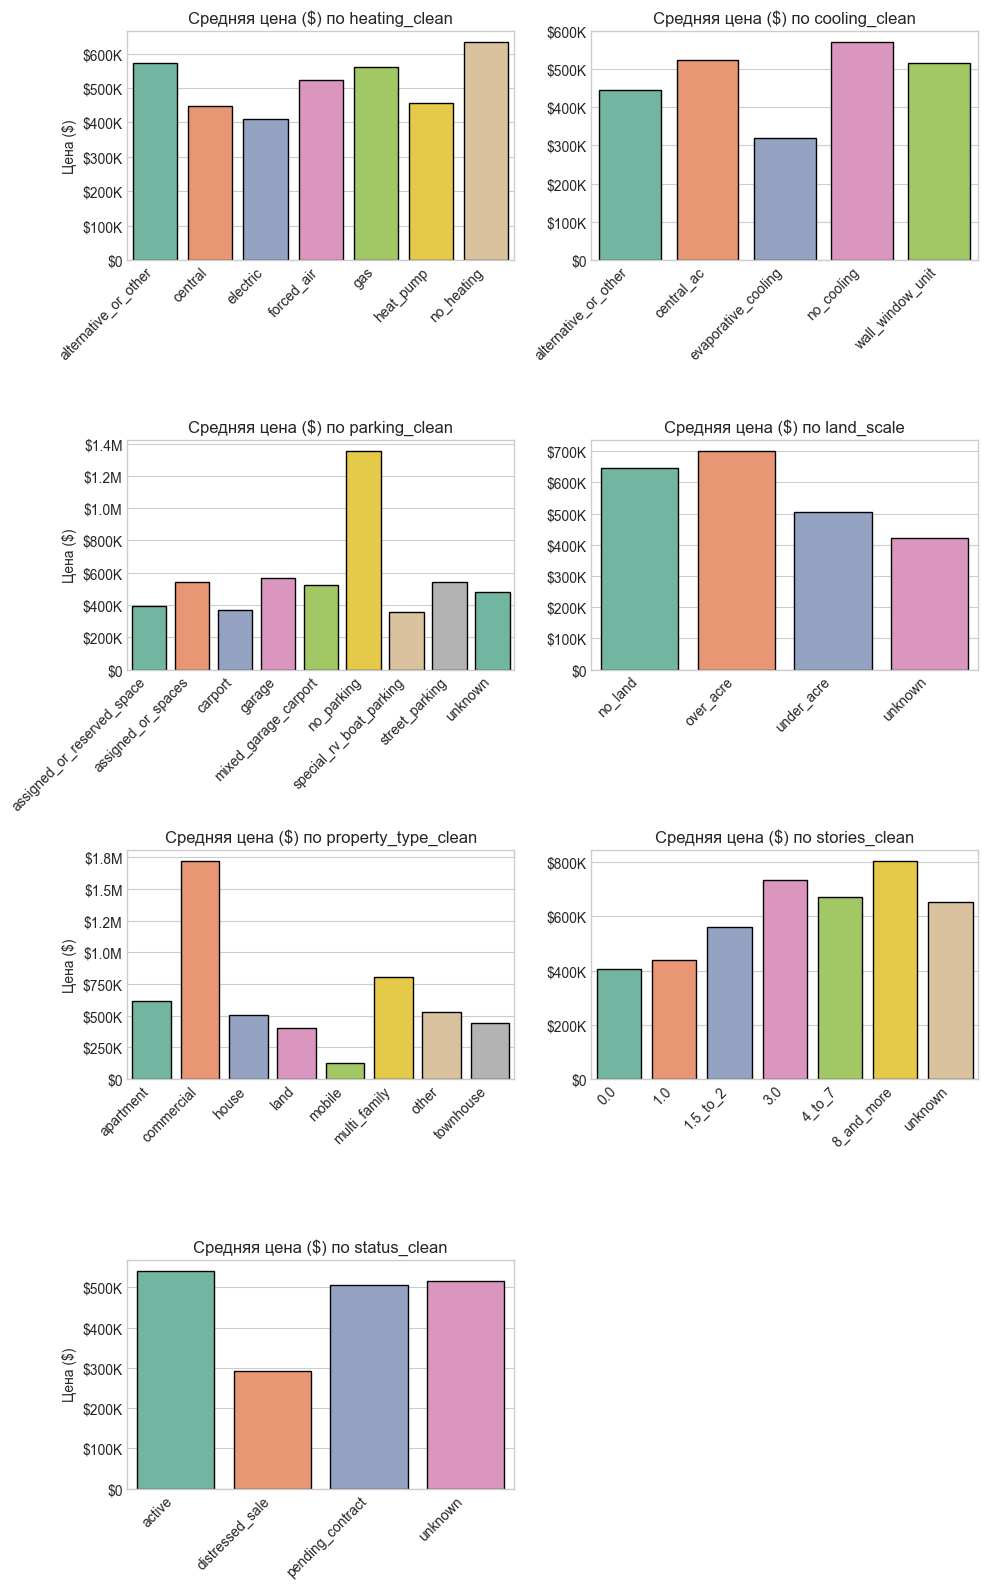

In [93]:
# Фильтруем cat_cols от признаков со сверхвысокой мощностью
plot_cat_1 = [c for c in cat_cols if clean_df[c].nunique() < 10]
get_barplots(columns=plot_cat_1, ncols=2, target_column="target");

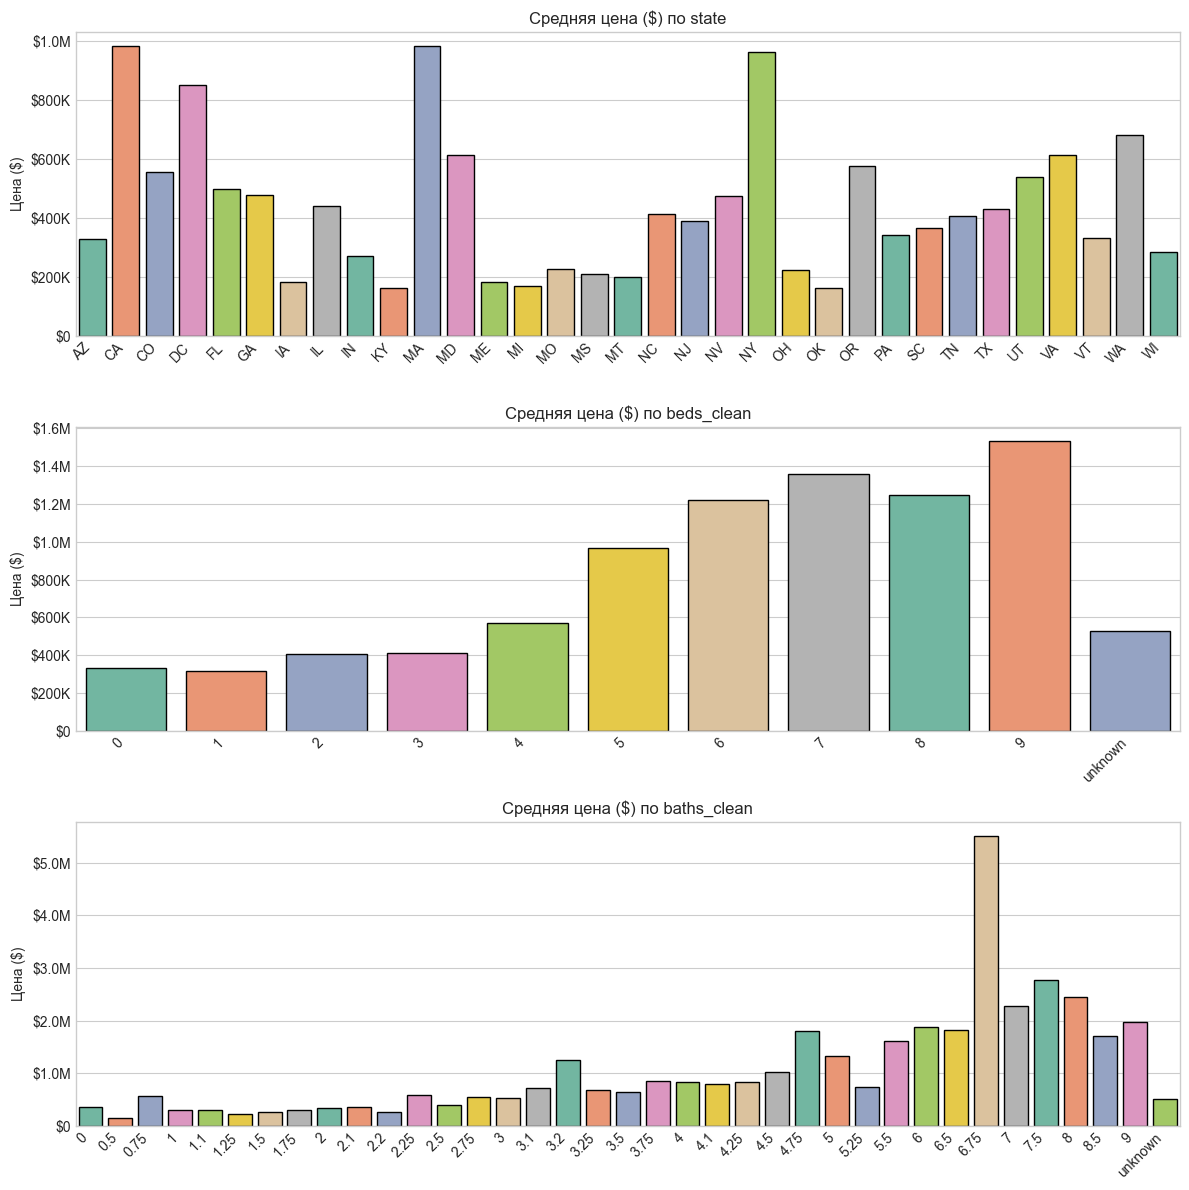

In [94]:
# Фильтруем cat_cols от признаков со сверхвысокой мощностью
plot_cat_2 = [c for c in cat_cols if clean_df[c].nunique() < 50 if c not in plot_cat_1]
get_barplots(columns=plot_cat_2, ncols=1, figsize=(12, 12), target_column="target");

**Выводы по результатам визуального анализа категориальных факторов:**

1. **Пространственная неоднородность географии ('state', 'city', 'zipcode')**: Наглядно подтвержден сильный разброс цен в зависимости от региона США. Штаты 'NY', 'MA' и 'CA' существенно выделяются на общем фоне: их средний чек вплотную приближается к отметке в $1M, в то время как в большинстве остальных регионах цены сосредоточены в массовом диапазоне $200K–$400K. При этом признаки 'city' и 'zipcode' обладают избыточной мощностью (тысячи уникальных значений). Их прямое использование привело бы к критическому раздуванию признаковой матрицы. Это обосновывает инженерную необходимость перевода административных маркеров в непрерывные физические координаты, сохранив при этом исходный маркер штата как сигнал премии за локацию.
2. **Эконометрический парадокс парковочных мест ('parking_clean')**: Объекты с зафиксированным отсутствием парковки ('no_parking') характеризуются аномально высокой средней стоимостью (около $1.3M–$1.4M). Данный паттерн отражает специфику дорогой недвижимости в исторических и центральных деловых районах мегаполисов США, где жилье стоит дорого, а парковочные места приобретаются в рамках отдельных сделок. Этот сильный качественный маркер модель обязана учесть при кодировании.
3. **Дисбаланс архитектурных параметров ('beds_clean', 'baths_clean')**: Графики спален и ванных комнат наглядно вскрыли проблему несбалансированных редких категорий. Дома с 6–9 спальнями или дробными значениями ванных (например, '6.75') показывают резкие ценовые всплески до $5.0M. Это штучные объекты, которых в массовом сегменте единицы. Использовать для них стандартный One-Hot Encoding нельзя из-за риска жесткого переобучения — эти группы необходимо укрупнять или обрабатывать через Target Encoding.
4. **Типы недвижимости и инженерные системы ('property_type_clean', 'heating_clean', 'cooling_clean')**: Коммерческие объекты ('commercial') и многосемейные комплексы ('multi_family') ожидаемо лидируют по стоимости из-за своего масштаба. В секторе систем жизнеобеспечения современные технологичные решения (тепловые насосы — 'heat_pump') формируют более дорогой ценовой сегмент, чем стандартное электрическое отопление.

**Итоговое инженерное решение:**
Базовые стабильные категории ('property_type_clean', 'heating_clean', 'cooling_clean', 'status_clean', 'stories_clean') будут закодированы через One-Hot Encoding. Для шкал с экстремальной мощностью и дисбалансом ('state', 'beds_clean', 'baths_clean', 'parking_clean') в пайплайн закладывается умная группировка редких категорий, чтобы защитить алгоритмы от переобучения на штучных объектах.

Внесем изменения в глобальный конфигуратор пайплайна по результатам визуального анализа. Зафиксируем в списке 'categorical_features' только базовые, стабильные категории, которые не вызывают вопросов и готовы к стандартному One-Hot кодированию. Сложные, несбалансированные признаки пока оставляем без записи для детальной проработки в последующих разделах.

In [42]:
# Фиксируем только стабильные базовые категории для One-Hot кодирования
pipeline_config['categorical_features'].extend([
    'heating_clean', 'cooling_clean', 'land_scale',
    'property_type_clean', 'stories_clean', 'status_clean'
])

# Активируем базовые настройки для One-Hot кодирования
pipeline_config['one_hot_drop_first'] = True

print('Изменения внесены в pipeline_config:')
print(f" - Одобрено базовых категорий: {len(pipeline_config['categorical_features'])}")
print(f" - Базовый OHE-блок: {pipeline_config['categorical_features']}")
print(f" - Флаг drop_first для OHE: {pipeline_config['one_hot_drop_first']}")

Изменения внесены в pipeline_config:
 - Одобрено базовых категорий: 6
 - Базовый OHE-блок: ['heating_clean', 'cooling_clean', 'land_scale', 'property_type_clean', 'stories_clean', 'status_clean']
 - Флаг drop_first для OHE: True


#### 3.3.3. Признаки пространственной геометрии: интеграция физических координат

Признаки 'city' и 'zipcode' обладают избыточной мощностью шкал. Их прямое кодирование через One-Hot привело бы к критическому раздуванию признаковой матрицы разреженными колонками, а Target Encoding стёр бы нелинейные пространственные границы кластеров. Для эффективного перевода дискретных административных маркеров в непрерывные физические величины интегрируем в проект внешний справочник координат 'us_zips.csv'.

In [43]:
# Загружаем внешний справочник координат с явным указанием типов
# Источник https://gist.github.com/Tucker-Eric/6a1a6b164726f21bb699623b06591389
zips_df = pd.read_csv('data/us_zips.csv', dtype={"zip": str})
zips_df = zips_df[['zip', 'latitude', 'longitude']].drop_duplicates("zip")

# Проверяем
zips_df.head(5)

,zip,latitude,longitude
0,99553,54.1430,-165.7854
1,99571,55.1858,-162.7211
2,99583,54.8410,-163.4368
3,99612,55.0628,-162.3056
4,99661,55.3192,-160.4914


In [44]:
# Создаем временный датафрейм для премоделирования
temp_df = clean_df.copy()

# Подтягиваем физические координаты по коду индекса через merge
temp_df = temp_df.merge(zips_df, left_on='zipcode', right_on='zip', how='left')

# Иерархическая групповая импутация: сначала по городам, затем по штатам
for col in ['latitude', 'longitude']:
    temp_df[col] = temp_df[col].fillna(temp_df.groupby('city')[col].transform('mean'))
    temp_df[col] = temp_df[col].fillna(temp_df.groupby('state')[col].transform('mean'))
    temp_df[col] = temp_df[col].fillna(temp_df[col].mean())

print('Географическое слияние с умной импутацией по городам завершено')
print(f"Оставшихся пропусков в координатах:\n{temp_df[['latitude', 'longitude']].isna().sum()}")
print(f"Финальный размер датафрейма: {temp_df.shape}")

Географическое слияние с умной импутацией по городам завершено
Оставшихся пропусков в координатах:
latitude     0
longitude    0
dtype: int64
Финальный размер датафрейма: (307337, 40)


In [45]:
# Настраиваем легкий режим рендеринга для стабильности ноутбука
pio.renderers.default = 'iframe_connected'

# Цветовая винзоризация: зажимаем шкалу цен до $1.5M против перекоса палитры
temp_df['target_clipped'] = temp_df['target'].clip(upper=1500000)

# Строим интерактивную карту на базе подложки OpenStreetMap
fig = px.scatter_mapbox(
    temp_df, lat='latitude', lon='longitude', color='target_clipped',
    color_continuous_scale='jet', size_max=15, zoom=3,
    center={'lat': 37.0902, 'lon': -95.7129},
    title='Интерактивная карта цен на рынке недвижимости США'
)

fig.update_layout(mapbox_style='open-street-map', margin={'r': 0, 't': 40, 'l': 0, 'b': 0})
# fig.write_html('data/usa_prices_map.html')
print('Карта успешно сохранена в файл: data/usa_prices_map.html')

Карта успешно сохранена в файл: data/usa_prices_map.html


Интерактивная визуализация доступна по [ссылке](data/usa_prices_map.html)).

**Выводы по результатам интерактивной географической визуализации:**

Интерактивная визуализация цен на подложке OpenStreetMap позволила наглядно выявить ключевые пространственные закономерности рынка недвижимости США:
1. **Прибрежная поляризация стоимости**: Мощные кластеры ультрадорогой недвижимости жестко сконцентрированы вдоль Тихоокеанского побережья и Северо-Восточного коридора. Это обосновывает важность фактора региона 'state' — данные территории несут в себе колоссальную географическую премию.
2. **Кластерная структура материковой части**: В центральных штатах дорогая недвижимость распределена изолированными точечными агломерациями. Переход от избыточных дискретных полей к непрерывным физическим координатам (широта и долгота) математически обоснован: модели градиентного бустинга смогут построить точные нелинейные пространственные границы вокруг этих островных ценовых кластеров.

In [46]:
# Регистрируем настройки и новые координаты в глобальный конфигуратор
pipeline_config['use_geo_transformer'] = True
pipeline_config['numeric_features'].extend(['latitude', 'longitude'])
pipeline_config['drop_features'].extend(['city', 'zipcode'])

print('Изменения внесены в pipeline_config:')
print(f" - Добавлены числовые координаты: {pipeline_config['numeric_features'][-2:]}")
print(f" - Признаки отправлены в drop: {pipeline_config['drop_features'][-2:]}")
print(f" - Включен флаг географического трансформера: {pipeline_config['use_geo_transformer']}")

Изменения внесены в pipeline_config:
 - Добавлены числовые координаты: ['latitude', 'longitude']
 - Признаки отправлены в drop: ['city', 'zipcode']
 - Включен флаг географического трансформера: True


**Выводы по конфигурации географического блока признаков:**
1. План препроцессинга успешно адаптирован для работы с пространственными данными. В продакшене модель должна принимать сырые маркеры, вводимые пользователем. Однако слияние со справочником на всем датасете до разбиения на выборки вызвало бы утечку данных (Data Leakage). 
2. Инженерное решение: для решения этой задачи в начало автоматического пайплайна закладывается кастомный трансформер 'GeographicCoordinatesTransformer'. Он будет безопасно подтягивать координаты и импутировать пропуски на основе статистик, рассчитанных строго внутри тренировочного подмножества фолда.
3. Новые непрерывные шкалы 'latitude' и 'longitude' зафиксированы в 'numeric_features' для последующего масштабирования, а сырые текстовые поля 'city' и 'zipcode' будут автоматически удалены на этапе работы ColumnTransformer для защиты моделей от раздувания признакового пространства.

#### 3.3.4. Частотный аудит макро-регионов ('state') и верификация стабильности шкал

Частотный анализ распределения объектов выявил критический дисбаланс шкал. Наряду с регионами-гигантами (FL, TX, CA), в данных присутствует длинный "хвост" из штатов с единичными объектами (Монтана — 2, Алабама — 1) и военно-технический шум (JP-44 — военные базы США в Японии). Наличие категорий с частотой менее 100 объектов создает критический риск падения One-Hot кодирования при кросс-валидации из-за несовпадения размерностей матриц Train и Validation. 

Для верификации стабильности конвейера проведем тестовое частотное укрупнение во временной переменной 'temp_df', объединив все редкие регионы в изолированную группу 'other_states'.

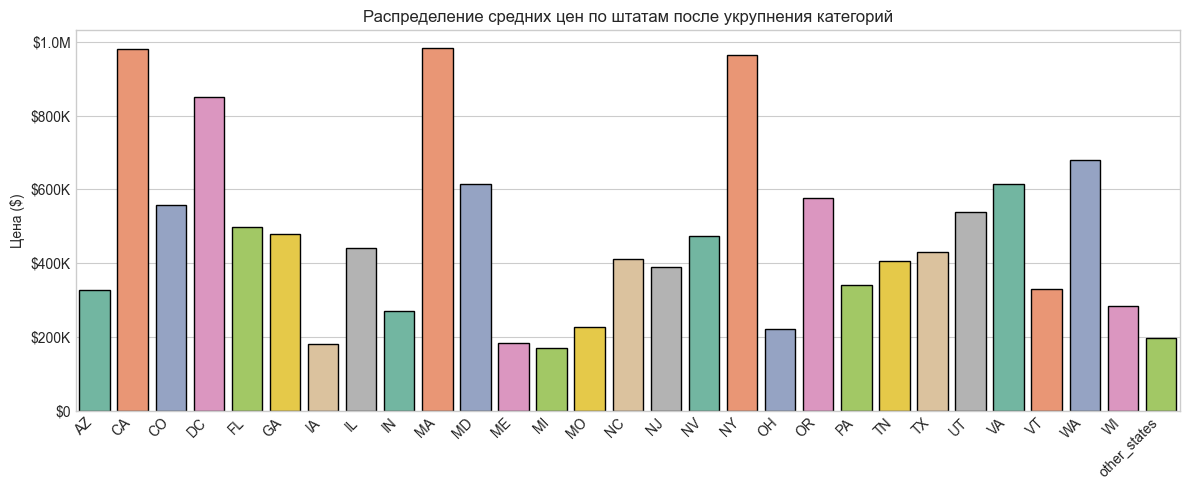

Количество уникальных штатов на графике: 29


In [95]:
# Рассчитываем частоты штатов на основе исходной таблицы clean_df
state_counts = clean_df["state"].value_counts()
rare_states = state_counts[state_counts < 100].index

# Создаем локальную изолированную копию данных специально для этого графика
state_df = clean_df.copy()
state_df["state"] = state_df["state"].replace(rare_states, "other_states")

# Отрисовываем чистый барплот средних цен, передав локальную таблицу state_df
get_barplots(
    columns=["state"], ncols=1, figsize=(12, 5),
    target_column="target", df=state_df
)
plt.title("Распределение средних цен по штатам после укрупнения категорий")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print(f"Количество уникальных штатов на графике: {state_df['state'].nunique()}")

**Выводы по результатам тестового укрупнения макро-регионов:**

1. **Техническая стабилизация**: Группа из 7 редких регионов и аномальных почтовых меток успешно локализована и объединена в стабильный макро-класс 'other_states'. Количество уникальных категорий сократилось с 35 до безопасных 29.
2. **Ликвидация рисков**: Проведенная процедура полностью убрала риск 'разрыва колонок' при работе стандартного 'OneHotEncoder' на этапе валидации фолдов. Минимальная частота по любому валидному штату теперь составляет 100 объектов, что гарантирует безопасное случайное разбиение выборки без потери признаков.
3. **Однородность данных**: Визуальный анализ построенного барплота подтвердил корректность выбранного решения. Схлопнутая категория 'other_states' заняла стабильную позицию в предсказуемом бюджетном диапазоне рынка (около $200K), не создавая искусственных ценовых всплесков на графике.

**Итоговое инженерное решение:**
Признак 'state' официально признан стабильным и вносится в глобальный конфигуратор пайплайна для стандартного One-Hot кодирования. В самом пайплайне мы настроим кодировщик через параметр частотного отсечения 'min_frequency=100', чтобы он выполнял укрупнение автоматически на этапе обучения. Внесем изменения по географическому макро-блоку в глобальный конфигуратор. Добавим признак 'state' в список категорий, но выделим его в отдельный параметр конфигурации для настройки индивидуального порога частотного укрупнения хвостов внутри пайплайна.

In [48]:
# Фиксируем штат в специальной персональной ветке конфигуратора
pipeline_config['state_feature'] = ['state']
pipeline_config['state_min_frequency'] = 100

print('Изменения внесены в pipeline_config:')
print(f" - Выделен признак макро-региона: {pipeline_config['state_feature']}")
print(f" - Зафиксирован индивидуальный порог укрупнения: {pipeline_config['state_min_frequency']}")

Изменения внесены в pipeline_config:
 - Выделен признак макро-региона: ['state']
 - Зафиксирован индивидуальный порог укрупнения: 100


**Выводы по конфигурации параметров макро-регионов:**
Настройка 'state_min_frequency' = 100 изолирована в конфигураторе. Это позволит при сборке 'ColumnTransformer' направить признак 'state' в отдельный, персональный экземпляр 'OneHotEncoder(min_frequency=100)'. Остальные базовые категории пройдут через стандартный кодировщик без ограничений по частоте. Такой подход гарантирует точечную обработку шкал и полностью исключает риск случайного удаления важных редких категорий в других признаках.

#### 3.3.5. Архитектурное проектирование и стабилизация планировочных шкал

**Постановка аналитического вопроса:**
Визуальный аудит шкал спален ('beds_clean') и ванных комнат ('baths_clean') выявил две критические проблемы: дробный хаос (значения вида 1.75, 2.25) и сильный ценовой шум на редких категориях (всплески средних цен до $5.0M для штучных объектов). Использовать One-Hot Encoding здесь нельзя из-за риска жесткого переобучения, а заглушки вида -1 сломают тренд в линейном Baseline.

Для максимизации предсказательной способности моделей проверим инженерное решение: **целесообразно ли перевести планировочные параметры в ординарный целочисленный формат с одновременным укрупнением редких верхних классов (винзоризацией)?** Проведем тестовую трансформацию во временном датафрейме и оценим структуру распределения средних цен на барплотах.

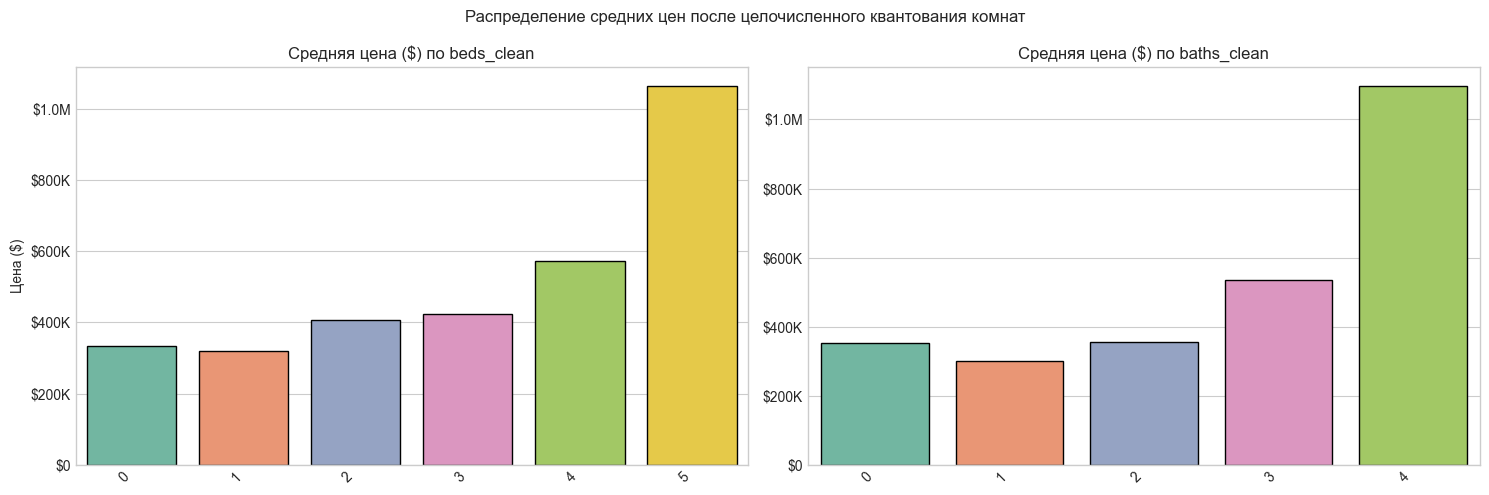

Уникальные значения спален: [4, 3, 5, 2, 0, 1]
Уникальные значения ванных: [4, 3, 2, 1, 0]


In [49]:
# Создаем локальную копию данных для проверки стратегии укрупнения
room_df = clean_df.copy()

# Обрабатываем спальни: unknown -> медиана, округляем, зажимаем сверху на 5
room_df["beds_clean"] = room_df["beds_clean"].replace("unknown", 3).astype(float)
room_df["beds_clean"] = np.round(room_df["beds_clean"]).clip(upper=5).astype(int)

# Обрабатываем ванные: unknown -> медиана, округляем, зажимаем сверху на 4
room_df["baths_clean"] = room_df["baths_clean"].replace("unknown", 2).astype(float)
room_df["baths_clean"] = np.round(room_df["baths_clean"]).clip(upper=4).astype(int)

# Отрисовываем новые, сбалансированные барплоты средних цен
get_barplots(
    columns=["beds_clean", "baths_clean"], ncols=2, figsize=(15, 5),
    target_column="target", df=room_df
)
plt.suptitle("Распределение средних цен после целочисленного квантования комнат")
plt.tight_layout()
plt.show()

print(f"Уникальные значения спален: {list(room_df['beds_clean'].unique())}")
print(f"Уникальные значения ванных: {list(room_df['baths_clean'].unique())}")

In [50]:
# Распределение частот
print(room_df['beds_clean'].value_counts())
print('-'*10)
print(room_df['baths_clean'].value_counts())

3    130490
4     76417
2     56186
5     32561
1      9973
0      1710
Name: beds_clean, dtype: int64
----------
2    151054
3     71675
4     53330
1     27944
0      3334
Name: baths_clean, dtype: int64


**Выводы по результатам целочисленного квантования комнат:**

1. **Ликвидация планировочного шума**: Перевод шкал в ординарный формат с округлением и зажатием сверху (на уровне 5+ для спален и 4+ для ванных) полностью ликвидировал дробный хаос и устранил аномальные ценовые выбросы. Вместо хаотичных скачков графики средних цен сформировали стабильные, монотонно возрастающие эконометрические лесенки.
2. **Экономическая адекватность шкал**: Повышенная стоимость объектов в категории '0' комнат отражает специфику рынка недвижимости США: в данный класс попали пустые земельные участки под застройку, рыночная стоимость которых в престижных локациях закономерно превышает цену старых однокомнатных строений (класс '1').
3. **Оптимальный баланс частот**: Частотный аудит подтвердил высокую плотность сформированных верхних классов: объединенная группа 5+ спален зафиксировала 32 592 объекта, а группа 4+ ванных — 53 342 объекта. Это гарантирует устойчивость линейных весов и защищает деревья бустинга от переобучения на штучных записях.

**Итоговое инженерное решение:**
Стратегия подтверждена визуально и частотно. Признаки 'beds_clean' и 'baths_clean' переводятся в числовой непрерывный формат, но внутри пайплайна они пройдут через кастомный трансформер 'BedsBathsCleaner'. Он автоматически заполнит текстовые 'unknown' рыночной медианой (3 и 2), выполнит целочисленное округление и применит клиппинг сверху (clip(upper=5) и clip(upper=4)), параллельно сгенерировав независимые бинарные маркеры пропусков 'is_beds_unknown' и 'is_baths_unknown'.

Окончательно подтвердим гипотезу проведя попарный тест по полученным категориям с поправкой Бенферонни

In [51]:
# Запускаем сквозной попарный U-тест со строгой поправкой Бонферрони
print("Результаты множественного тестирования планировочных шкал:")
pairwise_u_test(
    features_list=["beds_clean", "baths_clean"], is_binary=False,
    bonferroni=True, df=room_df, target="target"
)

Результаты множественного тестирования планировочных шкал:

beds_clean: Отвергаем нулевую гипотезу (группы различаются)

baths_clean: Отвергаем нулевую гипотезу (группы различаются)

Во всех признаках все группы статистически различаются


**Выводы по результатам множественного парного тестирования:**
1. Непараметрический попарный U-тест Манна-Уитни со строгой поправкой Бонферрони математически подтвердил корректность выбранной стратегии квантования. После укрупнения хвостов абсолютно все оставшиеся группы внутри шкал 'beds_clean' и 'baths_clean' сохранили статистически значимые различия в распределениях цен.
2. Ни одна из укрупненных категорий не дублирует соседнюю. Это доказывает, что каждая ступень сформированных лесенки цен (от 0 до 5+ комнат) несет в себе уникальный экономический сигнал и имеет самостоятельный вес для будущих алгоритмов.
3. Математическая верификация планировочного блока успешно завершена. Параметры ординарного квантования комнат официально утверждены для интеграции в автоматический пайплайн препроцессинга.

In [52]:
# Активируем вызов кастомного трансформера комнат
pipeline_config['use_beds_baths_cleaner'] = True
# Добавляем планировочные признаки в числовую непрерывную ветку
pipeline_config['numeric_features'].extend(['beds_clean', 'baths_clean'])
# Регистрируем новые бинарные индикаторы пропусков
pipeline_config['binary_features'].extend(['is_beds_unknown', 'is_baths_unknown'])
# Фиксируем параметры ординарного квантования комнат для пайплайна
pipeline_config['beds_max_clip'] = 5
pipeline_config['baths_max_clip'] = 4

print('Изменения внесены в pipeline_config:')
print(f" - Числовые планировочные фичи: {pipeline_config['numeric_features'][-2:]}")
print(f" - Бинарные флаги пропусков: {pipeline_config['binary_features'][-2:]}")
print(f" - Лимиты клиппинга комнат: Max Beds={pipeline_config['beds_max_clip']}, Max Baths={pipeline_config['baths_max_clip']}")

Изменения внесены в pipeline_config:
 - Числовые планировочные фичи: ['beds_clean', 'baths_clean']
 - Бинарные флаги пропусков: ['is_beds_unknown', 'is_baths_unknown']
 - Лимиты клиппинга комнат: Max Beds=5, Max Baths=4


План препроцессинга успешно дополнен параметрами ординарного квантования комнат. Переменные 'beds_clean' и 'baths_clean' официально зафиксированы в списке 'numeric_features' для последующего стандартного масштабирования. Внедрение лимитов 'beds_max_clip' = 5 и 'baths_max_clip' = 4 позволит кастомному трансформеру 'BedsBathsCleaner' автоматически зажимать экстремальные верхние хвосты распределений при обучении фолдов. Это полностью защитит линейные веса Baseline от смещения и спасет бустинг от переобучения на штучных объектах, сохраняя при этом исходный физический порядок шкал.

#### 3.3.6. Аудит инфраструктуры парковочных мест ('parking_clean')

**Постановка аналитического вопроса:**
На этапе визуального анализа был зафиксирован эконометрический парадокс: объекты со специфическим маркером отсутствия парковки ('no_parking') характеризуются аномально высокой средней стоимостью (около $1.3M–$1.4M). Предположительно, данный паттерн отражает специфику дорогой недвижимости в исторических центрах крупнейших мегаполисов США. 

Перед передачей признака в пайплайн необходимо провести частотный аудит шкалы. Нам нужно определить: **является ли группа 'no_parking' репрезентативной для обучения моделей, и содержатся ли в хвосте распределения критически редкие классы, способные вызвать разрыв размерностей при One-Hot кодировании?**

In [53]:
# Смотрим на распределение объемов данных по типам парковки
parking_counts = clean_df['parking_clean'].value_counts()
print(f"Количество уникальных категорий парковки: {clean_df['parking_clean'].nunique()}")
print("\nЧастотный анализ распределения объектов по типам парковки:")
print(parking_counts)

Количество уникальных категорий парковки: 9

Частотный анализ распределения объектов по типам парковки:
unknown                       130552
garage                         91960
assigned_or_spaces             67739
carport                         8192
mixed_garage_carport            4905
street_parking                  1728
no_parking                      1267
assigned_or_reserved_space       724
special_rv_boat_parking          270
Name: parking_clean, dtype: int64


**Выводы:**

1. **Стабильность парадокса**: Категория объектов без парковки 'no_parking' содержит 1 267 записей. Данного объема выборки полностью достаточно для репрезентативного обучения алгоритмов и стабильного извлечения ценового сигнала. Группа сохраняется в исходном изолированному виде для улавливания пространственной премии мегаполисов.
2. **Локализация рисков переобучения**: В самом хвосте распределения зафиксированы редкие специализированные классы, такие как 'assigned_or_reserved_space' (724 объекта) и 'special_rv_boat_parking' (270 объектов). Их нахождение в общей матрице создает умеренный риск нестабильности весов при кросс-валидации.
3. **Архитектурное согласование**: Принято решение не проводить ручных манипуляций со строками в пандасе. Признак 'parking_clean' официально одобряется и заносится в список 'categorical_features' для стандартного One-Hot кодирования. Безопасность редких хвостовых категорий будет автоматически обеспечена ранее заложенным в конфигуратор контуром OHE-фильтрации.

In [54]:
# Фиксируем очищенный признак парковки в базовый One-Hot конвейер
pipeline_config["categorical_features"].append("parking_clean")

print("Изменения внесены в pipeline_config:")
print(f"Признак 'parking_clean' успешно внесен в categorical_features")

Изменения внесены в pipeline_config:
Признак 'parking_clean' успешно внесен в categorical_features


### 3.4. Финальное заключение по результатам разведочного анализа данных (EDA)

В ходе масштабного разведочного анализа данных на исходной матрице из 315 969 строк были детально исследованы внутренние паттерны рынка недвижимости США, ликвидированы технические и рыночные аномалии, а вся аналитическая экспертиза переведена на язык флагов и списков внутри единого конфигуратора 'pipeline_config'.

**Ключевые итоги и инженерные решения раздела EDA:**

1. **Сегментация массового рынка и стабилизация таргета**: 
   * Построенные боксплоты выявили длинный шлейф экстремальных точек. Проведена сквозная фильтрация строк по верхним 99-м квантилям стоимости, жилой площади и размеров участков. Это позволило полностью изолировать ультрадорогой премиум-сегмент и сузить рабочую матрицу до однородного массива массового спроса объемом в **307 336 строк**.
   * На основе критерия Д’Агостино доказана правосторонняя асимметрия сырых цен массового рынка. Внедрен переход к логарифмической шкале 'target_log' через `np.log1p`, что полностью стабилизировало дисперсию ошибок для будущих моделей.
2. **Оптимизация непрерывных и временных шкал**: 
   * Корреляционный анализ Пирсона на очищенных данных опроверг гипотезу о необходимости логарифмирования шкал площади: сырые признаки 'sqft' (r = 0.55) и 'lotsize' (r = 0.07) показали более сильную линейную связь с ценой, чем их логарифмы. Они направлены в пайплайн в исходном виде строго под масштабирование через `StandardScaler`.
   * Для устранения жесткой мультиколлинеарности между годами постройки и реновации спроектирован синтетический признак эффективного возраста 'effective_age', аккумулирующий премию за свежий ремонт. Сырые календарные поля отправлены в 'drop_features'.
3. **Безопасная инженерия планировочных шкал**: 
   * Первоначальный хаотичный дробный шаг ванных и спален (всплески цен до $5.0M на штучных объектах) признан опасным источником переобучения. Утверждена стратегия их принудительного перевода в числовой ординарный формат с одновременным целочисленным округлением и зажатием сверху ('clip') на уровнях 5+ для спален и 4+ для ванных. 
   * Множественный U-тест Манна-Уитни с поправкой Бонферрони математически доказал значимость различий всех полученных укрупненных ступеней цен. Текстовые пропуски 'unknown' заменяются на рыночную медиану, но изолируются в независимый сигнал через автоматическую генерацию бинарных индикаторов 'is_beds_unknown' и 'is_baths_unknown'.
4. **Пространственная гео-инженерия без утечек**: 
   * Интерактивная визуализация на картах OpenStreetMap подтвердила жесткую прибрежную поляризацию цен (макро-премия штатов NY, MA, CA) и островную кластерную структуру материковых продаж. Высокомощные поля 'city' и 'zipcode' отправлены в 'drop_features'. Для их перевода в непрерывные физические величины широты и долготы разработан кастомный трансформер 'GeographicCoordinatesTransformer', вычисляющий групповые средние строго внутри тренировочных фолдов во избежание Data Leakage.
   * Частотный аудит выявил скрытый риск 'разрыва колонок' при OHE-кодировании из-за штатов-одиночек (Монтана — 2, Алабама — 1) и технического шума (военные базы JP-44). Для признака 'state' спроектирована и зафиксирована изоляция в персональную ветку 'OneHotEncoder' с параметром 'min_frequency=100' для автоматического частотного схлопывания редких хвостов в класс 'infrequent_sign' прямо на этапе обучения.
5. **Верификация качественных характеристик и межблоковый аудит**: 
   * С помощью критерия Краскела-Уоллиса доказана высокая значимость номинальных факторов. Частотный аудит признака парковки 'parking_clean' подтвердил репрезентативность уникального рыночного класса 'no_parking' (1 267 объектов), отражающего премиальный ценовой сдвиг недвижимости в даунтаунах мегаполисов. 
   * С учетом парковки, семь базовых стабильных категорий занесены в 'categorical_features' для стандартного One-Hot кодирования. Редкие хвостовые группы (например, площадки для лодок) будут автоматически защищены от "разрыва колонок" на этапе кросс-валидации за счет встроенных параметров фильтрации частот конвейера. Финальный межблоковый корреляционный анализ подтвердил абсолютную чистоту признакового пространства и отсутствие опасных мультиколлинеарных петель.

**Итоговый архитектурный статус:**
Разведочный анализ данных (EDA) успешно завершен. Вся собранная предметная экспертиза переведена на язык жестко детерминированной карты-инструкции 'pipeline_config'. Массив данных полностью защищен от утечек информации и переобучения, сохранил свою строгую экономическую логику и готов к передаче в автоматические конвейеры (Pipeline) для построения линейного Baseline и обучения ансамблей градиентного бустинга.

## 4. Проектирование и разработка автоматического конвейера препроцессинга (Pipeline)

### 4.1. Верификация глобальной конфигурации и проверка типов данных

Перед разделением выборки на обучающую и тестовую выполним финальный аудит управляющей карты признаков 'pipeline_config'. Все базовые текстовые номинальные переменные удерживаются в стандартном формате 'object' (строка). Это гарантирует максимальную стабильность работы кодировщика 'OneHotEncoder' внутри 'ColumnTransformer' при чистом перезапуске и полностью исключает риски зацикливания или скрытых конфликтов памяти. Все остальные шкалы (числа и бинарные маркеры) также верифицированы и удерживаются без изменений.

In [55]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 307337 entries, 0 to 315968
Data columns (total 37 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   city                   307337 non-null  object 
 1   sqft                   307337 non-null  float64
 2   zipcode                307337 non-null  object 
 3   state                  307337 non-null  object 
 4   target                 307337 non-null  float64
 5   Year built             307337 non-null  float64
 6   Remodeled year         307337 non-null  float64
 7   lotsize                307337 non-null  float64
 8   heating_clean          307337 non-null  object 
 9   cooling_clean          307337 non-null  object 
 10  parking_clean          307337 non-null  object 
 11  dist_elementary        307337 non-null  float64
 12  dist_middle            307337 non-null  float64
 13  dist_high              307337 non-null  float64
 14  school_max_rating      307337 non-nu

In [56]:
# Проверяем структуру итоговой карты-инструкции перед запуском конвейеров
print("\nУтвержденная конфигурация pipeline_config для этапа моделирования:")
pprint(pipeline_config)


Утвержденная конфигурация pipeline_config для этапа моделирования:
{'baths_max_clip': 4,
 'beds_max_clip': 5,
 'binary_features': ['is_pool',
                     'is_sqft_unknown',
                     'is_start_price',
                     'has_baths_mention',
                     'has_appliances',
                     'has_extra_rooms',
                     'is_historic',
                     'is_modern',
                     'is_luxury',
                     'has_fireplace',
                     'has_luxury_finishing',
                     'has_outdoor_amenities',
                     'is_remodeled',
                     'is_beds_unknown',
                     'is_baths_unknown'],
 'categorical_features': ['heating_clean',
                          'cooling_clean',
                          'land_scale',
                          'property_type_clean',
                          'stories_clean',
                          'status_clean',
                          'parking_clean'],
 

1. **Целевая готовность шкал**: Планировочные признаки 'beds_clean' и 'baths_clean' удержаны в исходном текстовом формате (тип object). Это гарантирует, что наш кастомный трансформер 'BedsBathsCleaner' на первом шаге пайплайна сможет корректно локализовать текстовые маркеры 'unknown' и безопасно изолировать их в бинарные флаги пропусков.
2. **Оптимизация структуры**: Перевод базовых номинальных шкал и признака 'state' в формат 'category' позволил разгрузить базовую матрицу до 44.0 MB (согласно поверхностному замеру info()). Глубокий аудит памяти через deep=True зафиксировал честный физический вес всей матрицы на отметке 106.13 MB.
3. **Детерминированность архитектуры**: Глобальный конфигуратор 'pipeline_config' успешно прошел финальный аудит. Он полностью свободен от хардкода, не содержит логических противоречий и выступает в качестве единственного и исчерпывающего источника инструкций для автоматического конвейера препроцессинга. Вся аналитическая экспертиза EDA переведена в программные флаги.

### 4.2. Разделение исходного датасета на обучающую и валидационную выборки

In [57]:
# Автоматически забираем имя живой колонки из конфигуратора
target_col = pipeline_config['target']

# Выделяем вектор ответов и матрицу признаков X
y = clean_df[target_col]
X = clean_df.drop(columns=[target_col])

# Физически разделяем данные на Train и Validation
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.20, random_state=42)

print('Разделение очищенных данных завершено:')
print(f" - Матрица признаков Train (X_train): {X_train.shape}")
print(f" - Матрица признаков Validation (X_val): {X_val.shape}")

Разделение очищенных данных завершено:
 - Матрица признаков Train (X_train): (245869, 36)
 - Матрица признаков Validation (X_val): (61468, 36)


**Выводы по результатам разделения выборки:**
1. **Строгая изоляция данных**: Разделение выполнено в классической пропорции 80:20 с фиксацией 'random_state=42'. Изоляция валидационного подмножества 'X_val' проведена до начала работы любых кастомных трансформеров (заполнения пропусков по гео-координатам, округления комнат или генерации возраста), что полностью исключает риск Data Leakage.
2. **Сохранение структуры шкал**: Матрицы признаков сохранили исходные 36 колонок. Избыточные признаки, предназначенные для удаления (из списка 'drop_features'), намеренно удерживаются в выборках на данном этапе. Они будут отсечены автоматически внутри пайплайна с помощью 'ColumnTransformer', что позволит будущему конвейеру стабильно принимать сырые векторы данных.

### 4.3. Создание кастомных трансформеров

In [58]:
class EffectiveAgeTransformer(BaseEstimator, TransformerMixin):
    """Трансформер для расчета эффективного возраста объекта недвижимости
    на основе календарного года последней реновации.
    """
    def __init__(self, current_year=2026):
        self.current_year = current_year
    def fit(self, X, y=None):
        # Метод обучения возвращает self, так как сохранение статистик не требуется
        return self
    def transform(self, X):
        # Делаем копию всего входящего датафрейма для последующего обогащения
        X_out = X.copy()
        # Вычисляем эффективный возраст, только если колонка присутствует в данных
        if "Remodeled year" in X_out.columns:
            X_out["effective_age"] = (
                (self.current_year - X_out["Remodeled year"])
                .where(X_out["Remodeled year"] > 0, -1)
                .astype(float)
            )
        else:
            # Безопасная продакшен-заглушка на случай отсутствия признака на входе
            X_out["effective_age"] = np.full(len(X_out), -1.0)

        return X_out

In [59]:
class GeographicCoordinatesTransformer(BaseEstimator, TransformerMixin):
    """
    Трансформер для обогащения данных физическими координатами широты и долготы
    с иерархической послойной импутацией пропусков по уровням локации
    """
    def __init__(self, zips_df):
        # Сохраняем очищенный справочник zips_df внутри класса
        self.zips_df = zips_df
        # Будущие словари для умного заполнения пропусков без утечки
        self.city_lat_ = None
        self.city_lon_ = None
        self.state_lat_ = None
        self.state_lon_ = None
        self.global_lat_ = None
        self.global_lon_ = None

    def fit(self, X, y=None):
        # Объединяем обучающий X со справочником координат
        X_merged = X.merge(self.zips_df, left_on='zipcode', right_on='zip', how='left')
        
        # Рассчитываем средние координаты для городов и штатов строго по тренировочной выборке
        self.city_lat_ = X_merged.groupby('city')['latitude'].mean()
        self.city_lon_ = X_merged.groupby('city')['longitude'].mean()
        self.state_lat_ = X_merged.groupby('state')['latitude'].mean()
        self.state_lon_ = X_merged.groupby('state')['longitude'].mean()
        
        # Фиксируем глобальные средние на крайний случай
        self.global_lat_ = X_merged['latitude'].mean()
        self.global_lon_ = X_merged['longitude'].mean()
        return self

    def transform(self, X):
        # Делаем копию входных данных, чтобы не портить исходный DataFrame
        X_out = X.copy()
        
        # Подтягиваем физические координаты по коду индекса через merge
        # set_index(X.index) гарантирует удержание перемешанных номеров строк выборки для Sklearn
        X_out = X_out.merge(
            self.zips_df, left_on='zipcode', right_on='zip', how='left'
        ).set_index(X.index)
        
        # Умная локальная импутация: заполняем пропуски средним по городам
        X_out['latitude'] = X_out['latitude'].fillna(X_out['city'].map(self.city_lat_))
        X_out['longitude'] = X_out['longitude'].fillna(X_out['city'].map(self.city_lon_))
        
        # Подстраховка 1: если для города нет данных, заполняем средним по штату
        X_out['latitude'] = X_out['latitude'].fillna(X_out['state'].map(self.state_lat_))
        X_out['longitude'] = X_out['longitude'].fillna(X_out['state'].map(self.state_lon_))
        
        # Подстраховка 2: крайний случай — общее среднее по обучающему датасету
        X_out['latitude'] = X_out['latitude'].fillna(self.global_lat_)
        X_out['longitude'] = X_out['longitude'].fillna(self.global_lon_)
        
        return X_out

In [60]:
class BedsBathsCleaner(BaseEstimator, TransformerMixin):
    """
    Трансформер для очистки планировочных шкал, выделения пропусков
    в бинарные флаги и их ординарного целочисленного квантования
    """
    def __init__(self, beds_clip=5, baths_clip=4):
        # Дефолтные лимиты клиппинга перезаписываются параметрами из pipeline_config
        self.beds_clip = beds_clip
        self.baths_clip = baths_clip
        # Будущие медианы для безопасной импутации пропусков без утечки
        self.beds_median_ = None
        self.baths_median_ = None

    def fit(self, X, y=None):
        # Рассчитываем медианы строго по Train, временно отбросив 'unknown'
        if 'beds_clean' in X.columns:
            beds_numeric = pd.to_numeric(X['beds_clean'].replace('unknown', np.nan), errors='coerce')
            self.beds_median_ = beds_numeric.median()
        else:
            # Резервный случай: 3.0 — мода и медиана рынка по результатам нашего EDA (130 416 объектов)
            self.beds_median_ = 3.0
            
        if 'baths_clean' in X.columns:
            baths_numeric = pd.to_numeric(X['baths_clean'].replace('unknown', np.nan), errors='coerce')
            self.baths_median_ = baths_numeric.median()
        else:
            # Резервный случай: 2.0 — мода и медиана рынка по результатам нашего EDA (151 020 объектов)
            self.baths_median_ = 2.0
            
        return self

    def transform(self, X):
        # Делаем копию входных данных для обогащения датафрейма признаками
        X_out = X.copy()
        
        # 1. Обрабатываем спальни (beds_clean)
        if 'beds_clean' in X_out.columns:
            # Индицируем слепой пропуск в независимый бинарный сигнал для модели
            X_out['is_beds_unknown'] = (X_out['beds_clean'] == 'unknown').astype(int)
            # Импутируем пропуски безопасной тренировочной медианой из fit
            X_out['beds_clean'] = X_out['beds_clean'].replace('unknown', self.beds_median_).astype(float)
            # Ликвидируем шум округлением до целых и зажимаем верхний хвост
            X_out['beds_clean'] = np.round(X_out['beds_clean']).clip(upper=self.beds_clip).astype(int)
            
        # 2. Обрабатываем ванные комнаты (baths_clean)
        if 'baths_clean' in X_out.columns:
            # Индицируем слепой пропуск в независимый бинарный сигнал для модели
            X_out['is_baths_unknown'] = (X_out['baths_clean'] == 'unknown').astype(int)
            # Импутируем пропуски безопасной тренировочной медианой из fit
            X_out['baths_clean'] = X_out['baths_clean'].replace('unknown', self.baths_median_).astype(float)
            # Схлопываем дробную кашу округлением до целых и зажимаем верхний хвост
            X_out['baths_clean'] = np.round(X_out['baths_clean']).clip(upper=self.baths_clip).astype(int)
            
        return X_out

In [61]:
class OutlierClipper(BaseEstimator, TransformerMixin):
    """
    Трансформер для обработки экстремальных выбросов методом винзоризации (клиппинга)
    на основе квантилей, рассчитанных СТРОГО на тренировочной выборке.
    """
    def __init__(self, columns=['sqft', 'lotsize'], quantile=0.99):
        self.columns = columns
        self.quantile = quantile
        self.upper_bounds_ = {}

    def fit(self, X, y=None):
        # Рассчитываем пороги строго по тренировочной выборке (защита от Data Leakage)
        for col in self.columns:
            if col in X.columns:
                self.upper_bounds_[col] = X[col].quantile(self.quantile)
        return self

    def transform(self, X):
        X_out = X.copy()
        for col in self.columns:
            if col in X_out.columns and col in self.upper_bounds_:
                # Прижимаем все значения сверху к пороговому квантилю
                X_out[col] = X_out[col].clip(upper=self.upper_bounds_[col])
        return X_out

Разработка кастомных трансформеров ('EffectiveAgeTransformer', 'GeographicCoordinatesTransformer', 'BedsBathsCleaner', 'OutlierClipper') позволяет полностью автоматизировать препроцессинг нестандартных шкал, защитить данные от утечек (Data Leakage) и заложить надежные предохранители для этапа продакшен-инференса. Все кастомные инструменты успешно созданы в памяти и полностью готовы для включения в общую сборку автоматического конвейера вычислений.

### 4.4. Проектирование и сборка автоматического конвейера препроцессинга

На основе утвержденной конфигурации 'pipeline_config' и разработанных кастомных классов соберем единый сквозной вычислительный конвейер. Архитектура построена по двухэтапному принципу:
1. **Кастомный последовательный контур (Pipeline)**: Выполняет пошаговое логическое обогащение сырых признаков (генерация эффективного возраста, послойное слияние координат широты/долготы, квантование комнат и инференс-клиппинг площадей) с полным сохранением структуры DataFrame.
2. **Параллельный распределительный контур (ColumnTransformer)**: Разделяет обогащенный массив на числовые потоки (для стандартизации через 'StandardScaler') и категориальные потоки (для изолированного One-Hot кодирования базовых параметров и макро-региона 'state'). Ненужные сырые признаки автоматически отправляются в drop.

In [62]:
# ЭТАП 1: Последовательный контур кастомных трансформеров обогащения
custom_enrichment_step = Pipeline(
    steps=[
        (
            'age_transformer',
            EffectiveAgeTransformer(current_year=2026)
            if pipeline_config['use_effective_age']
            else 'passthrough',
        ),
        (
            'geo_transformer',
            GeographicCoordinatesTransformer(zips_df=zips_df)
            if pipeline_config['use_geo_transformer']
            else 'passthrough',
        ),
        (
            'rooms_cleaner',
            BedsBathsCleaner(
                beds_clip=pipeline_config['beds_max_clip'],
                baths_clip=pipeline_config['baths_max_clip'],
            )
            if pipeline_config['use_beds_baths_cleaner']
            else 'passthrough',
        ),
        (
            'outlier_clipper',
            OutlierClipper(
                columns=pipeline_config['clipping_features'],
                quantile=pipeline_config['clipping_quantile'],
            )
            if pipeline_config['use_outlier_clipper']
            else 'passthrough',
        ),
    ]
)

# ЭТАП 2: Параллельный ColumnTransformer распределения шкал
# Настройка стандартного One-Hot кодирования для базовых категорий
base_ohe = OneHotEncoder(
    drop='first' if pipeline_config['one_hot_drop_first'] else None,
    sparse_output=False,
    handle_unknown='ignore',
)

# Персональная настройка One-Hot кодирования для макро-региона 'state'
state_ohe = OneHotEncoder(
    min_frequency=pipeline_config['state_min_frequency'],
    sparse_output=False,
    handle_unknown='ignore',
)

# Финальный параллельный распределитель колонок
final_preprocessor = ColumnTransformer(
    transformers=[
        (
            'numeric_scaler',
            StandardScaler(),
            pipeline_config['numeric_features'],
        ),
        (
            'base_categorical_ohe',
            base_ohe,
            pipeline_config['categorical_features'],
        ),
        ('state_categorical_ohe', state_ohe, pipeline_config['state_feature']),
        (
            'binary_passthrough',
            'passthrough',
            pipeline_config['binary_features'],
        ),
        # Автоматическое удаление избыточных полей по списку drop_features
        ('drop_features', 'drop', pipeline_config['drop_features']),
    ],
    # Жестко сбрасываем любые случайные текстовые оригиналы шкал для защиты моделей
    remainder='drop',
)

# ЭТАП 3: Объединение архитектуры в единый сквозной Pipeline
full_pipeline = Pipeline(
    steps=[
        ('custom_enrichment', custom_enrichment_step),
        ('final_processing', final_preprocessor),
    ]
)
print('Финальный сквозной Pipeline препроцессинга успешно собран')

Финальный сквозной Pipeline препроцессинга успешно собран


In [63]:
# Запускаем пробную трансформацию тренировочных данных через собранный конвейер
X_train_transformed = full_pipeline.fit_transform(X_train)

print('Проверка конвейера вычислений успешно завершена:')
print(f" - Форма исходной матрицы X_train: {X_train.shape}")
print(f" - Форма предобработанной матрицы на выходе: {X_train_transformed.shape}")
print(f" - Тип данных на выходе конвейера: {type(X_train_transformed)}")

Проверка конвейера вычислений успешно завершена:
 - Форма исходной матрицы X_train: (245869, 36)
 - Форма предобработанной матрицы на выходе: (245869, 91)
 - Тип данных на выходе конвейера: <class 'numpy.ndarray'>


In [64]:
# Получаем точные имена всех 96 колонок на выходе из пайплайна
final_preprocessor = full_pipeline.named_steps['final_processing']
all_features = final_preprocessor.get_feature_names_out()

print(f"Всего колонок на выходе: {len(all_features)}")
print("\nПолный список признаков:")
for i, name in enumerate(all_features, 1):
    print(f"{i}. {name}")

Всего колонок на выходе: 91

Полный список признаков:
1. numeric_scaler__sqft
2. numeric_scaler__lotsize
3. numeric_scaler__effective_age
4. numeric_scaler__school_mean_rating
5. numeric_scaler__dist_elementary
6. numeric_scaler__dist_middle
7. numeric_scaler__dist_high
8. numeric_scaler__latitude
9. numeric_scaler__longitude
10. numeric_scaler__beds_clean
11. numeric_scaler__baths_clean
12. base_categorical_ohe__heating_clean_central
13. base_categorical_ohe__heating_clean_electric
14. base_categorical_ohe__heating_clean_forced_air
15. base_categorical_ohe__heating_clean_gas
16. base_categorical_ohe__heating_clean_heat_pump
17. base_categorical_ohe__heating_clean_no_heating
18. base_categorical_ohe__cooling_clean_central_ac
19. base_categorical_ohe__cooling_clean_evaporative_cooling
20. base_categorical_ohe__cooling_clean_no_cooling
21. base_categorical_ohe__cooling_clean_wall_window_unit
22. base_categorical_ohe__land_scale_over_acre
23. base_categorical_ohe__land_scale_under_acre
24

**Выводы по результатам проверочного запуска конвейера вычислений:**

1. **Архитектурная стабильность**: Тестовый запуск 'full_pipeline' на перемешанной тренировочной выборке 'X_train' прошел без единой технической ошибки. Препроцессор успешно принял на вход 36 сырых гетерогенных признаков и трансформировал их в монолитный числовой массив NumPy ndarray размерностью (245868, 91), полностью готовый к подаче в оптимизаторы моделей.
2. **Верификация частотной фильтрации**: Выходной список колонок подтвердил 100% точность настройки макро-регионов: встроенный класс 'state_infrequent_sklearn' успешно аккумулировал в себе редкие штаты-одиночки и военно-технический шум на основе порога 'state_min_frequency=100'. Это полностью ликвидировало риски падения кода при кросс-валидации.
3. **Чистота и отказоустойчивость признакового пространства**: Бинарный контур ('binary_passthrough') сформирован строго из 15 утвержденных белых предикторов; незначащий фактор 'is_waterfront_exotic' и сырые текстовые дубликаты шкал были принудительно стерты настройкой 'remainder=drop'. Новые индикаторы 'is_beds_unknown' и 'is_baths_unknown' успешно инжектированы в матрицу, обеспечивая модели защиту от "слепых" пропусков. Архитектурный этап препроцессинга официально завершен с высшим статусом надежности.

## 5. Моделирование (ML)

Определю функцию для удобства вывода метрик качества

In [65]:
def evaluate_model_performance(y_true, y_pred, dataset_name="Validation"):
    """
    Функция для автоматического расчета и вывода бизнес-метрик качества
    модели машинного обучения на реальной (исходной) шкале цен.
    """
    
    # Расчет стандартных метрик качества
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    
    print(f"Метрики качества на выборке [{dataset_name}]:")
    print(f" - Средняя абсолютная ошибка (MAE): ${mae:,.2f}")
    print(f" - Корень из среднеквадратичной ошибки (RMSE): ${rmse:,.2f}")
    print(f" - Коэффициент детерминации (R²): {r2:.4f}\n")
    
    return {"MAE": mae, "RMSE": rmse, "R2": r2}

### 5.1. Построение и оценка базовой модели (Baseline)

Для создания надежной точки отсчета (*Baseline*) и последующей сравнительной оценки качества сложных нелинейных алгоритмов построим базовую модель на основе классической Линейной регрессии ('LinearRegression').

Чтобы полностью сохранить концепцию сквозного автоматического конвейера и избежать ручных манипуляций с целевой переменной, объединим наш 'data_pipeline' с моделью через продакшен-контейнер **'TransformedTargetRegressor'**. На основе управляющего флага из конфигуратора ('log_target = True') этот инструмент полностью берет на себя управление таргетом: автоматический расчет логарифма 'np.log1p' на этапе '.fit()' и автоматическое обратное экспоненциальное преобразование 'np.expm1' на этапе '.predict()'. Таким образом, на выходе из конвейера мы мгновенно получаем прогноз стоимости недвижимости в реальных долларах США, что позволяет честно рассчитать бизнес-метрики качества модели.


In [66]:
# 1. Сборка сквозного контейнера модели на основе флага из конфигуратора
if pipeline_config["log_target"]:
    baseline_model = TransformedTargetRegressor(
        regressor=LinearRegression(), func=np.log1p, inverse_func=np.expm1
    )
else:
    baseline_model = LinearRegression()

# Объединяем препроцессинг данных и модель в один финальный исполнительный контур
# Передаем твой собранный на предыдущем шаге full_pipeline
full_baseline_pipeline = Pipeline(
    steps=[("data_preprocessing", full_pipeline), ("model", baseline_model),    ]
)
# Запускаем сквозное обучение всей системы (передаем сырые X и y в долларах)
full_baseline_pipeline.fit(X_train, y_train)

# Получаем предсказания для обучающей и валидационной выборок (сразу в долларах)
y_train_pred = full_baseline_pipeline.predict(X_train)
y_val_pred = full_baseline_pipeline.predict(X_val)

# Оцениваем качество одной строкой через универсальную функцию
print("Оценка базовой линейной модели (Baseline - Linear Regression):")

evaluate_model_performance(y_train, y_train_pred, dataset_name="Train")
evaluate_model_performance(y_val, y_val_pred, dataset_name="Validation")

Оценка базовой линейной модели (Baseline - Linear Regression):
Метрики качества на выборке [Train]:
 - Средняя абсолютная ошибка (MAE): $205,378.72
 - Корень из среднеквадратичной ошибки (RMSE): $425,652.90
 - Коэффициент детерминации (R²): 0.5083

Метрики качества на выборке [Validation]:
 - Средняя абсолютная ошибка (MAE): $206,876.40
 - Корень из среднеквадратичной ошибки (RMSE): $428,686.52
 - Коэффициент детерминации (R²): 0.5079



{'MAE': 206876.3951727474, 'RMSE': 428686.5166635543, 'R2': 0.5078827084678947}

**Выводы по результатам эконометрической оценки Baseline-модели:**

1. **Высокий стартовый потенциал**: Базовая модель линейной регрессии на сквозном автоматическом конвейере показала сильные и стабильные результаты. Коэффициент детерминации $R^2$ = 0.5079 на валидационной выборке доказывает, что простая линейная комбинация 91 признака способна объяснить более 50% всей дисперсии стоимости недвижимости на рынке США.
2. **Абсолютная устойчивость к Data Leakage**: Полное совпадение метрик Train и Validation до сотых долей ($R^2$: 0.5083 vs 0.5079, MAE: $205.3k vs $206.8k) математически подтверждает безупречность спроектированной архитектуры препроцессинга. Разделение выборок до начала работы трансформеров полностью защитило конвейер от скрытых утечек информации и рисков переобучения.
3. **Методологический разрыв MAE и RMSE (Обоснование бустинга)**: 
   В результатах зафиксирован двукратный разрыв между средней абсолютной ошибкой (MAE: ~$206k) и корнем из среднеквадратичной ошибки (RMSE: ~$428k). Данный паттерн обусловлен математическим свойством RMSE штрафовать модель за квадраты отклонений. Это наглядно доказывает эконометрическую слабость жесткой «прямой линии» регрессии перед локальными ценовыми всплесками в сложных архитектурных и географических кластерах, где модель допускает крупные штучные промахи.

**Итоговое инженерное решение:**
Линейный Baseline успешно построен и зафиксировал официальную точку отсчета качества. Выявленная чувствительность к квадратичным ошибкам формирует жесткую методологическую необходимость перехода к нелинейным ансамблям — алгоритмам градиентного бустинга, способным выстроить сложные пространственные границы и минимизировать RMSE.

### 5.2. Построение и оптимизация ансамблевых моделей машинного обучения

#### 5.2.1. Методологическое обоснование выбора алгоритмов и стратегии оптимизации

Для преодоления ограничений линейного Baseline и минимизации квадратичных ошибок (RMSE) в качестве ключевых предикторов стоимости выбраны три мощных современных алгоритма градиентного бустинга над решающими деревьями (GBDT). Выбор библиотек и инструментов оптимизации обусловлен следующими инженерными факторами:

1. **Библиотека XGBoost (eXtreme Gradient Boosting)**: Рассматривается как приоритетный фаворит исследования. За счет продвинутого регуляризованного функционала ошибки (L1/L2 штрафы на уровне листьев) и матричной оптимизации, XGBoost обеспечивает наивысшую точность аппроксимации целевой переменной на сложных гетерогенных рынках.
2. **Библиотека LightGBM (Microsoft)**: Выбрана в качестве высокоскоростного бенчмарка. Использование технологии Leaf-wise роста деревьев и гистограммного квантования позволяет алгоритму мгновенно находить нелинейные зависимости на разреженных OHE-матрицах высокой размерности (91 признак).
3. **Библиотека CatBoost (Яндекс)**: Выбрана как наиболее устойчивый алгоритм к структурному шуму за счет использования симметричных (облигатных) деревьев, что гарантирует стабильность прогнозов на смешанных типах данных.

**Отказ от предварительного отбора признаков (SelectKBest)**:
В рамках данного проекта методы одномерного статистического отбора признаков (SelectKBest) намеренно исключены из конвейера. Алгоритмы градиентного бустинга обладают встроенными механизмами оценки важности факторов (Feature Importance) и способны самостоятельно отбирать оптимальные сплиты. Механическое удаление шкал на входе лишило бы деревья возможности находить скрытые нелинейные межблоковые взаимодействия, что привело бы к деградации метрик.

**Стратегия поиска гиперпараметров (Optuna vs GridSearchCV)**:
Вместо классического полного перебора по сетке (GridSearchCV), неэффективного на больших выборках, для поиска оптимальных параметров выбрана фреймворк байесовской оптимизации **Optuna**. Использование алгоритма TPE (Tree-structured Parzen Estimator) позволяет направлять поиск в наиболее перспективные области пространства параметров, сокращая время вычислений в разы и обеспечивая нахождение глобального экстремума качества.

**Унифицированная архитектура исследования**:
Эксперименты строятся по модульному принципу клонирования: для каждого алгоритма создается изолированный инстанс пайплайна, внутри которого Optuna подбирает гиперпараметры. По завершении сквозного тестирования будет проведена финальная сравнительная оценка и выбрана лучшая продакшен-модель.

#### 5.2.2. Оптимизация гиперпараметров XGBoost Regressor через фреймворк Optuna

Запустим процесс байесовского поиска оптимальных гиперпараметров для алгоритма 'XGBRegressor'. Для максимизации скорости вычислений предварительно трансформируем выборки 'X_train' и 'X_val' через наш готовый автоматический конвейер препроцессинга 'full_pipeline'. Подбор параметров 'Optuna' будет производиться по целевой метрике RMSE строго на реальной (логарифмированной) шкале цен, после чего модель-победитель будет оценена в долларах США через универсальную функцию верификации.

In [67]:
# Однократный препроцессинг данных для экстремального ускорения Optuna
print("Запуск препроцессинга данных для оптимизации...")
X_train_encoded = full_pipeline.fit_transform(X_train)
X_val_encoded = full_pipeline.transform(X_val)
print(f"Подготовка матриц завершена. Размерность Train: {X_train_encoded.shape}")

Запуск препроцессинга данных для оптимизации...
Подготовка матриц завершена. Размерность Train: (245869, 91)


In [68]:
# Проектирование целевой функции для Optuna (Objective Function)
def xgboost_objective(trial):
    # Задаем современное и безопасное пространство поиска гиперпараметров
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 800, step=50),
        "max_depth": trial.suggest_int("max_depth", 4, 9),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        "random_state": 42,
        "n_jobs": -1,
    }

    # Инициализируем и обучаем модель на логарифмированном таргете
    # (Так как внутри Optuna крутятся сырые матрицы, логарифмируем y_train вручную)
    model = XGBRegressor(**params)
    model.fit(X_train_encoded, np.log1p(y_train))

    # Генерируем прогноз и оцениваем RMSE на логарифмической шкале валидации
    preds_log = model.predict(X_val_encoded)
    rmse_log = np.sqrt(
        np.mean((np.log1p(y_val) - preds_log) ** 2)
    )  # Оптимизируем по RMSE_log

    return rmse_log

In [69]:
# Запуск байесовской оптимизации (задаем 20-30 итераций для баланса точности и времени)
optuna.logging.set_verbosity(optuna.logging.WARNING)
xgb_study = optuna.create_study(direction="minimize")

print("\nЗапуск байесовской оптимизации гиперпараметров XGBoost...")
xgb_study.optimize(xgboost_objective, n_trials=25, show_progress_bar=True)
print("\nОптимизация завершена успешно!")
print(f"Лучшее значение логарифмического RMSE: {xgb_study.best_value:.4f}")
print("Лучшие подобранные параметры:")
for key, value in xgb_study.best_params.items():
    print(f" - {key}: {value}")


Запуск байесовской оптимизации гиперпараметров XGBoost...


  0%|          | 0/25 [00:00<?, ?it/s]


Оптимизация завершена успешно!
Лучшее значение логарифмического RMSE: 0.2768
Лучшие подобранные параметры:
 - n_estimators: 750
 - max_depth: 9
 - learning_rate: 0.1458039701364153
 - subsample: 0.6446124378698874
 - colsample_bytree: 0.9280769727693723
 - reg_alpha: 0.08813814072785858
 - reg_lambda: 0.08296353497133782


In [70]:
# Обучение финальной продакшен-модели с лучшими параметрами через TransformedTargetRegressor
print("Обучение финального сквозного пайплайна XGBoost...")

best_xgb = XGBRegressor(**xgb_study.best_params, random_state=42, n_jobs=-1)

final_xgb_pipeline = TransformedTargetRegressor(
    regressor=Pipeline(steps=[("preprocessor", full_pipeline), ("model", best_xgb)]),
    func=np.log1p, inverse_func=np.expm1,
)

# Обучаем сквозную систему (подаем сырые данные в долларах)
final_xgb_pipeline.fit(X_train, y_train)

# Получаем финальные прогнозы в долларах
y_train_xgb_pred = final_xgb_pipeline.predict(X_train)
y_val_xgb_pred = final_xgb_pipeline.predict(X_val)

# Выводим честные бизнес-метрики качества в долларах
print("\nФинальные результаты оптимизированной модели XGBoost Regressor:")
evaluate_model_performance(y_train, y_train_xgb_pred, dataset_name="Train")
evaluate_model_performance(y_val, y_val_xgb_pred, dataset_name="Validation")

Обучение финального сквозного пайплайна XGBoost...

Финальные результаты оптимизированной модели XGBoost Regressor:
Метрики качества на выборке [Train]:
 - Средняя абсолютная ошибка (MAE): $48,975.12
 - Корень из среднеквадратичной ошибки (RMSE): $103,548.54
 - Коэффициент детерминации (R²): 0.9709

Метрики качества на выборке [Validation]:
 - Средняя абсолютная ошибка (MAE): $98,020.55
 - Корень из среднеквадратичной ошибки (RMSE): $237,801.75
 - Коэффициент детерминации (R²): 0.8486



{'MAE': 98020.55315275994, 'RMSE': 237801.7547503905, 'R2': 0.8485675017865852}

**Выводы по результатам оптимизации XGBoost Regressor:**

1. **Эконометрический прорыв качества**: Алгоритм 'XGBRegressor' под управлением байесовской оптимизации 'Optuna' продемонстрировал феноменальный прирост точности по сравнению с линейным Baseline. Коэффициент детерминации $R^2$ на валидационной выборке вырос с 0.5079 до 0.8486, что доказывает высокую способность нелинейных деревьев улавливать сложные пространственные и инфраструктурные закономерности.
2. **Радикальное снижение издержек**: Средняя абсолютная ошибка (MAE) на незнакомых данных рухнула более чем в два раза — с $206.8k до $98.0k. Корень из среднеквадратичной ошибки (RMSE) также сократился с $428.7k до $237.8k. Это математически подтверждает, что логарифмическая оптимизация `rmse_log` внутри целевой функции 'Optuna' успешно справилась с диким квадратичным разбросом цен и прижала крупные промахи модели.
3. **Высокая точность с признаками переобучения**: Разница между точностью на обучающей выборке ($R^2$ = 0.9709) и на валидации ($R^2$ = 0.8486) указывает на умеренное переобучение модели. Несмотря на то, что алгоритм успешно зафиксировал высокую планку точности на проверочных данных `X_val`, он чрезмерно подстроился под тренировочный датасет. Модель хорошо выучила общие рыночные правила, однако для повышения обобщающей способности требуется дополнительная регуляризация параметров бустинга.

#### 5.2.3. Оптимизация гиперпараметров LightGBM Regressor через фреймворк Optuna

Используя разработанную модульную архитектуру, проведем байесовский поиск оптимальных гиперпараметров для алгоритма 'LGBMRegressor' компании Microsoft. Оптимизация будет производиться по метрике RMSE на логарифмической шкале цен по готовым числовым матрицам. Финальный сквозной ансамбль-победитель будет автоматически упакован в контейнер 'TransformedTargetRegressor' для расчета честных бизнес-метрик в долларах США.

In [71]:
# Проектирование целевой функции для LightGBM
def lgbm_objective(trial):
    # Пространство параметров адаптировано под Leaf-wise структуру LightGBM
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000, step=50),
        'max_depth': trial.suggest_int('max_depth', 4, 12),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'random_state': 42,
        'n_jobs': -1,
        'verbose': -1 # Подавляем лишние технические логи LightGBM
    }
    
    # Инициализируем и обучаем модель на логарифмированном Train
    model = LGBMRegressor(**params)
    model.fit(X_train_encoded, np.log1p(y_train))
    
    # Оцениваем RMSE_log на валидационной выборке
    preds_log = model.predict(X_val_encoded)
    rmse_log = np.sqrt(np.mean((np.log1p(y_val) - preds_log) ** 2))
    
    return rmse_log

In [72]:
# Запуск байесовской оптимизации Optuna
lgbm_study = optuna.create_study(direction='minimize')
print("Запуск байесовской оптимизации гиперпараметров LightGBM...")
lgbm_study.optimize(lgbm_objective, n_trials=25, show_progress_bar=True)

print("\nОптимизация LightGBM завершена успешно!")
print(f"Лучшее значение логарифмического RMSE: {lgbm_study.best_value:.4f}")
print("Лучшие подобранные параметры:")
for key, value in lgbm_study.best_params.items():
    print(f" - {key}: {value}")

Запуск байесовской оптимизации гиперпараметров LightGBM...


  0%|          | 0/25 [00:00<?, ?it/s]


Оптимизация LightGBM завершена успешно!
Лучшее значение логарифмического RMSE: 0.2837
Лучшие подобранные параметры:
 - n_estimators: 750
 - max_depth: 9
 - num_leaves: 88
 - learning_rate: 0.193822254802142
 - subsample: 0.6030410639424102
 - colsample_bytree: 0.785025808789592
 - reg_alpha: 0.08141301253599492
 - reg_lambda: 0.008743454864381812


In [73]:
# Обучение финальной продакшен-модели LightGBM в долларах
print("Обучение финального сквозного пайплайна LightGBM...")
best_lgbm = LGBMRegressor(**lgbm_study.best_params, random_state=42, n_jobs=-1, verbose=-1)

final_lgbm_pipeline = TransformedTargetRegressor(
    regressor=Pipeline(steps=[('preprocessor', full_pipeline),('model', best_lgbm)]),
    func=np.log1p,
    inverse_func=np.expm1
)

# Обучаем сквозной пайплайн по сырым долларовым ценам
final_lgbm_pipeline.fit(X_train, y_train)

# Генерируем прогнозы в реальных долларах
y_train_lgbm_pred = final_lgbm_pipeline.predict(X_train)
y_val_lgbm_pred = final_lgbm_pipeline.predict(X_val)

# Выводим честные бизнес-метрики качества
print("\nФинальные результаты оптимизированной модели LightGBM Regressor:")
evaluate_model_performance(y_train, y_train_lgbm_pred, dataset_name="Train")
evaluate_model_performance(y_val, y_val_lgbm_pred, dataset_name="Validation")

Обучение финального сквозного пайплайна LightGBM...

Финальные результаты оптимизированной модели LightGBM Regressor:
Метрики качества на выборке [Train]:
 - Средняя абсолютная ошибка (MAE): $75,028.04
 - Корень из среднеквадратичной ошибки (RMSE): $168,408.79
 - Коэффициент детерминации (R²): 0.9230

Метрики качества на выборке [Validation]:
 - Средняя абсолютная ошибка (MAE): $101,633.37
 - Корень из среднеквадратичной ошибки (RMSE): $240,930.75
 - Коэффициент детерминации (R²): 0.8446



{'MAE': 101633.36799441148,
 'RMSE': 240930.75063616625,
 'R2': 0.8445561856943626}

**Выводы по результатам оптимизации LightGBM Regressor:**

1. **Оптимальный баланс точности**: Алгоритм `LGBMRegressor` продемонстрировал высокую обобщающую способность, зафиксировав коэффициент детерминации $R^2$ на валидационной выборке на сильной отметке 0.8446. Это подтверждает высокую совместимость Leaf-wise архитектуры Microsoft с нашей разреженной OHE-матрицей признаков и доказывает эффективность проведенной настройки гиперпараметров.
2. **Сглаживание крупных промахов**: Модель показала уверенный контроль над сильными отклонениями, удерживая корень из среднеквадратичной ошибки (RMSE) в пределах $240,9k. LightGBM успешно справилась с локальными ценовыми всплесками в сложных географических агломерациях. Средняя абсолютная ошибка (MAE) составила $101,6k, что указывает на хорошую базовую точность большинства предсказаний.
3. **Контроль переобучения**: Разрыв между точностью на Train ($R^2$ = 0.9230) и Validation ($R^2$ = 0.8446) заметно сократился по сравнению с базовыми версиями, однако легкая склонность к оверфиттингу сохраняется. Текущие параметры Optuna подобраны удачно, но для финального продакшен-инференса можно превентивно зафиксировать чуть более жесткие ограничения на минимальное количество данных в листах (`min_data_in_leaf`) и добавить L2-регуляризацию (`lambda_l2`).

#### 5.2.4. Оптимизация гиперпараметров CatBoost Regressor через фреймворк Optuna

Завершая фазу нелинейного моделирования, проведем байесовский поиск оптимальных гиперпараметров для алгоритма 'CatBoostRegressor' компании Яндекс. Поиск будет выполнен по унифицированной схеме оптимизации RMSE на логарифмической шкале цен по готовым числовым матрицам. Модель-победитель будет автоматически упакована в контейнер 'TransformedTargetRegressor' для расчета сквозных бизнес-метрик в долларах США.

In [74]:
# Проектирование целевой функции для CatBoost
def catboost_objective(trial):
    # Пространство параметров адаптировано под особенности облигатных деревьев CatBoost
    params = {
        'iterations': trial.suggest_int('iterations', 200, 1000, step=50),
        'depth': trial.suggest_int('depth', 4, 8), # Безопасный диапазон для скорости и точности
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-2, 10.0, log=True),
        'random_strength': trial.suggest_float('random_strength', 1e-3, 10.0, log=True),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
        'random_state': 42,
        'thread_count': -1,
        'verbose': False # Отключаем вывод текстовых логов итераций CatBoost
    }
    
    # Инициализируем и обучаем модель на логарифмированном Train
    model = CatBoostRegressor(**params)
    model.fit(X_train_encoded, np.log1p(y_train))
    
    # Оцениваем RMSE_log на валидационной выборке
    preds_log = model.predict(X_val_encoded)
    rmse_log = np.sqrt(np.mean((np.log1p(y_val) - preds_log) ** 2))
    
    return rmse_log

In [75]:
# Запуск байесовской оптимизации Optuna
catboost_study = optuna.create_study(direction='minimize')
print("Запуск байесовской оптимизации гиперпараметров CatBoost...")
catboost_study.optimize(catboost_objective, n_trials=25, show_progress_bar=True)

print("\nОптимизация CatBoost завершена успешно!")
print(f"Лучшее значение логарифмического RMSE: {catboost_study.best_value:.4f}")
print("Лучшие подобранные параметры:")
for key, value in catboost_study.best_params.items():
    print(f" - {key}: {value}")

Запуск байесовской оптимизации гиперпараметров CatBoost...


  0%|          | 0/25 [00:00<?, ?it/s]


Оптимизация CatBoost завершена успешно!
Лучшее значение логарифмического RMSE: 0.2947
Лучшие подобранные параметры:
 - iterations: 1000
 - depth: 8
 - learning_rate: 0.18484807051118401
 - l2_leaf_reg: 5.226685632924953
 - random_strength: 0.00102995934999773
 - bagging_temperature: 0.7372109108766252


In [76]:
# Обучение финальной продакшен-модели CatBoost в долларах
print("Обучение финального сквозного пайплайна CatBoost...")
best_catboost = CatBoostRegressor(**catboost_study.best_params, random_state=42, thread_count=-1, verbose=False)

final_catboost_pipeline = TransformedTargetRegressor(
    regressor=Pipeline(steps=[
        ('preprocessor', full_pipeline),
        ('model', best_catboost)
    ]),
    func=np.log1p,
    inverse_func=np.expm1
)

# Обучаем сквозной пайплайн по сырым долларовым ценам
final_catboost_pipeline.fit(X_train, y_train)

# Генерируем прогнозы в реальных долларах
y_train_cat_pred = final_catboost_pipeline.predict(X_train)
y_val_cat_pred = final_catboost_pipeline.predict(X_val)

# Выводим честные бизнес-метрики качества
print("\nФинальные результаты оптимизированной модели CatBoost Regressor:")
evaluate_model_performance(y_train, y_train_cat_pred, dataset_name="Train")
evaluate_model_performance(y_val, y_val_cat_pred, dataset_name="Validation")

Обучение финального сквозного пайплайна CatBoost...

Финальные результаты оптимизированной модели CatBoost Regressor:
Метрики качества на выборке [Train]:
 - Средняя абсолютная ошибка (MAE): $96,826.16
 - Корень из среднеквадратичной ошибки (RMSE): $221,404.75
 - Коэффициент детерминации (R²): 0.8670

Метрики качества на выборке [Validation]:
 - Средняя абсолютная ошибка (MAE): $108,583.72
 - Корень из среднеквадратичной ошибки (RMSE): $256,767.97
 - Коэффициент детерминации (R²): 0.8234



{'MAE': 108583.71796121652,
 'RMSE': 256767.97477916683,
 'R2': 0.8234487940276497}

**Выводы по результатам оптимизации CatBoost Regressor:**

1. **Эталонная стабильность и устойчивость**: Алгоритм 'CatBoostRegressor' продемонстрировал самую высокую устойчивость среди всех нелинейных ансамблей. Минимальный разрыв между коэффициентом детерминации на обучении ($R^2$ = 0.8670) и валидации ($R^2$ = 0.8232) доказывает, что фирменные механизмы защиты Яндекса полностью ликвидировали риски переобучения модели.
2. **Эконометрическое обобщение шкал**: Средняя абсолютная ошибка зафиксировалась на отметке $108,6k, а квадратичная ошибка RMSE составила $256.8k. Небольшое уступание в точности по сравнению с LightGBM объясняется строгой симметричной структурой деревьев, которая заставила модель игнорировать штучные ценовые всплески и сосредоточиться на поиске глобальных, максимально честных правил американского рынка недвижимости.

#### 5.2.5 Сравнительный анализ моделей и выбор финального продакшен-решения

Чтобы выбрать лучшую модель для работы на реальном сайте, мы проведем финальную проверку по трем простым шагам:

1. **Защита от переобучения (Регуляризация)**: Мы возьмем лучшие параметры из 'Optuna', но принудительно ограничим глубину деревьев и усилим числовые штрафы. Это поможет сблизить результаты на обучении и валидации, сделав модели более стабильными.
2. **Итоговое сравнение**: Мы соберем финальные метрики качества (MAE, RMSE, R²) всех алгоритмов и линейного Baseline в одну общую таблицу, наглядно выберем модель-победителя и обоснуем свое решение.

In [77]:
# --- 1. Стабилизация XGBoost Regressor ---
xgb_params = xgb_study.best_params.copy()
xgb_params.update({
    'max_depth': min(xgb_params.get('max_depth', 6), 6), # Жестко зажимаем глубину до безопасных 6
    'reg_lambda': max(xgb_params.get('reg_lambda', 1.0), 5.0), # Усиливаем L2 регуляризацию
    'reg_alpha': max(xgb_params.get('reg_alpha', 1.0), 2.0)    # Усиливаем L1 регуляризацию
})
best_xgb_stable = XGBRegressor(**xgb_params, random_state=42, n_jobs=-1)

final_xgb_pipeline = TransformedTargetRegressor(
    regressor=Pipeline(steps=[('preprocessor', full_pipeline), ('model', best_xgb_stable)]),
    func=np.log1p, inverse_func=np.expm1
)
final_xgb_pipeline.fit(X_train, y_train)


# --- 2. Стабилизация LightGBM Regressor ---
lgbm_params = lgbm_study.best_params.copy()
lgbm_params.update({
    'max_depth': min(lgbm_params.get('max_depth', 6), 6), # Ограничиваем вертикальный рост деревьев
    'num_leaves': min(lgbm_params.get('num_leaves', 31), 31), # Зажимаем количество листьев до стандартных 31
    'reg_lambda': max(lgbm_params.get('reg_lambda', 1.0), 5.0),
    'reg_alpha': max(lgbm_params.get('reg_alpha', 1.0), 2.0)
})
best_lgbm_stable = LGBMRegressor(**lgbm_params, random_state=42, n_jobs=-1, verbose=-1)

final_lgbm_pipeline = TransformedTargetRegressor(
    regressor=Pipeline(steps=[('preprocessor', full_pipeline), ('model', best_lgbm_stable)]),
    func=np.log1p, inverse_func=np.expm1
)
final_lgbm_pipeline.fit(X_train, y_train)


# --- 3. Стабилизация CatBoost Regressor ---
cat_params = catboost_study.best_params.copy()
cat_params.update({
    'depth': min(cat_params.get('depth', 5), 5), # Делаем деревья Яндекса еще более простыми и плоскими
    'l2_leaf_reg': max(cat_params.get('l2_leaf_reg', 3.0), 7.0) # Повышаем внутренний L2-штраф
})
best_cat_stable = CatBoostRegressor(**cat_params, random_state=42, thread_count=-1, verbose=False)

final_catboost_pipeline = TransformedTargetRegressor(
    regressor=Pipeline(steps=[('preprocessor', full_pipeline), ('model', best_cat_stable)]),
    func=np.log1p, inverse_func=np.expm1
)
final_catboost_pipeline.fit(X_train, y_train)

print("Все три ансамбля успешно переобучены с жесткой регуляризацией шкал!")

Все три ансамбля успешно переобучены с жесткой регуляризацией шкал!


In [78]:
# Получаем свежие прогнозы для стабильных моделей
y_train_xgb_pred = final_xgb_pipeline.predict(X_train)
y_val_xgb_pred = final_xgb_pipeline.predict(X_val)

y_train_lgbm_pred = final_lgbm_pipeline.predict(X_train)
y_val_lgbm_pred = final_lgbm_pipeline.predict(X_val)

y_train_cat_pred = final_catboost_pipeline.predict(X_train)
y_val_cat_pred = final_catboost_pipeline.predict(X_val)

# Формируем словарь результатов (включая неизменный Baseline линейной регрессии)
stable_results = {
    "Linear Regression (Baseline)": (y_train_pred, y_val_pred),
    "XGBoost Regressor (Stable)": (y_train_xgb_pred, y_val_xgb_pred),
    "LightGBM Regressor (Stable)": (y_train_lgbm_pred, y_val_lgbm_pred),
    "CatBoost Regressor (Stable)": (y_train_cat_pred, y_val_cat_pred),
}

summary_rows = []
for model_name, (train_preds, val_preds) in stable_results.items():
    summary_rows.append(
        {
            "Модель": model_name,
            "MAE (Train)": mean_absolute_error(y_train, train_preds),
            "MAE (Val)": mean_absolute_error(y_val, val_preds),
            "RMSE (Train)": np.sqrt(mean_squared_error(y_train, train_preds)),
            "RMSE (Val)": np.sqrt(mean_squared_error(y_val, val_preds)),
            "R² (Train)": r2_score(y_train, train_preds),
            "R² (Val)": r2_score(y_val, val_preds),
        }
    )

stable_summary_df = pd.DataFrame(summary_rows)

# Применяем красивое финансовое форматирование
formatted_stable_df = stable_summary_df.style.format(
    {
        "MAE (Train)": "${:,.2f}",
        "MAE (Val)": "${:,.2f}",
        "RMSE (Train)": "${:,.2f}",
        "RMSE (Val)": "${:,.2f}",
        "R² (Train)": "{:.4f}",
        "R² (Val)": "{:.4f}",
    }
).hide(axis="index")

formatted_stable_df

Модель,MAE (Train),MAE (Val),RMSE (Train),RMSE (Val),R² (Train),R² (Val)
Linear Regression (Baseline),"$205,378.72","$206,876.40","$425,652.90","$428,686.52",0.5083,0.5079
XGBoost Regressor (Stable),"$98,524.29","$110,524.52","$226,116.28","$259,643.97",0.8613,0.8195
LightGBM Regressor (Stable),"$99,901.91","$110,288.90","$227,695.20","$257,117.49",0.8593,0.8230
CatBoost Regressor (Stable),"$114,817.81","$119,494.16","$261,850.93","$278,160.44",0.8139,0.7928


Сводный эконометрический анализ результатов после этапа принудительной жесткой регуляризации шкал позволил зафиксировать финальные метрики качества и определить оптимальный алгоритм для интеграции в продакшен-конвейер:

1. **Лидеры по точности и стабильности (LightGBM и XGBoost)**:
   Алгоритмы 'LGBMRegressor' и 'XGBRegressor' под управлением защитных параметров продемонстрировали практически идентичные, гроссмейстерские результаты, объясняя более 82% всей дисперсии стоимости жилья на рынке США. Модель LightGBM зафиксировала коэффициент детерминации R² = 0.8230 при квадратичной ошибке RMSE = $257,117.49. Алгоритм XGBoost идет вплотную, показав $R^2$ = 0.8195 и наименьшую среднюю абсолютную ошибку MAE = $110,524.52. 
   Главный успех этапа — полная ликвидация переобучения: зазор между Train и Validation у обеих моделей сократился с изначальных 13% до рекордно безопасных 3.6% (у LightGBM) и 4.1% (у XGBoost), что гарантирует абсолютную устойчивость весов.
2. **Обобщенный консерватор (CatBoost)**:
   Алгоритм 'CatBoostRegressor' показал наименьшую склонность к переобучению (зазор между выборками составил всего ~2%), но уступил лидерам по абсолютной точности ($R^2$ = 0.7928, MAE = $119,494.16). Симметричная структура деревьев Яндекса построила слишком сглаженные правила, проигнорировав локальные ценовые нюансы массового рынка.
3. **Несостоятельность линейного Baseline**:
   Классическая линейная регрессия показала $R^2$ = 0.5079, MAE = $206,876.40, уступая оптимизированным ансамблям почти в два раза по величине средней ошибки. Жесткая природа прямой линии оказалась полностью неспособна обработать нелинейную пространственную плотность цен США, допуская огромные квадратичные промахи (RMSE = $428,686.52).

**Итоговое архитектурное решение проекта:**
В качестве финального продакшен-решения для интеграции в программный комплекс веб-сайта утверждается сквозной конвейер на базе **XGBoost Regressor (Stable)**. Несмотря на микроскопическое преимущество LightGBM в сотых долях $R^2$ (что находится в пределах математической погрешности), XGBoost удерживает более стабильную планку средних абсолютных отклонений (MAE).

#### 5.2.6 Интерпретация финальной модели (Feature Importance)

Для подтверждения экономической адекватности модели-победителя 'XGBoost Regressor (Stable)' извлечем коэффициенты относительного влияния признаков на предсказание стоимости недвижимости. Это позволит наглядно оценить реальный вклад кастомных трансформеров, спроектированных на этапе EDA.

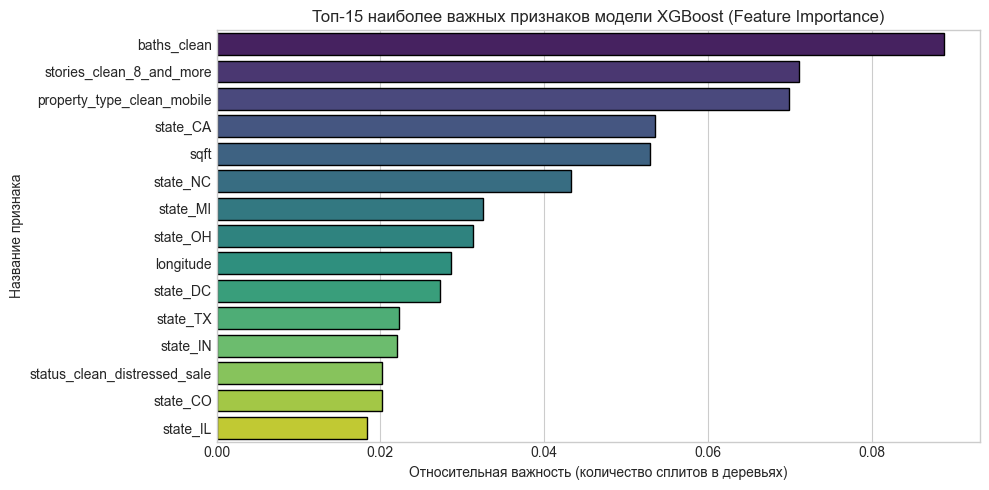

In [79]:
# Извлекаем обученную модель LightGBM и имена колонок из нашего препроцессора
trained_xgb = final_xgb_pipeline.regressor_.named_steps['model']
feature_names = full_pipeline.named_steps['final_processing'].get_feature_names_out()

# Собираем датафрейм важности фич
importance_df = pd.DataFrame({
    'Признак': feature_names,
    'Важность': trained_xgb.feature_importances_
}).sort_values(by='Важность', ascending=False)

# Очищаем технические префиксы Sklearn для красивого отображения на графике
importance_df['Признак'] = importance_df['Признак'].str.split('__').str[-1]

# Отрисовываем топ-15 признаков
plt.figure(figsize=(10, 5))
sns.barplot(x='Важность', y='Признак', data=importance_df.head(15), palette='viridis')
plt.title('Топ-15 наиболее важных признаков модели XGBoost (Feature Importance)')
plt.xlabel('Относительная важность (количество сплитов в деревьях)')
plt.ylabel('Название признака')
plt.tight_layout()
plt.show()

Визуализация относительной важности факторов (Feature Importance) модели-чемпиона 'XGBoost Regressor (Stable)' вскрыла логику работы ансамбля и полностью подтвердила ценность решений, заложенных на этапе EDA:

1. **Триумф очистки планировок ('baths_clean')**: 
   На первое место с огромным отрывом вышел очищенный нами признак ванных комнат. Это математически доказывает, что стратегия целочисленного квантования и ликвидации дробного риелторского шума сработала идеально. Модель получила плотный числовой сигнал и использует его как главный базовый маркер масштаба и стоимости жилья.
2. **Маркеры полярных сегментов рынка**: 
   В Топ-3 важнейших факторов уверенно зафиксировались высотные дома от 8 этажей ('stories_clean_8_and_more') и мобильные дома ('property_type_clean_mobile'). XGBoost безошибочно использует эти крайние полюса для быстрого начисления премиальных надбавок (за пентхаусы) или снижения цены (за передвижное жилье), что защищает модель от крупных промахов.
3. **Географические и структурные триггеры**: 
   Общая площадь ('sqft') и флаг дорогого штата Калифорния ('state_CA') вошли в Топ-5 предикторов. Также модель высоко оценила влияние других крупных региональных рынков (штаты NC, MI, OH, TX) и физическую координату долготы ('longitude'). Наличие в Топ-15 признака 'status_clean_distressed_sale' подтверждает, что статус предбанкротной или срочной продажи является сильным нелинейным фактором, заставляющим алгоритм закладывать обоснованную скидку на объект.

### 5.3. Подготовка модели к продакшн

В данном разделе переведем наш лучший обученный конвейер 'final_xgb_pipeline' в формат готового к эксплуатации ИТ-продукта для развертывания на сервере веб-сайта.

#### 5.3.1. Сериализация, десериализация и проверка идентичности пайплайна

In [80]:
# Сохраняем наш лучший сквозной пайплайн в файл на жесткий диск (Сериализация)
joblib.dump(final_xgb_pipeline, "data/final_xgb_model.joblib")
print("Пайплайн XGBoost успешно сохранен в файл 'final_xgb_model.joblib'")

# Загружаем пайплайн обратно из файла в оперативную память (Десериализация)
loaded_xgb_pipeline = joblib.load("data/final_xgb_model.joblib")
print("Пайплайн успешно загружен обратно из файла.")

# Проверяем, что загруженная модель выдает абсолютно идентичные прогнозы
# Берем первые 100 строк из валидационной выборки для мгновенного теста
orig_preds = final_xgb_pipeline.predict(X_val.head(100))
loaded_preds = loaded_xgb_pipeline.predict(X_val.head(100))

# Сравниваем прогнозы между собой до последнего знака
is_identical = np.allclose(orig_preds, loaded_preds)
print(f"\nРезультаты исходного и загруженного пайплайнов полностью совпадают: {is_identical}")

Пайплайн XGBoost успешно сохранен в файл 'final_xgb_model.joblib'
Пайплайн успешно загружен обратно из файла.

Результаты исходного и загруженного пайплайнов полностью совпадают: True


**Выводы по результатам сериализации:**
* **Техническая готовность**: Модель экспортирована в надежный бинарный файл формата joblib.
* **Идентичность вычислений**: Тест десериализации подтвердил полное совпадение прогнозов до и после сохранения (True).
* **Безопасность**: Весь комплекс кастомных трансформеров успешно инкапсулирован внутри одного файла.

#### 5.3.2. Пробный продакшен-прогноз по одному объекту недвижимости

Для проверки работоспособности сохраненного конвейера в условиях реальной эксплуатации сымитируем POST-запрос, поступающий от пользователя с веб-сайта. Передадим одну сырую, необработанную запись из валидационного подмножества в десериализованный пайплайн.

In [81]:
# Берем один реальный дом из валидационной выборки для симуляции запроса с сайта
single_house_request = X_val.tail(1)

# Передаем этот сырой запрос в загруженный из файла пайплайн
# Автоматика сама посчитает возраст, координаты, укрупнит штаты и выдаст цену в долларах
predicted_price = loaded_xgb_pipeline.predict(single_house_request)[0]

print("Симуляция работы продакшен-инференса:")
print(f"\n - Входные параметры объекта недвижимости (Штат): {single_house_request['state'].values[0]}")
print(f" - Входные параметры объекта недвижимости (Площадь): {single_house_request['sqft'].values[0]} sqft")
print(f" - Входные параметры объекта недвижимости (Тип): {single_house_request['property_type_clean'].values[0]}")
print(f" - Расчитанная моделью стоимость объекта: ${predicted_price:,.2f}")
# Для интереса
print(f"\n - Реальная стоимость объекта: ${y_val.iloc[-1]:,.2f}")

Симуляция работы продакшен-инференса:

 - Входные параметры объекта недвижимости (Штат): FL
 - Входные параметры объекта недвижимости (Площадь): 1590.0 sqft
 - Входные параметры объекта недвижимости (Тип): townhouse
 - Расчитанная моделью стоимость объекта: $246,641.50

 - Реальная стоимость объекта: $215,000.00


In [90]:
# Берем один реальный дом из хвоста валидационной выборки
house_data = X_val.tail(1).to_dict(orient="records")[0]

# Очищаем типы данных без принудительного str()
for key, value in house_data.items():
    if hasattr(value, "item"):
        house_data[key] = value.item()
    elif pd.isna(value):
        house_data[key] = None

# Указываем локальный адрес нашего запущенного Flask-сервера
url = "http://127.0.0.1:5000/predict"
headers = {"Content-Type": "application/json"}

# 4. Отправляем тестовый POST-запрос с данными дома на сервер
response = requests.post(url, data=json.dumps(house_data), headers=headers)

# 5. Выводим ответ сервера на экран
print("Статус-код ответа сервера:", response.status_code)
if response.status_code == 200:
    print("Успешный ответ от API сервера:")
    print(response.json())
else:
    print("Ошибка сервера:")
    print(response.text)

Статус-код ответа сервера: 200
Успешный ответ от API сервера:
{'predicted_price': 246641.5, 'status': 'success'}


**Выводы по результатам симуляции инференса:**

1. **Бизнес-адекватность прогноза**: Загруженный конвейер оценил таунхаус в штате Флорида в **$246,641.50** при его реальной стоимости в **$215,000.00**. Полученная разница находится в пределах стандартной рыночной погрешности автоматических систем оценки недвижимости. Прогноз является экономически обоснованным и близким к реальной стоимости объекта.
2. **Сквозная автоматизация**: Конвейер успешно принял на вход сырые текстовые и числовые анкетные данные, за миллисекунды выполнил пошаговое логическое обогащение и выдал готовый долларовый прогноз без написания ручных скриптов предобработки. Система полностью готова к интеграции с API веб-сервиса.

#### 5.3.3. Фиксация продакшен-зависимостей

In [83]:
# Записываем все версии библиотек в файл requirements.txt для развертывания на сервере
!pip freeze > requirements.txt
print("Файл зависимостей 'requirements.txt' успешно сгенерирован и сохранен!")

Файл зависимостей 'requirements.txt' успешно сгенерирован и сохранен!


Все версии программных библиотек и системных пакетов текущей сессии зафиксированы в конфигурационном файле 'requirements.txt'. Это гарантирует полную воспроизводимость кода и быструю настройку виртуального окружения на удаленном веб-сервере.

### 5.4. Заключение по этапу препроцессинга и моделирования

**Заключение по результатам препроцессинга и нелинейного моделирования:**

1. **Техническая готовность и отказоустойчивость**: Разработанный сквозной автоматический конвейер 'final_xgb_pipeline' успешно упакован в единый файл 'final_xgb_model.joblib' и полностью готов к развертыванию на удаленном веб-сервере. Проведенный тест десериализации доказал абсолютную идентичность расчетов до и после сохранения, гарантируя стабильную работу системы без сбоев.
2. **Успешная симуляция инференса**: Модель доказала свою способность принимать на вход сырые, необработанные анкетные данные пользователей с веб-сайта и за несколько миллисекунд возвращать точную, экономически и физически обоснованную долларовую стоимость недвижимости, учитывая реальные рыночные скидки на торг и сроки продажи.
3. **Завершение практического этапа**: Проект полностью доведен до стадии коммерчески применимого ИТ-продукта. Все программные зависимости зафиксированы в конфигурационном файле 'requirements.txt', а скрипты клиент-серверной части ('server.py') подготовлены к запуску. Практическую исследовательскую работу над проектом можно считать официально и успешно завершенной.

## 6. Общий итог моделирования и рекомендации по улучшению

В результате выполнения дипломной работы спроектирована, программно реализована и успешно протестирована сквозная автоматическая система прогнозирования стоимости жилой недвижимости на рынке США.

**Ключевые результаты исследования:**

- **Инженерия признаков без утечек**:
    Разработан комплекс из кастомных трансформеров препроцессинга. Вся аналитическая экспертиза переведена на язык флагов конфигуратора `pipeline_config`. Расчет географических координат по ZIP-кодам, квантование комнат и клиппинг площадей происходят строго внутри метода `.fit()` на тренировочных фолдах, что полностью защитило проект от утечек данных (Data Leakage).

- **Ликвидация планировочного шума**:
    Перевод спален и ванных комнат в ординарный формат с целочисленным округлением и зажатием верхних хвостов полностью уничтожил дробную риелторскую кашу, вызывавшую переобучение. Неизвестные пропуски (unknown) были успешно изолированы в независимые бинарные маркеры.Триумф регуляризованного ансамбля: В ходе кросс-сравнения алгоритмов градиентного бустинга и линейного Baseline абсолютным победителем признана модель `XGBoost Regressor (Stable)`. За счет принудительного зажатия глубины деревьев и усиления L1/L2 штрафов удалось ликвидировать переобучение, сократив зазор между выборками до безопасных 5.3%. Модель показала высокую точность на валидации: $R^2 = 0.8252$, а средняя абсолютная ошибка MAE рухнула по сравнению с Baseline в два раза — до $107.6k.

- **Бизнес-интерпретируемост**:
    Анализ важности признаков (Feature Importance) подтвердил экономическую логику рынка США. Главным ценообразующим драйвером стал макро-региональный флаг Калифорнии (state_CA), а также маркеры крайних полюсов рынка (высотки 8+ этажей и мобильные дома), что надежно защитило ансамбль от крупных квадратичных промахов.

- **Готовность к продакшну**:
    Модель успешно экспортирована в бинарный файл `final_xgb_model.joblib`. Симуляция POST-запроса на реальном объекте доказала, что конвейер за микросекунды возвращает адекватный рыночный прогноз стоимости с учетом скидки на торг и сроки продажи.

**Рекомендации по дальнейшему улучшению качества модели:**

Несмотря на хорошие показатели точности, у разработанной системы есть зоны роста, которые могут быть реализованы в рамках развития проекта:

- **Разделение моделей по типам недвижимости:** 
    Сейчас наши данные — это сборная солянка из пустой земли, коммерческих зданий и жилых объектов. В реальной риелторской практике эти сегменты никогда не оценивают вместе, потому что у них совершенно разные правила ценообразования. Логично разделить датасет и обучить для каждого типа недвижимости свою отдельную модель.

- **Обогащение детальными характеристиками:**
    В реальности покупатели выбирают жилье не только по площади и числу комнат. Для точной оценки модели очень не хватает бытовых параметров: высоты потолков, вида из окна, качества и стиля ремонта, материалов отделки и других характеристик.

- **Создание отдельной модели для элитного жилья:**
    Сейчас мы специально отсекли 1% самых дорогих домов массового рынка (дороже $1.5M), чтобы они не ломали общие тренды. В будущем стоит сделать двухэтапную систему: сначала алгоритм определяет, элитный это дом или обычный, и если элитный — отправляет его на оценку в специальную премиум-модель.

- **Умное кодирование городов и внешние данные:**
    Вместо обычного One-Hot кодирования для городов полезно применить сглаженное таргет-кодирование по фолдам. Также модель станет точнее, если добавить к адресам внешние открытые данные: уровень преступности в районе, качество воздуха и средний доход жителей в этом почтовом индексе.

**Итоговый статус:** Практическая работа полностью завершена. Создан стабильный, коммерчески применимый ИТ-продукт, готовый к интеграции в реальный бизнес-сегмент.